# 📊 **Industry Performance EDA: Decoding the Market Leaders**
---

**Author**  : Yousuf S. R. Sakkaf

**Status**  : Completed

**File**    : Industry_Performance_EDA_v2.0.ipynb

**Dataset** : INDUSTRY.csv   

**Date**    : 04th June, 2026 

---
---

## 📌Introduction
This project performs comprehensive exploratory data analysis on a large-scale industry dataset containing company performance metrics such as revenue, employee count, profit margin, and customer count.

## 🎯 Objectives
- Perform Univariate, Bivariate, and Multivariate Analysis
- Compute statistical measures (mean, median, variance, std deviation)
- Analyze skewness and kurtosis
- Detect outliers using multiple techniques
- Identify correlations between variables
- Generate business insights

## 🛠 Environment Setup
- ### 📌 Import Libraries

In [134]:
import numpy as np                                      # Mathematical operations, numerical computing, and array handling
import pandas as pd                                     # Data manipulation, DataFrame structuring, and aggregation
import matplotlib.pyplot as plt                         # Core plotting and static chart rendering
import matplotlib.patches as mpatches                   # Custom legends, annotations, and chart elements
import seaborn as sns                                   # Statistical visualizations and advanced plotting
from scipy.stats import skew, kurtosis, probplot        # Statistical profiling: skewness, kurtosis, and Q-Q plots
from sklearn.preprocessing import MinMaxScaler          # Feature scaling and normalization for radar charts
from IPython.display import display, HTML               # Enhanced notebook display and HTML formatting
import squarify                                         # Treemap visualizations for market share and business model analysis

- ### 📌 Global Visualization Settings

In [135]:
#   Visualization Style Configuration
sns.set_theme(style="whitegrid", palette="viridis")

#   Text and Label Scaling
plt.rcParams.update({'figure.figsize': (12, 6),'figure.dpi': 100,'axes.titlesize': 18,'axes.labelsize': 14,'xtick.labelsize': 12,'ytick.labelsize': 12,'legend.fontsize': 12,'legend.frameon': True,'axes.spines.top': False,'axes.spines.right': False,'font.family': 'Segoe UI'})

## 01. Understanding the Problem and the Data

<div style="margin-left: 20px; max-width: 90%">

This project explores the operational and financial characteristics of 15,000 companies across multiple industries and geographic regions. The dataset contains information related to revenue, employee count, customer base, profit margins, market ratings, company age, and regional presence.

The purpose of this analysis is to understand how companies differ in terms of scale, efficiency, and overall business performance. Rather than focusing on individual metrics in isolation, the analysis examines how these variables interact to reveal meaningful business patterns and performance trends.

A key objective is to determine whether factors such as company size, industry sector, geographic location, and operational efficiency contribute to differences in business outcomes. To achieve this, the project follows a structured Exploratory Data Analysis (EDA) workflow consisting of data auditing, statistical profiling, feature engineering, visualization, outlier assessment, and executive insight generation.

By progressively moving from raw company metrics to engineered efficiency indicators, the analysis aims to uncover relationships that may not be immediately visible in the original dataset and transform raw data into actionable business intelligence.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>


## 02. Importing and Inspecting the Data
- ### 📌 Dataset Loading
<div style="margin-left: 20px;">
We define a robust loading function to ingest the dataset from the local `Assets/` directory.
</div>

In [136]:
#   Define the path pointing to the "Assets" folder
DATA_PATH = 'Assets/INDUSTRY.csv'

#   Define the Loading Function
def load_data(file_path):
    """
    Load data from a CSV file with basic error handling.
    """
    try:
        df = pd.read_csv(file_path)
        print(f"✅ Success: Data loaded from '{file_path}'")
        print(f"✅ Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
        return df
    except FileNotFoundError:
        print(f"❌ Error: The file '{file_path}' was not found.")
        return None
    except Exception as e:
        print(f"❌ An unexpected error occurred: {e}")
        return None

#   Execute loading
df = load_data(DATA_PATH)
raw_shape = df.shape

✅ Success: Data loaded from 'Assets/INDUSTRY.csv'
✅ Dataset Shape: 15000 rows, 12 columns


- ### 📌 Basic Inspection
<div style="margin-left: 20px;">
Performing an initial structural check to verify column types and identify memory usage.
</div>

In [137]:
#   Detailed info for data types and memory
print("--- Detailed Info ---")
df.info()

--- Detailed Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  object 
 2   industry                15000 non-null  object 
 3   country                 15000 non-null  object 
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  object 
 11  region                  15000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


In [138]:
#   Preview of the dataset 
print("\n--- Data Preview (Head and Tail) ---")
display(df)
print("\n✅ Success: Data structure and datatypes inspected.")


--- Data Preview (Head and Tail) ---


,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia
...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,FinTrust_14996,Finance,USA,2814,369.06,25.59,2011,52295,1.6,25-08-2024,North America
14996,14997,TechNova_14997,Technology,India,3977,758.47,32.68,2019,4118,0.3,30-04-2024,Asia
14997,14998,RetailHub_14998,Retail,Germany,454,859.89,15.36,1999,54468,0.1,05-04-2024,Europe
14998,14999,BuildWorks_14999,Manufacturing,Canada,2787,111.92,41.82,2019,74866,1.9,30-12-2024,North America



✅ Success: Data structure and datatypes inspected.


<div style="margin-left: 0px; max-width: 90%;">

**💡 Interpretation of Importing and Inspecting the Data:**
* **Dataset Loading:** The loading function successfully brought in the data, confirming exactly 15,000 rows and 12 columns are present and accounted for.
* **Basic Inspection:** The system correctly identified numerical and text-based columns. However, the `created_date` column is currently stored as plain text rather than an actual date — this will be corrected in the transformation phase.
* **Data Types:** Most columns are in their correct format. The four columns flagged for conversion are `created_date`, `industry`, `region`, and `country`, which will be optimized before analysis begins.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 03. Handling Missing Data
- ### 📌 Missing Values Audit
<div style="margin-left: 20px;">
We analyze the extent of missing data to decide on the appropriate cleaning strategy.
</div>

In [139]:
#   Configuration
SHOW_ALL_COLUMNS = True  # Set to True if you want to see everything, False for just problems

#   Check the total count of missing values per column
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

#   Calculate status of all columns
missing_df = pd.DataFrame({'Values': missing_data, 'Percentage (%)': missing_percentage})

#   Keep the ones with problems
problems_df = missing_df[missing_df['Values'] > 0]

#   Only sort and display if there is actually a problem
if not problems_df.empty:
    problems_df = problems_df.sort_values(by='Values', ascending=False)
    #   Custom Red Warning Header
    html_content = '''
    <div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
        <h2 style="margin: 0; letter-spacing: 1px; color: #E0E0E0;">
            ⚠️ Data Quality Alert 
            <span style="opacity: 0.5; margin: 0 10px;">|</span> 
            <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Missing Values Detected</i>
        </h2>
    </div>
    '''
 
    html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{problems_df.to_html(border=1, justify="center")}</div>'
    display(HTML(html_content))
    
else:
    print("✅ Data Quality Check: No missing values found.")
    
    #   Only show full list if the toggle is True
    if SHOW_ALL_COLUMNS:
        # Standard Neutral Header
        html_content = '''
        <div style="text-align: center; padding: 12px;  margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
            <h2 style="margin: 0; letter-spacing: 1px;color: #E0E0E0;">
                Data Quality Audit 
                <span style="opacity: 0.5; margin: 0 10px;">|</span> 
                <i style="opacity: 0.8; font-weight: normal;font-size: 0.9em;">Full Column Check</i>
            </h2>
        </div>
        '''
        html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{missing_df.to_html(border=1, justify="center")}</div>'
        display(HTML(html_content))


✅ Data Quality Check: No missing values found.


,Values,Percentage (%)
id,0,0.0
company_name,0,0.0
industry,0,0.0
country,0,0.0
employee_count,0,0.0
annual_revenue_million,0,0.0
profit_margin_percent,0,0.0
founded_year,0,0.0
customer_count,0,0.0
market_rating,0,0.0


- ### 📌 Duplicate Records Audit
<div style="margin-left: 20px;">
Beyond missing values, we must ensure there are no duplicate entries skewing our dataset.
</div>

In [140]:
# Configuration
SHOW_DUPLICATE_COLUMNS = True  # Set to True if you want to see everything, False for just problems

# --- Duplicate Records Audit ---
duplicate_count = df.duplicated().sum()
duplicate_df = pd.DataFrame({'Values': [duplicate_count]}, index=['Total Duplicates'])

if duplicate_count > 0:
    #   Custom Red Warning Header ONLY (No table rendered)
    html_content = f'''
    <div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #ff4444; border-radius: 6px; background: rgba(255, 68, 68, 0.05);">
        <h2 style="margin: 0; letter-spacing: 1px; color: #ff5555;">
            ⚠️ Data Quality Alert 
            <span style="opacity: 0.5; margin: 0 10px; color: inherit;">|</span> 
            <i style="opacity: 0.8; font-weight: normal; color: inherit;">{duplicate_count} Duplicate Rows Detected!</i>
        </h2>
    </div>
    '''
    display(HTML(html_content))

# 2. Render Logic for Clean Data (No Duplicates)
else:
    # Standard backend execution log
    print("✅ Data Quality Check: No duplicate rows found.\n")
    
    # Only show full list if the toggle is True
    if SHOW_DUPLICATE_COLUMNS:
        # Standard Neutral Header
        html_content = '''
        <div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
            <h2 style="margin: 0; letter-spacing: 1px;">
                Data Quality Audit 
                <span style="opacity: 0.5; margin: 0 10px;">|</span> 
                <i style="opacity: 0.8; font-weight: normal;">Duplicate Records Check</i>
            </h2>
        </div>
        '''
        html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{duplicate_df.to_html(border=1, justify="center")}</div>'
        display(HTML(html_content))

✅ Data Quality Check: No duplicate rows found.



,Values
Total Duplicates,0


- ### 📌 Cleaning 
<div style="margin-left: 20px;">
We proceed with cleaning if EITHER missing values OR duplicates were found in previous cells Audits.
In a real scenario, we must uncomment the specific strategy whenever it is required.
</div>

In [141]:
#   0. Structural Schema Adjustment (Does not affect integrity flag)
if 'id' in df.columns:
    print("\n⚠️ Structural Adjustment: Dropping non-analytical 'id' column...")
    df = df.drop(columns=['id'])
    print("✅Success:  'id' column removed.\n")

# --- DATA INTEGRITY CHECK ---
needs_cleaning = False

#   1. Handle Missing Values
if not problems_df.empty:
    print("⚠️ Intervention Required: Addressing missing values...")
    
    #   STRATEGY A: If the missingness is small (< 5%), drop the rows
    #   df.dropna(subset=['column_name'], inplace=True)
    
    #   STRATEGY B: If numerical, fill with median
    #   df['column_name'] = df['column_name'].fillna(df['column_name'].median())
    
    #   STRATEGY C: If categorical, fill with mode
    #   df['column_name'] = df['column_name'].fillna(df['column_name'].mode()[0])
    
    print("✅ Missing values have been addressed.")
    needs_cleaning = True

#   2. Handle Duplicates
if duplicate_count > 0:
    print("⚠️ Intervention Required: Dropping duplicate rows...")
    
    #   STRATEGY D: Drop duplicates
    #   df.drop_duplicates(inplace=True)
    
    print("✅ Duplicates have been removed.")
    needs_cleaning = True

#   3. Final Check
if not needs_cleaning:
    print("✅ No integrity interventions required. Data is completely clean (no missing values or duplicates).")
else:
    print("✅ All required data integrity interventions have been successfully applied.")


⚠️ Structural Adjustment: Dropping non-analytical 'id' column...
✅Success:  'id' column removed.

✅ No integrity interventions required. Data is completely clean (no missing values or duplicates).


<div style="margin-left: 0px; max-width: 90%;">

**💡 Interpretation of Handling Missing Data:**
* **Missing Values Audit:** The check confirmed that the dataset is perfectly complete — there are no blank or empty fields across all 15,000 rows.
* **Duplicate Records Audit:** Every company entry is unique, with zero duplicate rows detected.
* **Cleaning Strategy:** Since the data passed both checks cleanly, no rows were removed and no values were estimated or filled in. The dataset moves forward in its original, unaltered state.But from analytical POV, we need to delete the `id` column, so handled that during Cleaning Phase.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 04. Exploring Data Characteristics
In this section, we perform a structural and quality inspection of the dataset. 
This includes verifying dimensions, checking for missing values (NaNs), and generating descriptive statistics to understand the initial data distribution across all records.

- ### 📌 Structural Audit
<div style="margin-left: 20px;">
Checking the dimensions and column names of the dataset.
</div>

In [142]:
#   Structural Check
print(f"Total Records: {len(df)}")
print(f"Dataset Shape Change: {raw_shape} → {df.shape} ")
print("\x1B[3mIf you see a change, Integrity interventions were applied\x1B[0m")
print("-"*60)
print("Column Names:")
print(df.columns.tolist())
print("\n✅ Success: Structural audit complete.")

Total Records: 15000
Dataset Shape Change: (15000, 12) → (15000, 11) 
If you see a change, Integrity interventions were applied
------------------------------------------------------------
Column Names:
['company_name', 'industry', 'country', 'employee_count', 'annual_revenue_million', 'profit_margin_percent', 'founded_year', 'customer_count', 'market_rating', 'created_date', 'region']

✅ Success: Structural audit complete.


- ### 📌 Statistical Summary
<div style="margin-left: 20px;">
Checking descriptive statistical summary for both numerical as well as categorical columns
</div>

In [143]:
#   Numericals Summary

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px;">
        Descriptive Statistics 
        <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal;">Numerical Metrics Overview</i>
    </h2>
</div>
'''
html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{df.describe(include="number").round(3).to_html(border=1, justify="center")}</div>'
display(HTML(html_content))
print("\n✅ Success: Descriptive statistics for numerical features generated.")


,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating
count,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000
mean,2606.862,549.733,25.012,2004.374,50449.252,2.514
std,1430.563,288.244,11.526,8.607,28744.639,1.448
min,100.000,50.160,5.000,1990.000,500.000,0.000
25%,1379.000,299.915,15.050,1997.000,25676.250,1.200
50%,2587.000,543.920,24.910,2004.000,50726.500,2.500
75%,3839.000,797.570,35.100,2012.000,75271.250,3.800
max,5099.000,1049.960,45.000,2019.000,100495.000,5.000



✅ Success: Descriptive statistics for numerical features generated.


In [144]:
#   Categorical Summary

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px;">
        Descriptive Statistics 
        <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal;">Categorical Metrics Overview</i>
    </h2>
</div>
''' 
html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{df.describe(include="object").round(3).to_html(border=1, justify="center")}</div>'
display(HTML(html_content))
print("\n✅ Success: Descriptive statistics for categorical features generated.")

,company_name,industry,country,created_date,region
count,15000,15000,15000,15000,15000
unique,15000,5,4,790,3
top,MediCorp_15000,Finance,India,27-01-2024,North America
freq,1,3000,3750,32,7500



✅ Success: Descriptive statistics for categorical features generated.


<div style="margin-left: 0px; max-width: 90%;">

**💡 Interpretation of Exploring Data Characteristics:**
* **Structural Audit:** The dataset dimensions are confirmed intact. The full list of column names provides a clear map of all available features before any analysis begins.
* **Statistical Summary (Numerical):** The numerical summary reveals the baseline averages and highlights the wide range between the smallest and largest companies across metrics like revenue and employee count.
* **Statistical Summary (Categorical):** The categorical summary confirms a well-balanced spread across industries and regions, meaning the analysis will not be skewed toward any single sector or geography.

</div>


<div style="margin-left: 20px; max-width: 90%;">

>The structural audit confirmed that the dataset is complete and well-formed. However, raw data alone is rarely sufficient for meaningful analysis. Several columns carry the wrong data types, and the dataset currently lacks the derived metrics needed to measure operational efficiency. Before any charts or comparisons can be drawn, the data must be reshaped into an analysis-ready form. This is what the next phase addresses.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 05. Performing Data Transformation
- ### 📌 Data Type Optimization
<div style="margin-left: 20px; ">
While numerical features were correctly identified during ingestion, certain critical columns require optimization:

<div style="margin-left: 20px; max-width: 90%;">

* **Date Conversion:** We will convert `created_date` from a generic object to a **datetime** format to ensure accurate tracking of company timelines.
* **Categorical Optimization:** We will also convert (`industry`, `region`, `country`) from a generic objects into **category** datatypes to significantly reduce memory overhead and accelerate grouping operations.

</div>

In [145]:
#   Convert 'created_date' to datetime format

df['created_date'] = pd.to_datetime(df['created_date'], dayfirst=True)

print("\n📌 Optimized column `created_date`:")
display(df[['created_date']].head())
print(f"Actual column datatype: {df['created_date'].dtype}")
print("-"*50)

#   Notice we are NOT saving this back into df['created_date']
print("\n📌 Visual check of formatted dates (for reporting):")
display(df['created_date'].dt.strftime('%d-%m-%Y').head())



📌 Optimized column `created_date`:


,created_date
0,2025-10-13
1,2025-12-01
2,2025-05-04
3,2026-02-01
4,2025-06-29


Actual column datatype: datetime64[ns]
--------------------------------------------------

📌 Visual check of formatted dates (for reporting):


0    13-10-2025
1    01-12-2025
2    04-05-2025
3    01-02-2026
4    29-06-2025
Name: created_date, dtype: object

In [146]:
#   Convert categorical columns to 'category' format

df[['industry', 'region', 'country']] = df[['industry', 'region', 'country']].astype('category')

print("\n📌 Optimized columns:")
for col in ['industry', 'region', 'country']:
    print(f"Column '{col}' is now: {df[col].dtype}")


📌 Optimized columns:
Column 'industry' is now: category
Column 'region' is now: category
Column 'country' is now: category


In [147]:
# Verify all optimizations in one clean output

print("\n📌 Column Datatype Verification:")
target_cols = ['created_date', 'industry', 'region', 'country']
df[target_cols].info()
print("-"*69)
print("\n✅ Success: All four data-types successfully converted and verified.")


📌 Column Datatype Verification:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   created_date  15000 non-null  datetime64[ns]
 1   industry      15000 non-null  category      
 2   region        15000 non-null  category      
 3   country       15000 non-null  category      
dtypes: category(3), datetime64[ns](1)
memory usage: 161.8 KB
---------------------------------------------------------------------

✅ Success: All four data-types successfully converted and verified.


<div style="margin-left: 20px; max-width: 90%;">

**💡 Reason for Datatype Optimization**
* **Date Conversion (`created_date`):** Converting raw text into a proper date format is a necessary first step before any time-based analysis can be performed. Without this, extracting monthly or quarterly trends would not be possible.
* **Category Conversion (`industry`, `region`, `country`):** These three columns contain repeating text values. Converting them to a category format significantly reduces memory usage and speeds up all grouping and filtering operations in the analysis phases ahead.

</div>

- ### 📌 Feature Engineering
<div style="margin-left: 20px;">
We calculate new metrics to better understand company operations, such as employee productivity and local market competition.
</div>

In [148]:
#   Create a copy for the transformed dataset to keep the original raw df intact
df_transformed = df.copy()
print("✅ Created a copy of the original dataset for transformations.\n")
print("-"*60)
#   1.  Calculating Company Age
current_year = 2026
df_transformed['company_age'] = current_year - df_transformed['founded_year']
display(df_transformed[['company_name', 'industry','founded_year', 'company_age']].head())
print("✅ Success: 'company_age' calculated and added to dataset.")

✅ Created a copy of the original dataset for transformations.

------------------------------------------------------------


,company_name,industry,founded_year,company_age
0,FinTrust_1,Finance,2010,16
1,TechNova_2,Technology,2010,16
2,RetailHub_3,Retail,1996,30
3,BuildWorks_4,Manufacturing,1993,33
4,MediCorp_5,Healthcare,1996,30


✅ Success: 'company_age' calculated and added to dataset.


In [149]:
#   2. Generating Financial & Operational Ratios

#   2.A. Revenue per Employee
df_transformed['rev_per_emp'] = (df_transformed['annual_revenue_million'] / df_transformed['employee_count']).round(3)
display(df_transformed[['company_name', 'industry','annual_revenue_million', 'employee_count', 'rev_per_emp']].head())
print("✅ Success: 'rev_per_emp' (Revenue per Employee) calculated and added to dataset.")

,company_name,industry,annual_revenue_million,employee_count,rev_per_emp
0,FinTrust_1,Finance,539.38,535,1.008
1,TechNova_2,Technology,852.42,3806,0.224
2,RetailHub_3,Retail,257.11,2779,0.093
3,BuildWorks_4,Manufacturing,309.14,835,0.370
4,MediCorp_5,Healthcare,988.68,4490,0.220


✅ Success: 'rev_per_emp' (Revenue per Employee) calculated and added to dataset.


In [150]:
#   2.B. Revenue per Customer
df_transformed['rev_per_customer'] = (df_transformed['annual_revenue_million'] / df_transformed['customer_count']).round(3)
display(df_transformed[['company_name', 'industry','annual_revenue_million', 'customer_count', 'rev_per_customer']].head())
print("✅ Success: 'rev_per_customer' (Revenue per Customer) calculated and added to dataset.")

,company_name,industry,annual_revenue_million,customer_count,rev_per_customer
0,FinTrust_1,Finance,539.38,81191,0.007
1,TechNova_2,Technology,852.42,92162,0.009
2,RetailHub_3,Retail,257.11,27532,0.009
3,BuildWorks_4,Manufacturing,309.14,90815,0.003
4,MediCorp_5,Healthcare,988.68,850,1.163


✅ Success: 'rev_per_customer' (Revenue per Customer) calculated and added to dataset.


In [151]:
#   2.C. Customers per Employee
df_transformed['cust_per_emp'] = (df_transformed['customer_count'] / df_transformed['employee_count']).round(3)
display(df_transformed[['company_name', 'industry','customer_count', 'employee_count', 'cust_per_emp']].head())
print("✅ Success: 'cust_per_emp' (Customers per Employee) calculated and added to dataset.")

,company_name,industry,customer_count,employee_count,cust_per_emp
0,FinTrust_1,Finance,81191,535,151.759
1,TechNova_2,Technology,92162,3806,24.215
2,RetailHub_3,Retail,27532,2779,9.907
3,BuildWorks_4,Manufacturing,90815,835,108.760
4,MediCorp_5,Healthcare,850,4490,0.189


✅ Success: 'cust_per_emp' (Customers per Employee) calculated and added to dataset.


In [152]:
#   3. Analyzing Industry Density

df_transformed['industry_density'] = df_transformed.groupby(['region', 'industry'],observed=True).transform('size')
display(df_transformed[['company_name', 'region', 'industry', 'industry_density']].head())
print("✅ Success: 'industry_density' (count of companies within each region-industry combination) calculated successfully.")
print("-"*110)
print("\n✅ Feature Engineering Complete: 5 new metrics created.")

,company_name,region,industry,industry_density
0,FinTrust_1,Asia,Finance,750
1,TechNova_2,Europe,Technology,750
2,RetailHub_3,North America,Retail,1500
3,BuildWorks_4,North America,Manufacturing,1500
4,MediCorp_5,Asia,Healthcare,750


✅ Success: 'industry_density' (count of companies within each region-industry combination) calculated successfully.
--------------------------------------------------------------------------------------------------------------

✅ Feature Engineering Complete: 5 new metrics created.


<div style="margin-left: 20px; max-width: 90%;">

**💡 Reason for Feature Creation**
* **Efficiency Ratios (`rev_per_emp`, `rev_per_customer`, `cust_per_emp`):** Total revenue alone does not reveal how well a company is actually operating. A large company will naturally earn more simply because of its size. These ratios remove that size advantage and allow a fair comparison of how efficiently any company — large or small — is converting its workforce and customer base into revenue.
* **Company Age (`company_age`):** The founding year on its own is not analytically useful. Converting it to age in years makes it directly comparable across all companies.
* **Industry Density (`industry_density`):** This measures how many competitors a company shares its sector with, adding a market competition dimension that the original dataset did not capture.

</div>

- ### 📌 Binning and Categorization
<div style="margin-left: 20px;">
We group our number-based features into simple tiers (like `Startup` or `Enterprise`). We also combine revenue and customer size to clearly define each company's core `business model`.
</div>

In [153]:
#   1. Company Age Tiers

#   Defining Company Age Tiers: 0-3 years = 'Startup', 4-10 years = 'Growth', 11+ = 'Established'
age_bins,age_labels = [0, 3, 10, 100], ['Startup', 'Growth', 'Established']
df_transformed['age_tier'] = pd.cut(df_transformed['company_age'], bins=age_bins, labels=age_labels,include_lowest=True)
display(df_transformed[['company_name', 'industry','company_age', 'age_tier']].head())
print("✅ Success: 'age_tier' (Company Age Tiers) categorized and added to dataset.")

,company_name,industry,company_age,age_tier
0,FinTrust_1,Finance,16,Established
1,TechNova_2,Technology,16,Established
2,RetailHub_3,Retail,30,Established
3,BuildWorks_4,Manufacturing,33,Established
4,MediCorp_5,Healthcare,30,Established


✅ Success: 'age_tier' (Company Age Tiers) categorized and added to dataset.


In [154]:
#    2. Performance/Rating Tiers

rating_bins, rating_labels = [0, 2, 4, 5], ['Low Performer', 'Average Performer', 'Market Leader']
df_transformed['rating_tier'] = pd.cut(df_transformed['market_rating'],bins=rating_bins,labels=rating_labels, include_lowest=True)
display(df_transformed[['company_name', 'industry','market_rating', 'rating_tier']].head())
print("✅ Success: 'rating_tier' (Performance Tiers) categorized and added to dataset.")

,company_name,industry,market_rating,rating_tier
0,FinTrust_1,Finance,0.7,Low Performer
1,TechNova_2,Technology,3.4,Average Performer
2,RetailHub_3,Retail,2.9,Average Performer
3,BuildWorks_4,Manufacturing,0.9,Low Performer
4,MediCorp_5,Healthcare,0.5,Low Performer


✅ Success: 'rating_tier' (Performance Tiers) categorized and added to dataset.


In [155]:
#   3. Revenue Tiers (in Millions)

#   Defining Revenue Tiers: 0-300M = 'Micro', 300M-600M = 'Medium', 600M-900M = 'Large', 900M+ = 'Enterprise'
revenue_bins, revenue_labels = [0, 300, 600, 900, 1500], ['Micro','Medium','Large','Enterprise']
df_transformed['revenue_tier'] = pd.cut(df_transformed['annual_revenue_million'], bins=revenue_bins, labels=revenue_labels)
display(df_transformed[['company_name', 'industry','annual_revenue_million', 'revenue_tier']].head())
print("✅ Success: 'revenue_tier' (Revenue Tiers) categorized and added to dataset.")

,company_name,industry,annual_revenue_million,revenue_tier
0,FinTrust_1,Finance,539.38,Medium
1,TechNova_2,Technology,852.42,Large
2,RetailHub_3,Retail,257.11,Micro
3,BuildWorks_4,Manufacturing,309.14,Medium
4,MediCorp_5,Healthcare,988.68,Enterprise


✅ Success: 'revenue_tier' (Revenue Tiers) categorized and added to dataset.


In [156]:
#   4. Customer Tiers (Volume)

#   Defining Customer Tiers: 0-500 = 'Niche', 500-5,000 = 'Standard', 5,000+ = 'Mass-Scale'
customer_bins, customer_labels = [0, 500, 5000, np.inf], ['Niche', 'Standard', 'Mass-Scale']
df_transformed['customer_tier'] = pd.cut(df_transformed['customer_count'], bins=customer_bins, labels=customer_labels, include_lowest=True)
display(df_transformed[['company_name', 'industry','customer_count', 'customer_tier']].head())
print("✅ Success: 'customer_tier' (Customer Tiers) categorized and added to dataset.")

,company_name,industry,customer_count,customer_tier
0,FinTrust_1,Finance,81191,Mass-Scale
1,TechNova_2,Technology,92162,Mass-Scale
2,RetailHub_3,Retail,27532,Mass-Scale
3,BuildWorks_4,Manufacturing,90815,Mass-Scale
4,MediCorp_5,Healthcare,850,Standard


✅ Success: 'customer_tier' (Customer Tiers) categorized and added to dataset.


In [157]:
#   5. Combined Business Model Matrix
"""
    WHY WE USE THIS: To see a company's true business style in a single column. 
    It glues Revenue and Customer tiers together 
    so we can instantly spot the difference between companies with a few high-paying clients 
    versus companies with millions of cheap users.
"""

df_transformed['business_model'] = df_transformed['revenue_tier'].astype(str) + " / " + df_transformed['customer_tier'].astype(str)
display(df_transformed[['company_name', 'industry','revenue_tier', 'customer_tier', 'business_model']].head())
print("✅ Success: 'business_model' (Combined Business Model Matrix) created and added to dataset.")
print("-"*90)
print("\n✅ Binning Complete: All four group categories and the combined business model column have been created.")

,company_name,industry,revenue_tier,customer_tier,business_model
0,FinTrust_1,Finance,Medium,Mass-Scale,Medium / Mass-Scale
1,TechNova_2,Technology,Large,Mass-Scale,Large / Mass-Scale
2,RetailHub_3,Retail,Micro,Mass-Scale,Micro / Mass-Scale
3,BuildWorks_4,Manufacturing,Medium,Mass-Scale,Medium / Mass-Scale
4,MediCorp_5,Healthcare,Enterprise,Standard,Enterprise / Standard


✅ Success: 'business_model' (Combined Business Model Matrix) created and added to dataset.
------------------------------------------------------------------------------------------

✅ Binning Complete: All four group categories and the combined business model column have been created.


<div style="margin-left: 20px; max-width: 90%;">

**💡 Reason for Strategic Categorization & Binning**
* **Company Lifecycle (`age_tier`):** The difference between a 1-year and a 3-year company is significant, but the difference between a 20-year and a 22-year company is not. Grouping ages into `Startup`, `Growth`, and `Established` buckets makes age a more meaningful variable for comparison.
* **Rating Scale (`rating_tier`):** Compressing a continuous 0-5 float into `Low Performer`, `Average`, and `Market Leader` tiers, will make it instantly clear which companies are dominating their respective sector.
* **Revenue Scale (`revenue_tier`):** Grouping companies into `Micro`, `Medium`, `Large`, and `Enterprise` tiers allows performance comparisons that are proportional and fair, rather than being dominated by the largest companies.
* **Customer Scale (`customer_tier`):** Similarly, grouping by customer volume separates niche operators from mass-market businesses, making the distinction visible in subsequent charts.
* **Business Model (`business_model`):** Combining revenue tier and customer tier into a single label captures the core operating strategy of each company in one concise descriptor, making multivariate analysis significantly cleaner.

</div>

- ### 📌 Post-Transformation Statistical Profiling
<div style="margin-left: 20px;">
We calculate the skewness and kurtosis of all numerical features—including our newly engineered metrics—to understand their distribution shapes and identify any remaining heavy tails before moving to visualization.
</div>

In [158]:
#   Select only numerical columns for profiling (including new engineered features and encodings)
numerical_cols = df_transformed.select_dtypes(include=['float64', 'int64']).columns

#   Calculate Skewness and Kurtosis
stats_profile = pd.DataFrame({'Skewness': df_transformed[numerical_cols].skew().round(4),'Kurtosis': df_transformed[numerical_cols].kurt().round(4)})

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px;">
        Statistical Profiling 
        <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal;">Skewness & Kurtosis</i>
    </h2>
</div>
'''

html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{stats_profile.to_html(border=1, justify="center")}</div>'

display(HTML(html_content))
print("\n✅ Success: Post-transformation statistical profiling generated successfully.")

,Skewness,Kurtosis
employee_count,0.0024,-1.1877
annual_revenue_million,0.0273,-1.1871
profit_margin_percent,0.0026,-1.2026
founded_year,0.0206,-1.1896
customer_count,-0.0049,-1.1947
market_rating,-0.0200,-1.2058
company_age,-0.0206,-1.1896
rev_per_emp,5.5830,42.2340
rev_per_customer,9.3406,118.9442
cust_per_emp,5.2805,37.1942



✅ Success: Post-transformation statistical profiling generated successfully.


<div style="margin-left: 20px; max-width: 90%;">

**💡 Interpretation of Skewness & Kurtosis**
* **Base Variables:** Core metrics like `annual_revenue_million`, `customer_count`, and `employee_count` show near-zero skewness and a relatively flat distribution. This confirms that companies are spread evenly across the range with no extreme concentration at either end.
* **Engineered Ratios:** The derived efficiency metrics (`rev_per_emp`, `rev_per_customer`, `cust_per_emp`) tell a very different story. They show strong right skew, meaning the vast majority of companies cluster at lower efficiency levels, while a small number of high-performing outliers sit far to the right. These extreme values will be examined formally in the outlier detection phase.

</div>

- ### 📌 Transformation Pipeline Verification Audit
<div style="margin-left: 20px; max-width: 90%;">
We run a final structural and visual check to ensure the transformation pipeline expanded our dataset correctly without losing any original records.
</div>

In [159]:
# 1. Structural Validation (Pipeline Audit Trail)
print("-- Transformation Pipeline Verification Audit --")
print(f"Step 1: Raw Imported Dataset:       {raw_shape}")
print(f"Step 2: Post-Cleaning Dataset:      {df.shape}")
print(f"Step 3: Post-Transformation Dataset:{df_transformed.shape}")
print("-" * 49)
print(f"Total Engineered Features Added:    {df_transformed.shape[1] - df.shape[1]}")
print("-" * 49)

-- Transformation Pipeline Verification Audit --
Step 1: Raw Imported Dataset:       (15000, 12)
Step 2: Post-Cleaning Dataset:      (15000, 11)
Step 3: Post-Transformation Dataset:(15000, 21)
-------------------------------------------------
Total Engineered Features Added:    10
-------------------------------------------------


In [160]:
#   2. Schema Summary

info_summary = pd.DataFrame({'Column Name': df_transformed.columns,'Total Count': df_transformed.count().values,'Data Type': df_transformed.dtypes.astype(str).values})
html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px;">
        Transformation Pipeline Audit 
        <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal;">DatasetInfo Summary</i>
    </h2>
</div>
'''
# Temporarily remove row limits to ensure all ~25 columns show up in the table
with pd.option_context('display.max_rows', None):
    html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{info_summary.to_html(border=1, justify="center")}</div>'
    display(HTML(html_content))


,Column Name,Total Count,Data Type
0,company_name,15000,object
1,industry,15000,category
2,country,15000,category
3,employee_count,15000,int64
4,annual_revenue_million,15000,float64
5,profit_margin_percent,15000,float64
6,founded_year,15000,int64
7,customer_count,15000,int64
8,market_rating,15000,float64
9,created_date,15000,datetime64[ns]


In [161]:
# 3. Full Preview 
print("\n--- Complete Transformed Dataset Preview (First 5 Rows) ---")

# Temporarily clear column limits so you can scroll across the full 25 columns
with pd.option_context('display.max_columns', None):
    display(df_transformed.head())

print("\n✅ Success: Transformation pipeline verification audit complete. Dataset is fully optimized for Next Phase.")    


--- Complete Transformed Dataset Preview (First 5 Rows) ---


,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region,company_age,rev_per_emp,rev_per_customer,cust_per_emp,industry_density,age_tier,rating_tier,revenue_tier,customer_tier,business_model
0,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,2025-10-13,Asia,16,1.008,0.007,151.759,750,Established,Low Performer,Medium,Mass-Scale,Medium / Mass-Scale
1,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,2025-12-01,Europe,16,0.224,0.009,24.215,750,Established,Average Performer,Large,Mass-Scale,Large / Mass-Scale
2,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,2025-05-04,North America,30,0.093,0.009,9.907,1500,Established,Average Performer,Micro,Mass-Scale,Micro / Mass-Scale
3,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,2026-02-01,North America,33,0.370,0.003,108.760,1500,Established,Low Performer,Medium,Mass-Scale,Medium / Mass-Scale
4,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,2025-06-29,Asia,30,0.220,1.163,0.189,750,Established,Low Performer,Enterprise,Standard,Enterprise / Standard



✅ Success: Transformation pipeline verification audit complete. Dataset is fully optimized for Next Phase.


<div style="margin-left: 20px; max-width: 90%;">

**💡 Interpretation for Pipeline Verification Audit**
- **Structural Integrity Maintained:** The final check confirms the dataset grew from 12 to 21 columns through feature engineering, with no rows lost in the process. One redundant column was dropped during cleaning. The dataset is fully intact and ready for analysis.

</div>


<div style="text-align: center; margin-top: 50px; margin-bottom: 30px;">
    <h3 style="color: #4CAF50; letter-spacing: 1px;">✅ Phase Checkpoint: Data Transformation Complete</h3>
    <p style="font-style: italic; opacity: 0.8; font-size: 1.1em;">
        The dataset is fully optimized, structurally verified, and mathematically profiled. <br>
        We now transition from backend preparation to frontend visual storytelling.
    </p>
    <hr style="width: 45%; border: none; border-top: 1px solid #555; margin-top: 20px;">
</div>

## 06. Visualizing Relationship of Data
In this phase, we perform comprehensive exploratory data analysis. We will use univariate, bivariate, and multivariate techniques to summarize the main characteristics of our dataset, discover underlying structures, and map out complex business patterns.

- ### 📌 Univariate Analysis
<div style="margin-left: 20px;max-width: 90%">
We begin by examining our continuous variables one at a time. We will first calculate the statistical summaries, followed immediately by their visual validations.

<div style="margin-left: 20px;">

#### A. Base Numerical Metrics
We are analyzing our original continuous business data.

<div style="margin-left: 20px;">

##### A.1. Statistical Summary
We calculate core descriptive statistics alongside skewness and kurtosis to understand the exact distribution and central tendency.

</div>
</div>
</div>


In [162]:
#   A.1. Statistical Summary for Core Base Metrics

base_numerical_features = ['annual_revenue_million', 'employee_count', 'customer_count','profit_margin_percent', 'market_rating']

#   Use exact custom header
html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px;">
        Statistical Summary
        <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal;">Base Numerical Metrics</i>
    </h2>
</div>
'''
base_stats = []

for col in base_numerical_features:
    clean_data = df_transformed[col].dropna()
    base_stats.append({'Feature': col.replace('_', ' ').title(),'Mean': clean_data.mean().__round__(3),'Median': clean_data.median().__round__(3),'Std Dev': clean_data.std().__round__(3),'Min': clean_data.min().__round__(3),'Max': clean_data.max().__round__(3),'Skewness': skew(clean_data).__round__(4),'Kurtosis': kurtosis(clean_data).__round__(4)})
base_stats_df = pd.DataFrame(base_stats)

#   Center the single HTML table
html_content += f'''
<div style="display: flex; justify-content: center; margin-bottom: 15px;">
    {base_stats_df.to_html(border=1, justify='center')}
</div>
'''

#   Rendering
display(HTML(html_content))
print("\n✅ Success: Base Numerical Statistical summaries generated.")

,Feature,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis
0,Annual Revenue Million,549.733,543.92,288.244,50.16,1049.96,0.0273,-1.1871
1,Employee Count,2606.862,2587.00,1430.563,100.00,5099.00,0.0024,-1.1877
2,Customer Count,50449.252,50726.50,28744.639,500.00,100495.00,-0.0049,-1.1947
3,Profit Margin Percent,25.012,24.91,11.526,5.00,45.00,0.0026,-1.2026
4,Market Rating,2.514,2.50,1.448,0.00,5.00,-0.0200,-1.2058



✅ Success: Base Numerical Statistical summaries generated.


<div style="margin-left: 40px; max-width: 90%;">

**💡 Interpretation of Base Statistical Summary:**
* **Balanced Averages:** Across all core metrics, the mean and median values are nearly identical — for example, Revenue Mean is $549.7M against a Median of $543.9M. This tells us the data is symmetrical with no heavy pull from extreme values.
* **Wide Operational Range:** Despite the balanced averages, the gap between the smallest and largest companies is substantial. Employee counts range from the low hundreds to the high thousands, and revenue spans from under $100M to nearly $1,000M — confirming this dataset captures companies at very different scales.
* **No Dominant Outlier Influence:** The near-zero skewness across all base metrics confirms that no single extreme company is distorting the overall picture. The analysis starts from a clean, unbiased baseline.

</div>

<div style="margin-left: 60px;">

##### A.2. Visual Distributions
Now that we have the mathematical summary, we visually validate it by plotting Histograms.
</div>

--- Depicting Histograms (Base Numerical Metrics) ---


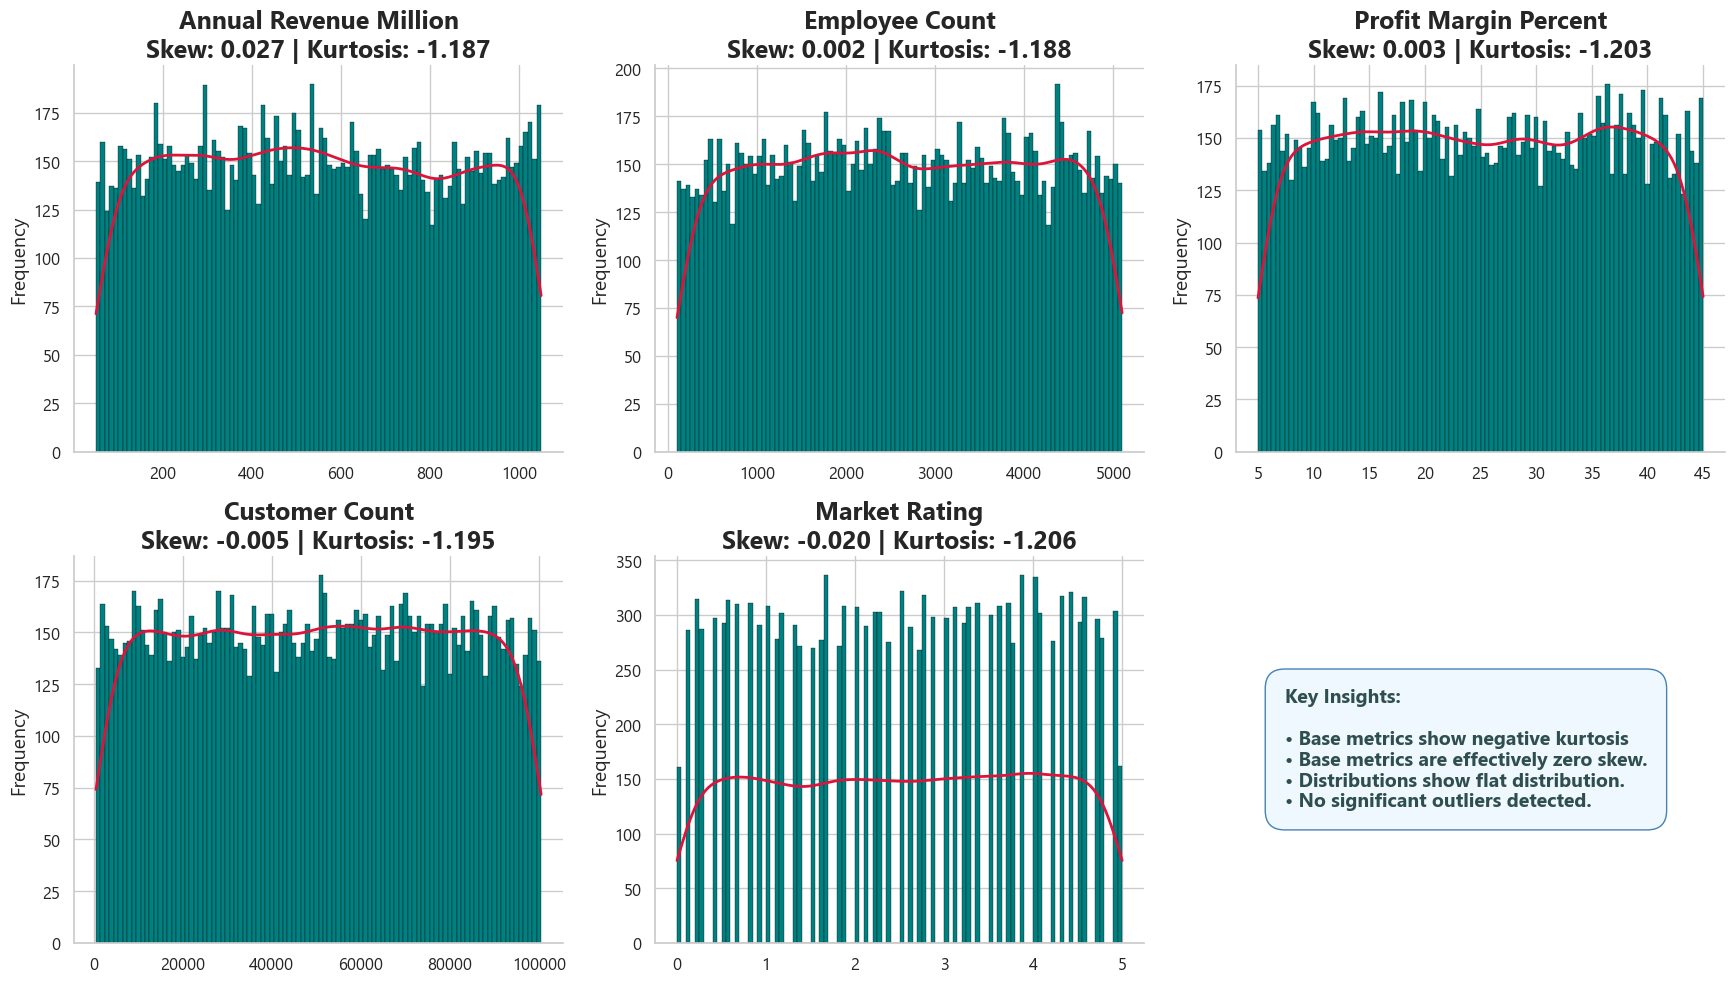


✅ Success: Base numerical histogram plotting complete with insights.


In [163]:
# A.2. Visualizing Distributions for Base Numerical Metrics (Dashboard View)

base_numerical_features = ['annual_revenue_million', 'employee_count', 'profit_margin_percent', 'customer_count', 'market_rating']
print("--- Depicting Histograms (Base Numerical Metrics) ---")

#   Create a 2x3 grid (6 total slots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.subplots_adjust(wspace=0.5, hspace=0.6)  # Add space between plots
axes = axes.flatten() # Flatten to easily loop through

for i, col in enumerate(base_numerical_features):
    only_values = df_transformed[col].dropna()
    display_title = col.replace('_', ' ').title()
    sk_val, kt_val = skew(only_values), kurtosis(only_values)
    
    sns.histplot(only_values, kde=True, ax=axes[i], color='crimson', facecolor='teal', bins=100, edgecolor='black', line_kws={'linewidth': 2})
    axes[i].set_title(f'{display_title}\nSkew: {sk_val:.3f} | Kurtosis: {kt_val:.3f}', weight='bold')
    axes[i].set_xlabel(''); axes[i].set_ylabel('Frequency')

#   Hides the chart borders and gridlines
axes[5].axis('off')     
insight_text = "Key Insights:\n\n• Base metrics show negative kurtosis \n• Base metrics are effectively zero skew.\n• Distributions show flat distribution.\n• No significant outliers detected."
axes[5].text(0.1, 0.5, insight_text ,color='darkslategray', fontsize=14, va='center', ha='left', weight='bold', bbox=dict(facecolor='aliceblue', edgecolor='steelblue', boxstyle='round,pad=1'))
plt.tight_layout()
plt.show()
print("\n✅ Success: Base numerical histogram plotting complete with insights.")

<div style="margin-left: 40px; max-width: 90%;">

**💡 Interpretation of Base Numerical Visuals:**
* **Flat, Uniform Distributions:** The histograms for all five base metrics — revenue, employee count, customer count, profit margin, and market rating — display a completely even spread across their full range. No single value range dominates, which visually confirms the symmetry identified in the statistical summary.
* **What This Means:** This level of uniformity is uncommon in real-world data. It indicates that the dataset represents a deliberately balanced cross-section of the market — covering companies of all sizes and performance levels equally, rather than being dominated by any one type.

</div>

<div style="margin-left: 40px;">

#### B. Base Categorical Metrics
We now examine our original categorical variables to understand industry representation and regional concentration.

<div style="margin-left: 20px;">

##### B.1. Statistical Summary
Before visualizing, we calculate the exact volume and percentage makeup of our business sectors and geographic regions.

</div>
</div>

In [164]:
#   B.1. Statistical Summary for Base Categorical Metrics
base_categorical_features = ['industry', 'region', 'country']

#   Start the HTML content with your styled header
html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px;">
        Statistical Summary 
        <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal;">Base Categorical Metrics</i>
    </h2>
</div>
'''

#   Add the opening tag for the Flexbox grid to the content
html_content += '<div style="display: flex; flex-wrap: wrap; gap: 30px; justify-content: center;">'

#   Loop through your metrics and inject the tables into the grid
for col in base_categorical_features:
    counts = df_transformed[col].value_counts()
    percentages = df_transformed[col].value_counts(normalize=True) * 100    
    
    bc_summary_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
    display_title = col.replace('_', ' ').title()

    html_content += f'''
    <div style="flex: 0 1 28%; min-width: 250px; margin-bottom: 15px;">
        <h4 style="margin-bottom: 8px;color: #69B8A3;">📌 {display_title}</h4>
        {bc_summary_df.to_html(border=1, justify='center')}
    </div>
    '''

#   Close the Flexbox grid container
html_content += '</div>' 

#   Render the single, combined HTML string exactly once
display(HTML(html_content))
print("\n✅ Success: Base categorical statistical summaries generated.")

,Count,Percentage (%)
industry,,
Finance,3000,20.0
Healthcare,3000,20.0
Manufacturing,3000,20.0
Retail,3000,20.0
Technology,3000,20.0
,Count,Percentage (%)
region,,
North America,7500,50.0
Asia,3750,25.0



✅ Success: Base categorical statistical summaries generated.


<div style="margin-left: 40px; max-width: 90%;">

**💡 Interpretation of Categorical Statistics:**
* **Perfectly Even Industry Split:** Each of the 5 industries contains exactly 3,000 companies, representing a clean 20% share each. This confirms no single sector is over-represented in the dataset.
* **Balanced Geography:** Each of the 4 countries holds exactly 3,750 records (25%), while the 3 regions are split proportionally — North America holding the largest share due to covering two countries.
* **Analysis Implication:** This structural balance means any performance differences found between industries or regions in later analysis will reflect genuine behavioral differences, not simply a larger sample size in one group.

</div>

<div style="margin-left: 60px;">

##### B.2. Visual Distribution
We plot frequency distributions to determine which sectors and geographic regions dominate our business dataset.

</div>

--- Visualizing Distributions (Base Categorical Metrics) ---


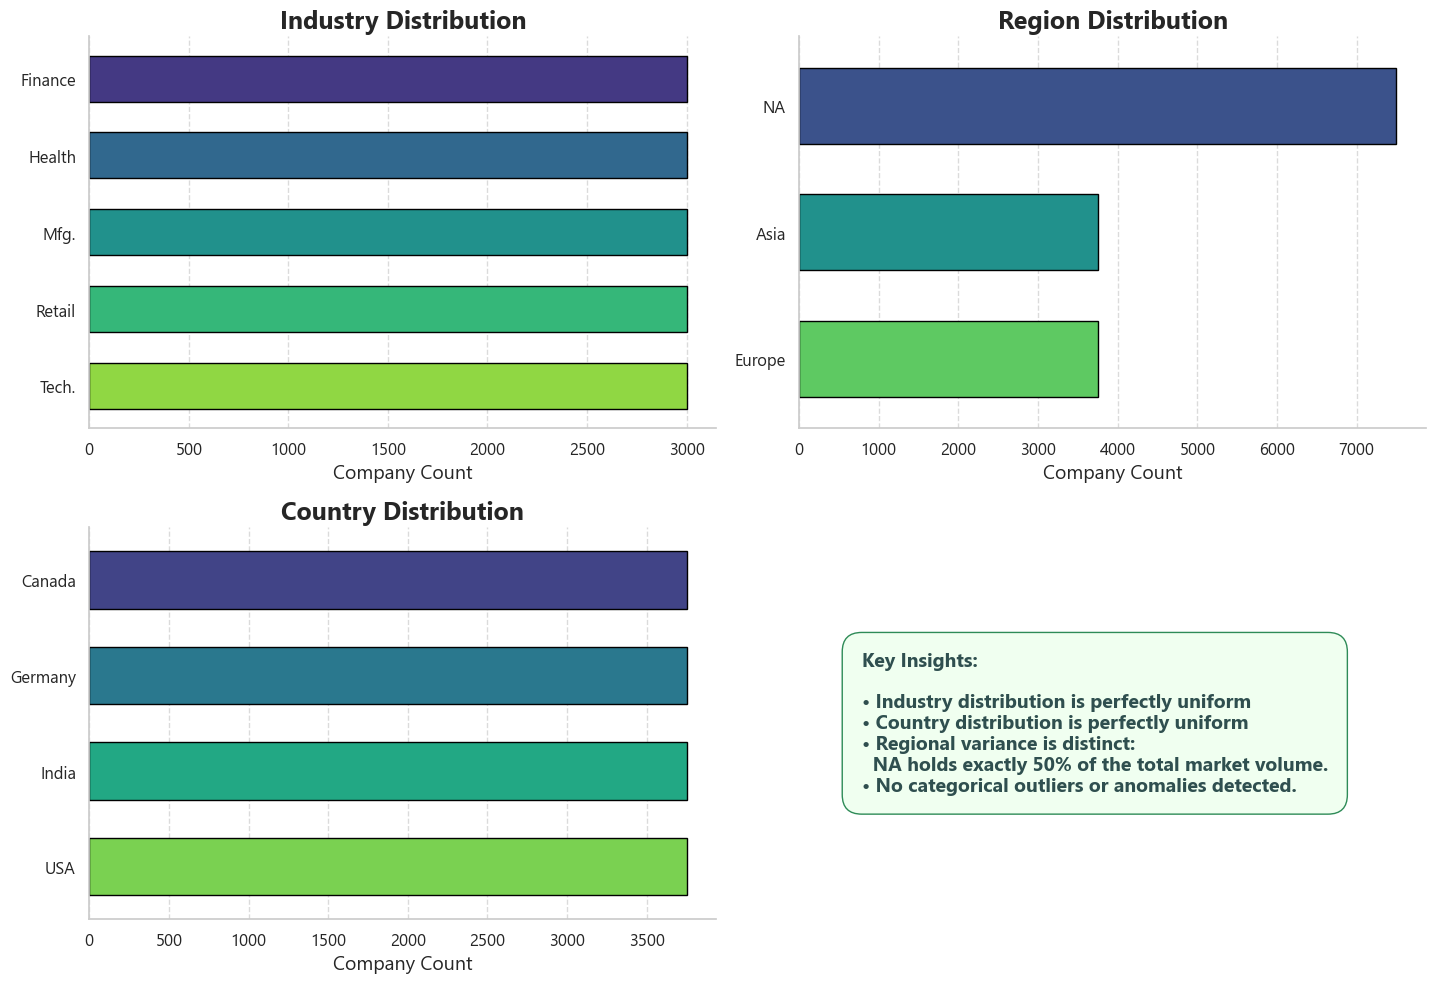


✅ Success: Base categorical distributions plotted with insights.


In [165]:
#   B.2. Visualizing Distributions (Base Categorical Metrics)

base_categorical_features = ['industry', 'region', 'country']
print("--- Visualizing Distributions (Base Categorical Metrics) ---")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.subplots_adjust(wspace=0.5, hspace=0.6)
axes = axes.flatten()

label_mapping = {'North America': 'NA','Manufacturing': 'Mfg.','Technology': 'Tech.','Healthcare': 'Health'}

for i, col in enumerate(base_categorical_features):
    counts = df_transformed[col].value_counts()
    counts.rename(index=label_mapping, inplace=True)
    display_title = col.replace('_', ' ').title()
    
    counts.plot(kind='barh', ax=axes[i], color=sns.color_palette("viridis", len(counts)), edgecolor='black', width=0.6)
    axes[i].invert_yaxis(); axes[i].grid(axis='x', linestyle='--', alpha=0.7); axes[i].grid(axis='y', visible=False)
    axes[i].set_title(f'{display_title} Distribution', fontweight='bold'); axes[i].set_xlabel('Company Count'); axes[i].set_ylabel('')

axes[3].axis('off')
insight_text = "Key Insights:\n\n• Industry distribution is perfectly uniform \n• Country distribution is perfectly uniform\n• Regional variance is distinct:\n  NA holds exactly 50% of the total market volume.\n• No categorical outliers or anomalies detected."
axes[3].text(0.1, 0.5, insight_text, fontsize=14, va='center', ha='left', weight='bold', color='darkslategray', bbox=dict(facecolor='honeydew', edgecolor='seagreen', boxstyle='round,pad=1'))

plt.tight_layout()
plt.show()
print("\n✅ Success: Base categorical distributions plotted with insights.")

<div style="margin-left: 40px; max-width: 90%;">

**💡 Interpretation of Base Categorical Visuals:**
* **Visual Confirmation:** The bar charts confirm the even splits calculated in the statistical summary. Industry and country distributions are perfectly uniform, while the region column shows a slight imbalance — North America is the only region covering two countries, explaining its larger share.
* **Real-World Context:** Unlike most real-world business datasets which tend to be heavily weighted toward a few dominant sectors, this dataset presents a controlled, balanced view — making it ideal for fair cross-industry comparisons.

</div>

<div style="margin-left: 40px; max-width: 90%">

#### C. Engineered Numerical Metrics
We now analyze the continuous features generated during our feature engineering phase to uncover derived business insights (e.g., efficiency ratios and market saturation).

<div style="margin-left: 20px;">

##### C.1. Statistical Summary
Evaluating the central tendency, dispersion, and shape of our custom numerical distributions.

</div>
</div>

In [166]:
#   C.1. Statistical Summary for Engineered Numerical Metrics

engineered_numerical_features = ['company_age', 'rev_per_emp', 'rev_per_customer', 'cust_per_emp', 'industry_density']
html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px;">
        Statistical Summary 
        <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal;">Engineered Numerical Metrics</i>
    </h2>
</div>
'''
eng_stats = []

for col in engineered_numerical_features:
    only_values = df_transformed[col].dropna()
    
    eng_stats.append({'Feature': col.replace('_', ' ').title(),'Mean': only_values.mean().__round__(3),'Median': only_values.median().__round__(3),'Min': only_values.min().__round__(3),'Max': only_values.max().__round__(3),'Skewness': skew(only_values).__round__(4),'Kurtosis': kurtosis(only_values).__round__(4)})
#   Convert to DataFrame for a clean, executive table
eng_stats_df = pd.DataFrame(eng_stats)

html_content += f'''
<div style="display: flex; justify-content: center; margin-bottom: 15px;">
    {eng_stats_df.to_html(border=1, justify='center')}
</div>
'''

display(HTML(html_content))
print("\n✅ Success: Engineered numerical statistical summary generated.")

,Feature,Mean,Median,Min,Max,Skewness,Kurtosis
0,Company Age,21.626,22.000,7.000,36.000,-0.0206,-1.1896
1,Rev Per Emp,0.423,0.211,0.010,10.320,5.5824,42.2195
2,Rev Per Customer,0.029,0.011,0.001,1.696,9.3397,118.9042
3,Cust Per Emp,39.069,19.264,0.120,891.971,5.2800,37.1814
4,Industry Density,1125.000,1125.000,750.000,1500.000,0.0000,-2.0000



✅ Success: Engineered numerical statistical summary generated.


<div style="margin-left: 40px; max-width: 90%;">

**💡 Interpretation of Engineered Numerical Statistics:**
* **Company Age:** Age is evenly distributed across the dataset with no significant lean toward newer or older companies. This ensures that age-based comparisons will not be skewed by an overrepresentation of any particular generation of businesses.
* **Efficiency Ratios:** The three derived ratios — revenue per employee, revenue per customer, and customers per employee — all show a strong rightward skew. Most companies operate within a modest efficiency range, but a concentrated group of high-performing outliers pulls the distribution significantly to the right. This gap between the majority and the outlier group is one of the most important patterns in the entire dataset.

</div>

<div style="margin-left: 60px;">

##### C.2. Visual Distributions
Visualizing the engineered metrics to confirm the mathematical skewness, kurtosis, and presence of extreme outliers identified in the statistical summary.

</div>

--- Depicting Histograms (Engineered Numerical Metrics) ---


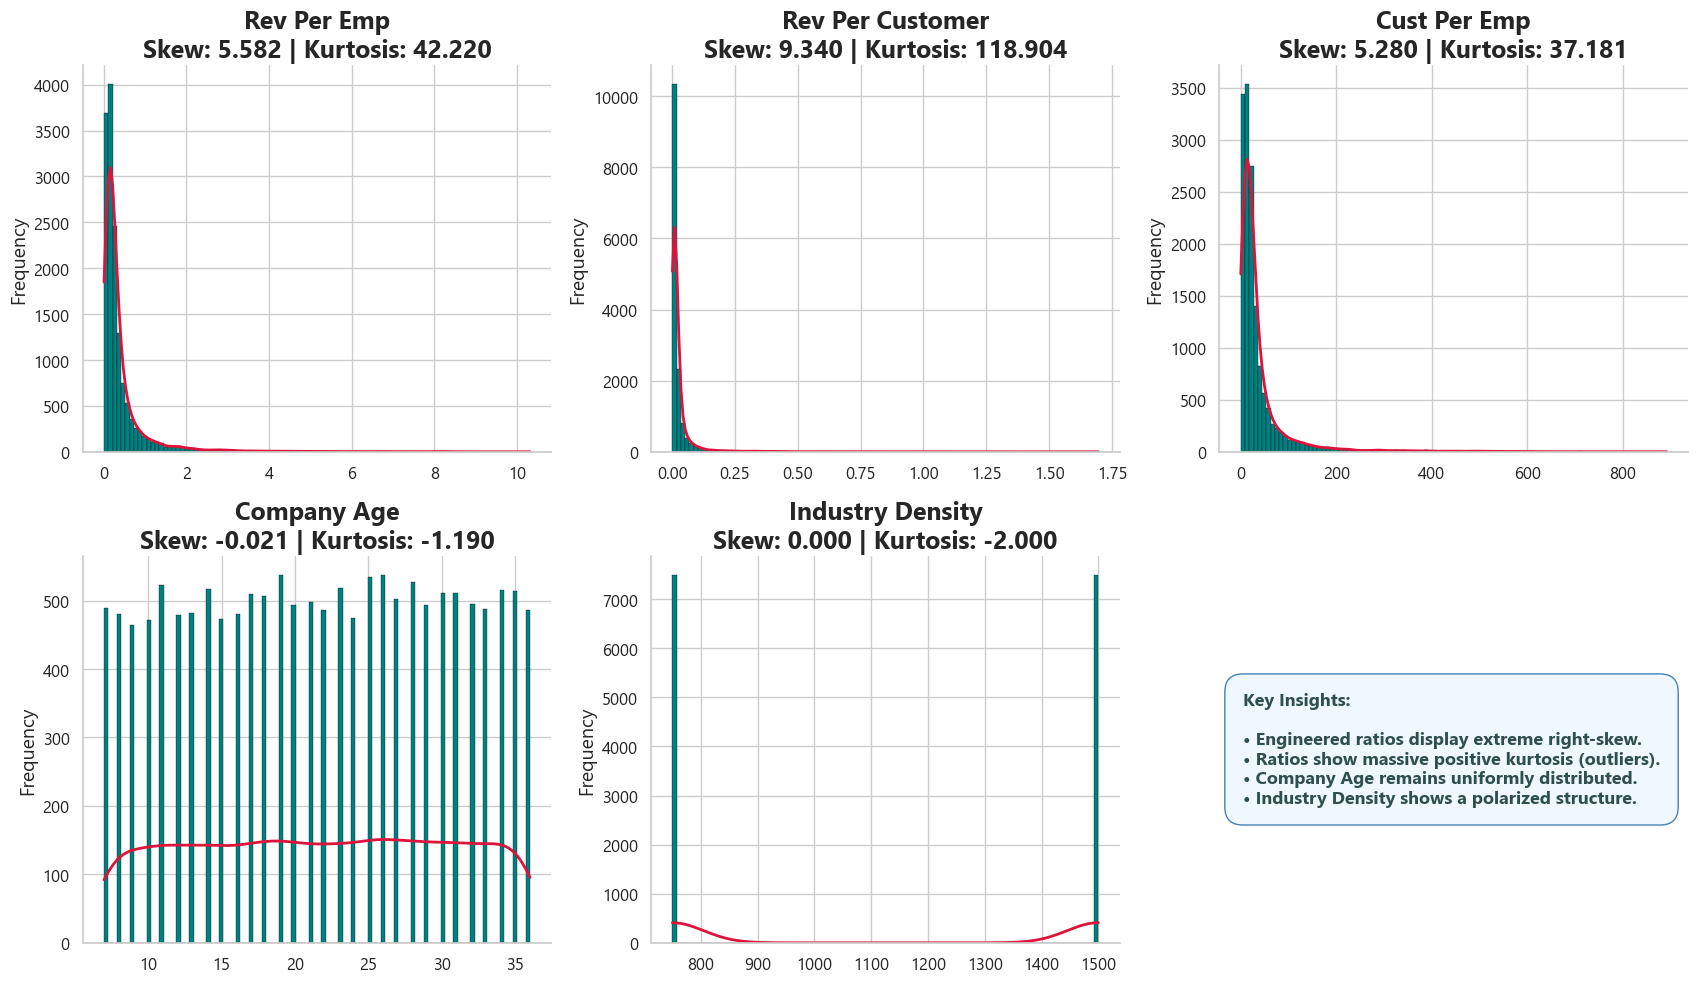


✅ Success: Engineered numerical histogram plotting complete with insights.


In [167]:
#   C.2. Visualizing Distributions for Engineered Numerical Metrics (Comparison Dashboard)

engineered_numerical_features = ['rev_per_emp', 'rev_per_customer','cust_per_emp','company_age', 'industry_density']
print("--- Depicting Histograms (Engineered Numerical Metrics) ---")

#   Create a 2x3 grid (6 total slots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.subplots_adjust(wspace=0.5, hspace=0.6)  # Add space between plots
axes = axes.flatten() # Flatten to easily loop through

for i, col in enumerate(engineered_numerical_features):
    only_values = df_transformed[col].dropna()
    display_title = col.replace('_', ' ').title()
    sk_val, kt_val = skew(only_values), kurtosis(only_values)
    
    sns.histplot(only_values, kde=True, ax=axes[i], color='crimson', facecolor='teal', bins=100, edgecolor='black', line_kws={'linewidth': 2})
    axes[i].set_title(f'{display_title}\nSkew: {sk_val:.3f} | Kurtosis: {kt_val:.3f}', weight='bold')
    axes[i].set_xlabel(''); axes[i].set_ylabel('Frequency')

#   Hides the chart borders and gridlines
axes[5].axis('off')     
insight_text = "Key Insights:\n\n• Engineered ratios display extreme right-skew.\n• Ratios show massive positive kurtosis (outliers).\n• Company Age remains uniformly distributed.\n• Industry Density shows a polarized structure."
axes[5].text(0.05, 0.5, insight_text ,color='darkslategray', fontsize=13, va='center', ha='left', weight='bold', bbox=dict(facecolor='aliceblue', edgecolor='steelblue', boxstyle='round,pad=1'))
plt.tight_layout()
plt.show()
print("\n✅ Success: Engineered numerical histogram plotting complete with insights.")

<div style="margin-left: 40px; max-width: 90%;">

**💡 Interpretation of Engineered Numerical Visuals:**
* **Efficiency Ratio Distributions:** The histograms for all three ratio metrics show the same pattern — a tall, narrow spike on the left where the majority of companies sit, followed by a long, flat tail extending to the right. This confirms that most companies operate at similar, moderate efficiency levels, while a small number operate at a dramatically higher scale.
* **Company Age:** The age distribution is smooth and balanced, spreading evenly from newer to older companies without any sharp concentration at a particular age range.
* **Key Takeaway:** The contrast between the flat base metric distributions and the skewed ratio distributions is significant. It confirms that raw size does not determine efficiency — and that the outliers in these ratios represent a genuinely distinct group worth investigating further.

</div>

<div style="margin-left: 40px;">

#### D. Engineered Categorical Metrics
We now examine the custom business categories and tiers generated during our feature engineering phase.

<div style="margin-left: 20px;">

##### D.1. Statistical Summary
Calculating the frequencies and proportions of our engineered business models and company tiers.

</div>
</div>

In [168]:
#    D.1. Statistical Summary for Engineered Categorical Metrics

engineered_categorical_features = ['age_tier', 'rating_tier', 'revenue_tier', 'customer_tier', 'business_model']
html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px;">
        Statistical Summary 
        <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal;">Engineered Categorical Metrics</i>
    </h2>
</div>
'''

html_content += '<div style="display: flex; flex-wrap: wrap; gap: 40px; justify-content: center;">'

for col in engineered_categorical_features:
    counts,percentages = df_transformed[col].value_counts(), df_transformed[col].value_counts(normalize=True) * 100
    ec_summary_df = pd.DataFrame({'Count': counts,'Percentage (%)': percentages.round(2)})
    
    display_title = col.replace('_', ' ').title()
    html_content += f'''
    <div style="flex: 0 1 30%; min-width: 250px; margin-bottom: 15px;">
        <h4 style="margin-bottom: 8px;color: #69B8A3;">📌 {display_title}</h4>
        {ec_summary_df.to_html(border=1, justify='center')}
    </div>
    '''

html_content += '</div>' 
display(HTML(html_content))
print("\n✅ Success: Engineered categorical statistical summaries generated.")

,Count,Percentage (%)
age_tier,,
Established,13094,87.29
Growth,1906,12.71
Startup,0,0.00
,Count,Percentage (%)
rating_tier,,
Low Performer,6087,40.58
Average Performer,6046,40.31
Market Leader,2867,19.11
,Count,Percentage (%)



✅ Success: Engineered categorical statistical summaries generated.


<div style="margin-left: 40px; max-width: 90%;">

**💡 Interpretation of Engineered Categorical Statistics:**
* **Age Concentration:** The overwhelming majority of companies in this dataset — 87.3% — fall under the `Established` category, meaning they have been operating for over 10 years. There are no startups present, indicating this dataset represents a mature market snapshot rather than an early-stage ecosystem.
* **Customer Scale:** The `Mass-Scale` customer tier accounts for 95.6% of all companies. Niche operators are practically absent from this dataset.
* **Revenue Tiers:** Revenue tiers are more evenly distributed, with Medium and Large companies making up the bulk, and a smaller but notable presence of Enterprise-level companies.
* **Market Ratings:** Performance ratings spread relatively evenly, with Low and Average Performers each holding roughly 40% of the dataset, and Market Leaders making up the remaining 20%.
* **Business Models:** The `Business Model` clearly suggests that mass-market targeting is the universal standard. The top four combinations are all variations of the Mass-Scale approach, with **Medium / Mass-Scale** (29.35%) and **Large / Mass-Scale** (27.71%) acting as the primary operating strategies within the dataset.

</div>

<div style="margin-left: 60px;">

##### D.2. Visual Distributions
Visualizing the frequency distributions of our newly engineered business tiers and combined operating models.

</div>

--- Visualizing Core Tiers (Proportional Donut Charts) ---


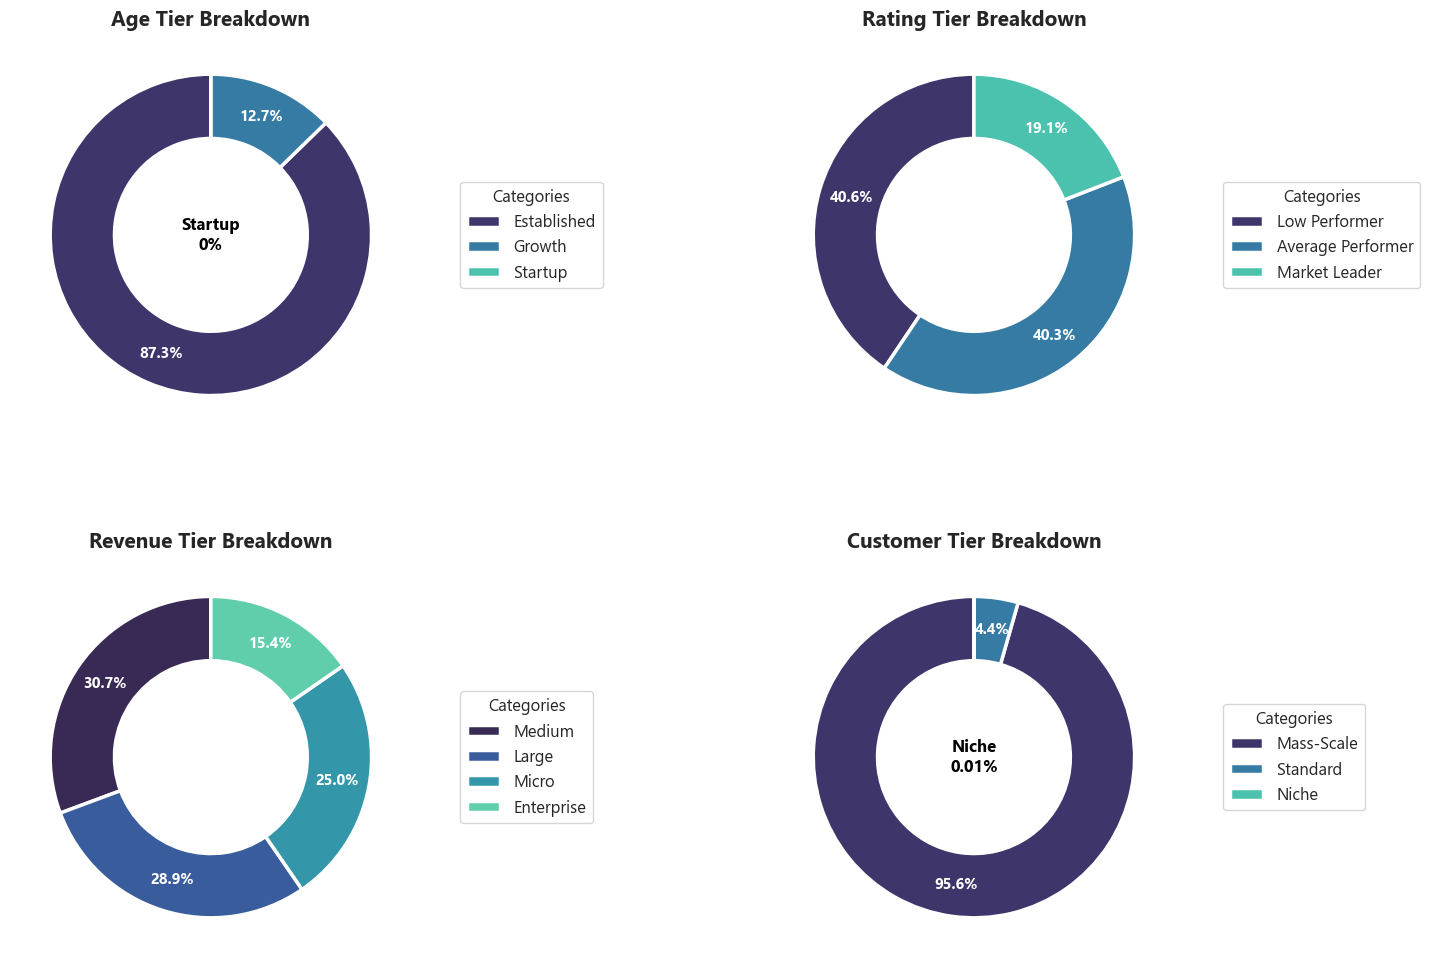

✅ Success: Engineered categorical donut charts generated.


In [169]:
# D.2a. Visualizing Core Tiers (Proportional Donut Charts)

engineered_tiers = ['age_tier', 'rating_tier', 'revenue_tier', 'customer_tier']
print("--- Visualizing Core Tiers (Proportional Donut Charts) ---")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.subplots_adjust(wspace=0.6, hspace=0.3) 
axes = axes.flatten()

donut_palette = "mako"

for i, col in enumerate(engineered_tiers):
    counts,percentages = df_transformed[col].value_counts(), df_transformed[col].value_counts(normalize=True) * 100
    display_title = col.replace('_', ' ').title()
    
    def custom_autopct(pct):
        return f'{pct:.1f}%' if pct >= 1.0 else ''
    
    wedges, texts, autotexts = axes[i].pie(counts,labels=None,autopct=custom_autopct, pctdistance=0.80,startangle=90, colors=sns.color_palette(donut_palette, len(counts)),wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2.5))
    plt.setp(autotexts, size=11, weight="bold", color="white")
    
    # --- DONUT HOLE LOGIC FOR MICRO-SLICES (< 1%) ---
    tiny_labels = []
    for j, pct in enumerate(percentages):
        if pct < 1.0:
            category_name = counts.index[j]
            #   Use .1f for exactly 0.0%, and .2f for 0.01% for clean formatting
            formatted_pct = f"{pct:.0f}%" if pct == 0 else f"{pct:.2f}%"
            tiny_labels.append(f"{category_name}\n{formatted_pct}")
            
    #   If there is a micro-slice, print it boldly in the center of the donut hole
    if tiny_labels:
        center_text = "\n".join(tiny_labels)
        axes[i].text(0, 0, center_text, ha='center', va='center',fontsize=12, weight='bold', color='black')
        
    axes[i].set_title(f'{display_title} Breakdown', fontsize=15, weight='bold')
    axes[i].legend(wedges, counts.index, title="Categories", loc="center left", bbox_to_anchor=(1.1, 0.5))

plt.show()
print("✅ Success: Engineered categorical donut charts generated.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation of Engineered Tiers:**
* **Mature, High-Volume Market:** The charts reinforce what the statistics already told us — this is a dataset of established, large-scale businesses. Startups and niche operators are the exception rather than the rule.
* **Balanced Revenue Spread:** Unlike customer and age tiers, revenue tiers show a more even spread across all four categories. This means that being established and mass-scale does not automatically translate to high revenue — operational efficiency still varies widely within the same tier.

</div>

--- Visualizing Business Model Distribution ---


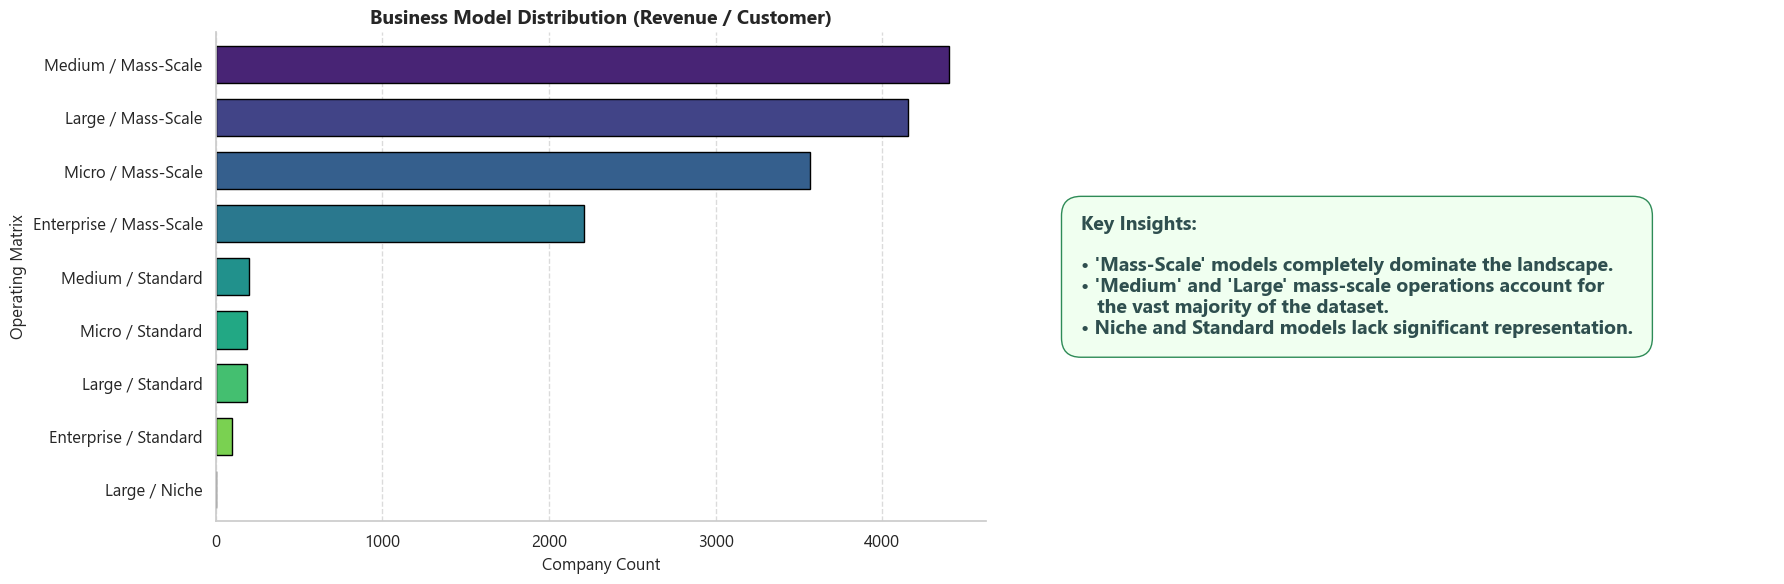

✅ Success: Business model distribution visualized with insights.


In [170]:
#   D.2b. Visualizing Business Model Distribution

print("--- Visualizing Business Model Distribution ---")
# 1. Create a 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
bm_counts = df_transformed['business_model'].value_counts()
display_title = 'Business Model Distribution (Revenue / Customer)'

multi_colors = sns.color_palette("viridis", len(bm_counts))
bm_counts.plot(kind='barh', ax=axes[0], color=multi_colors, edgecolor='black', width=0.7)

axes[0].invert_yaxis(); axes[0].grid(axis='x', linestyle='--', alpha=0.7); axes[0].grid(axis='y', visible=False)
axes[0].set_title(display_title, fontweight='bold', fontsize=14); axes[0].set_xlabel('Company Count', fontsize=12); axes[0].set_ylabel('Operating Matrix', fontsize=12)

axes[1].axis('off')
insight_text = "Key Insights:\n\n• 'Mass-Scale' models completely dominate the landscape.\n• 'Medium' and 'Large' mass-scale operations account for\n   the vast majority of the dataset.\n• Niche and Standard models lack significant representation."
axes[1].text(0.1, 0.5, insight_text, color='darkslategray', fontsize=14, va='center', ha='left', weight='bold', bbox=dict(facecolor='honeydew', edgecolor='seagreen', boxstyle='round,pad=1'))

plt.tight_layout()
plt.show()
print("✅ Success: Business model distribution visualized with insights.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation of Engineered Categorical Visuals:**
* **Operating Matrix Clarity:** The horizontal bar chart successfully breaks down the complex intersection of the `business_model` matrix. Visually, it is immediately clear that **Medium / Mass-Scale** and **Large / Mass-Scale** are the dominant operating frameworks for this dataset.

</div>

<div style="margin-left: 40px; max-width: 90%">

#### E. Business Pipeline & Funnel Analysis
Instead of looking at our metrics one by one, this funnel brings them together to show how the market naturally narrows down. We pass all 15,000 companies through five strict business filters to see who survives at each step. This gives us a clear, step-by-step visual of exactly what it takes to become an elite market leader, showing just how rare that top-tier success actually is.

</div>

--- Visualizing the Elite Company Pipeline ---


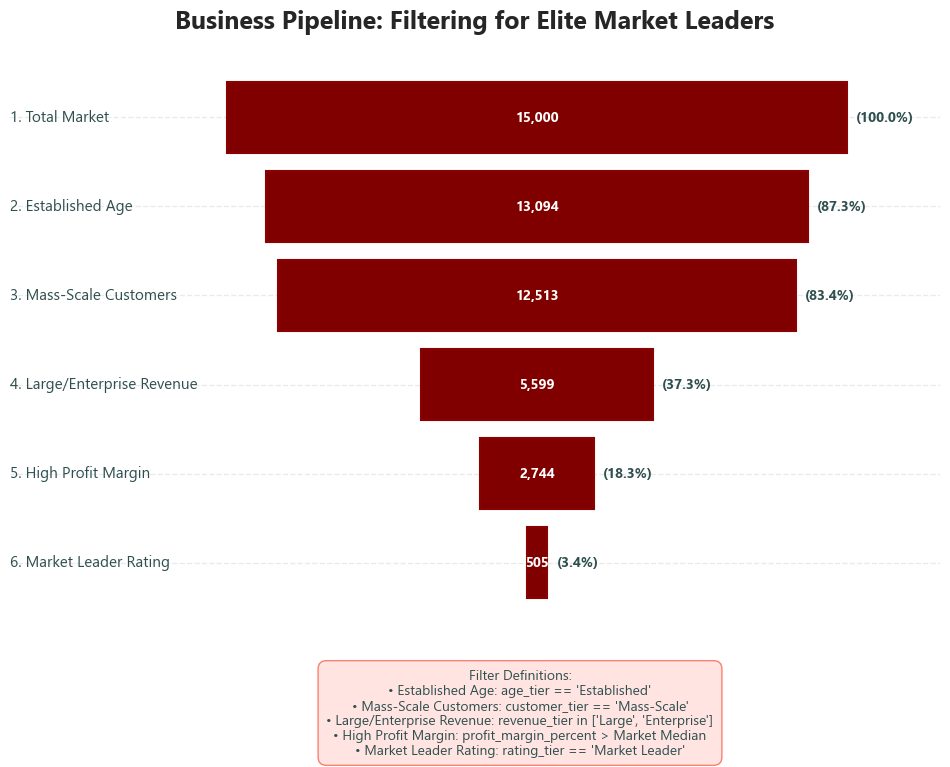


✅ Success: Symmetrical funnel chart generated with direct category labels and technical legend.


In [171]:
#   E. Univariate Funnel Analysis (Direct Category Labels with Legend)
print("--- Visualizing the Elite Company Pipeline ---")

#   Expand the Funnel Stages
total_companies = len(df_transformed)
s2 = df_transformed[df_transformed['age_tier'] == 'Established']
s3 = s2[s2['customer_tier'] == 'Mass-Scale']
s4 = s3[s3['revenue_tier'].isin(['Large', 'Enterprise'])]
median_profit = df_transformed['profit_margin_percent'].median()
s5 = s4[s4['profit_margin_percent'] > median_profit]
s6 = s5[s5['rating_tier'] == 'Market Leader']

#   Create the Funnel DataFrame (Using direct naming logic)
funnel_data = pd.DataFrame({'Stage': ['1. Total Market', '2. Established Age', '3. Mass-Scale Customers', '4. Large/Enterprise Revenue','5. High Profit Margin','6. Market Leader Rating'],'Count': [total_companies, len(s2), len(s3), len(s4), len(s5), len(s6)]})
funnel_data['Retention %'] = (funnel_data['Count'] / total_companies * 100).round(1)

#   Calculate the offsets to center the bars
max_width = funnel_data['Count'].max()
funnel_data['Offset'] = (max_width - funnel_data['Count']) / 2

#   Plot the Custom Centered Funnel
fig, ax = plt.subplots(figsize=(12, 8))

#   Draw the bars
bars = ax.barh(funnel_data['Stage'], funnel_data['Count'], left=funnel_data['Offset'], color='maroon', edgecolor='darkred',linewidth=1.5,height=0.8)
ax.invert_yaxis()

#   Formatting
plt.title('Business Pipeline: Filtering for Elite Market Leaders', weight='bold', pad=20)

ax.spines['top'].set_visible(False);ax.spines['right'].set_visible(False);ax.spines['bottom'].set_visible(False);ax.spines['left'].set_visible(False);ax.set_xticks([]);ax.set_yticks(range(len(funnel_data)));ax.set_yticklabels([]);ax.tick_params(axis='y', length=0, labelsize=12);ax.set_xlim(-max_width * 0.35, max_width * 1.15);ax.set_axisbelow(True)
#   Split Text Logic: Count INSIDE, Percentage OUTSIDE
for i, bar in enumerate(bars):
    center_x = max_width / 2
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    #   The Stage Label manually placed at a fixed left coordinate so they align perfectly
    ax.text(-max_width * 0.35, y_pos,funnel_data['Stage'].iloc[i],va='center', ha='left', color='darkslategray', fontsize=11)
    #   Absolute count
    ax.text(center_x, y_pos, f"{int(width):,}",va='center', ha='center', color='white', weight='bold', fontsize=10)
    
    #   Percentage outside
    right_edge = center_x + (width / 2)
    ax.text(right_edge + (max_width * 0.015), y_pos, f"({funnel_data['Retention %'].iloc[i]}%)",va='center', ha='left', color='darkslategray', weight='bold', fontsize=10)

#   Add the Legend/Footnote at the bottom
footnote_text = ("Filter Definitions:\n""• Established Age: age_tier == 'Established'\n""• Mass-Scale Customers: customer_tier == 'Mass-Scale'\n""• Large/Enterprise Revenue: revenue_tier in ['Large', 'Enterprise']\n""• High Profit Margin: profit_margin_percent > Market Median\n""• Market Leader Rating: rating_tier == 'Market Leader'")
plt.figtext(0.55, 0.01,footnote_text, wrap=True, horizontalalignment='center',fontsize=10, color='darkslategray', bbox=dict(facecolor='mistyrose', edgecolor='salmon', boxstyle='round,pad=0.6'))

# Adjust layout so the chart doesn't overlap the new footnote
plt.subplots_adjust(bottom=0.17)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()
print("\n✅ Success: Symmetrical funnel chart generated with direct category labels and technical legend.")

<div style="margin-left: 40px; max-width: 90%;">

**💡 Interpretation of Elite Company Pipeline**
* **Sequential Filtering:** This funnel visualizes the strict survival rate of our dataset by filtering companies through five specific operational parameters: **Established Age**, **Mass-Scale Customers**, **Large/Enterprise Revenue**, **High Profit Margin**, and a **Market Leader Rating**.
* **The Benchmark:** Starting with a total market of 15,000 entities, the pipeline strongly indicates that only a microscopic fraction (3.4%) successfully satisfy all five rigorous conditions simultaneously. This visually confirms exactly how rare it is to find a company that is highly mature, operating at mass scale, highly profitable, and top-rated within our engineered metrics.

</div>

<div style="margin-left: 20px; max-width: 90%;">

**📌Univariate Phase Completion**
- With these visuals, we have successfully completed our Categorical Univariate Analysis. We have proven that while the base data is artificially flat, our feature engineering has successfully extracted the asymmetrical business segments required for predictive modeling.

</div>

<div style="margin-left: 20px; max-width: 90%;">

> However, looking at variables in isolation only tells part of the story. The natural next question is — do these variables influence each other? Does having more employees lead to higher revenue? Do certain industries consistently outperform others? To answer these, the analysis now moves into bivariate territory, examining direct relationships between pairs of variables.

</div>
<div style="text-align: center; margin: 40px 0;">
    <hr style="width: 15%; border: none; border-top: 1px solid #555; opacity: 0.5;">
</div>

- ### 📌Bivariate Analysis

<div style="margin-left: 20px; max-width: 90%;">
We now shift from isolated distributions to analyzing interactions between variables. To maintain a strict analytical flow, we have structured this section into three core categories: Numerical vs. Numerical, Categorical vs. Numerical, and Categorical cross-tabulations.

<div style="margin-left: 20px; max-width: 90%;">

#### A. Numerical vs. Numerical Interactions
This section explores the relationships between continuous numerical features, establishing our baseline correlations and temporal trends before introducing categorical segments.

<div style="margin-left: 20px; max-width: 90%;">

##### A.1. Standard Scatter
Plotting two continuous variables `customer_count` and `annual_revenue_million` across 15,000 records results in severe overplotting. As demonstrated below, this creates a uniform "inkblot" where no clear trends or mathematical correlations can be visually extracted.

</div>
</div>
</div>

--- Visualizing the Overplotting Effect ---


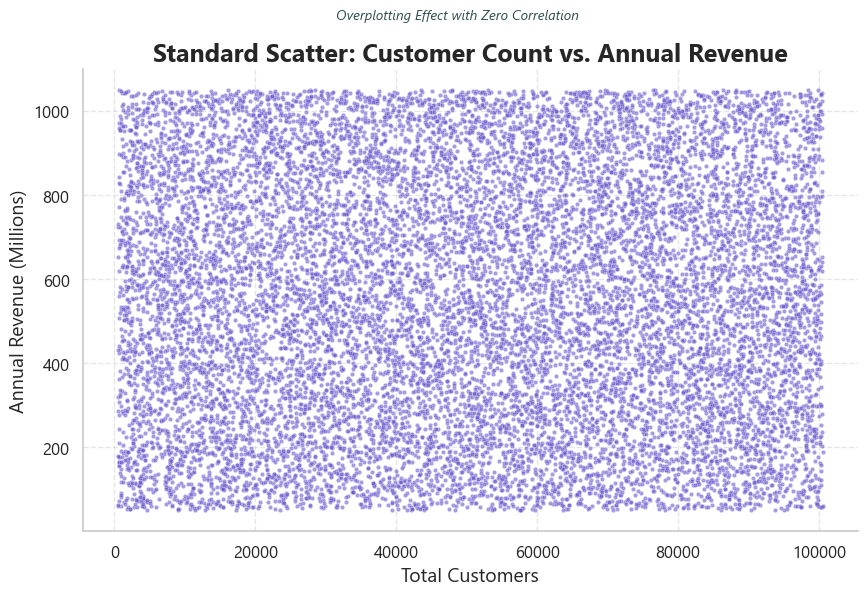


✅ Success: Baseline scatter plot generated, clearly showing the overplotting issue with zero correlation.


In [172]:
#   A.1 Baseline Scatter Plot (Num vs. Num)

print("--- Visualizing the Overplotting Effect ---")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_transformed, x='customer_count', y='annual_revenue_million', color='slateblue',alpha=0.6,s=10)

plt.title('Standard Scatter: Customer Count vs. Annual Revenue', weight='bold')
plt.suptitle('Overplotting Effect with Zero Correlation', fontsize=10, style='italic', color='darkslategray')
plt.xlabel('Total Customers')
plt.ylabel('Annual Revenue (Millions)')

# Set grid lines to be very faint so they don't distract from the data
plt.grid(axis='both', linestyle='--', alpha=0.5)
sns.despine()

plt.show()
print("\n✅ Success: Baseline scatter plot generated, clearly showing the overplotting issue with zero correlation.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: Numerical Baseline**
- **No Linear Relationship:** The scatter plot between `customer_count` and `annual_revenue_million` forms a uniform rectangular block with no visible diagonal pattern. This is a direct visual confirmation that having more customers does not automatically lead to higher revenue.
- **The Overplotting Problem:** Even with a medium transparency (`alpha=0.5`), the sheer density of the 15,000 records makes it impossible to extract meaningful operational tiers from this chart alone.
- **What It Suggests:** Revenue appears to be driven by something other than sheer customer volume — likely the quality or value of each customer relationship rather than the quantity.

</div>

<div style="margin-left: 60px; max-width: 90%;">

##### A.2. Hexbin Density (Solving Overplotting)
To penetrate the visual noise of the standard scatter plot, we apply a hexagonal binning technique. This aggregates the 15,000 data points into geometric density clusters, using color intensity to reveal where the majority of the market is concentrated.

</div>

--- Visualizing Market Density via Hexbin ---


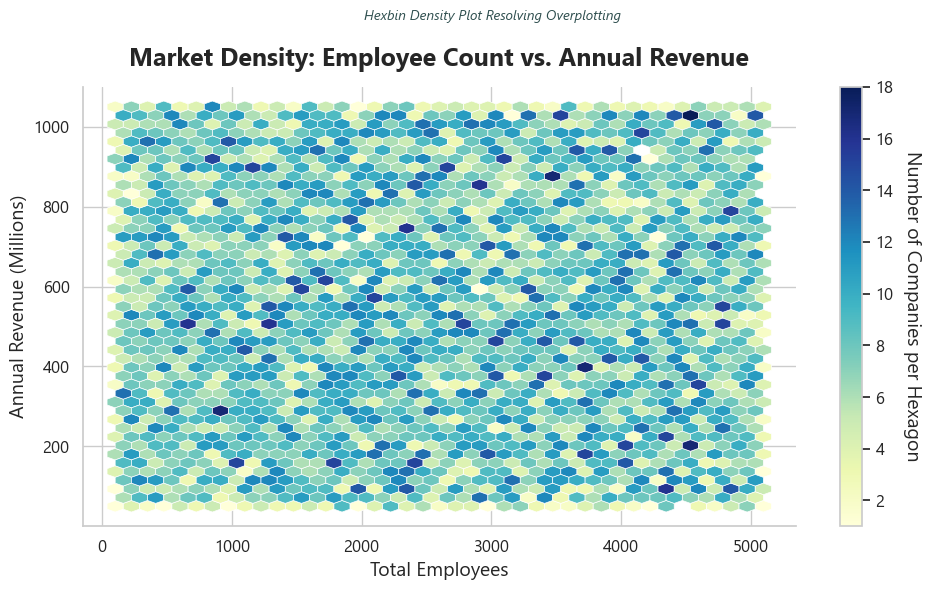


✅ Success: Hexbin density plot generated, resolving the overplotting issue.


In [173]:
# A.2 Hexbin Density Plot (Num vs. Num)

print("--- Visualizing Market Density via Hexbin ---")

plt.figure(figsize=(10, 6))
hb = plt.hexbin(df_transformed['employee_count'],df_transformed['annual_revenue_million'],gridsize=40,cmap='YlGnBu',mincnt=1,edgecolors='white',linewidths=0.5)

plt.title('Market Density: Employee Count vs. Annual Revenue',weight='bold', pad=15)
plt.suptitle('Hexbin Density Plot Resolving Overplotting', fontsize=10, style='italic', color='darkslategray')
plt.xlabel('Total Employees')
plt.ylabel('Annual Revenue (Millions)')

# Adding the colorbar to explain what the colors mean
cb = plt.colorbar(hb)
cb.set_label('Number of Companies per Hexagon', rotation=270, labelpad=20)

# Clean up borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n✅ Success: Hexbin density plot generated, resolving the overplotting issue.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: Operational Efficiency**
* **A Uniform Market:** The density plot confirms that companies are spread evenly across all combinations of customer count and revenue. There is no dominant cluster where most companies sit, reinforcing the finding that no single scale of operation has a built-in revenue advantage.
* **Hiring Does Not Drive Revenue:** The absence of any upward-sloping concentration mathematically confirms that adding more employees or acquiring more customers does not reliably produce higher revenue. Operational efficiency — not volume — is what separates high earners from the rest.
</div>


>**Strategic Pivot:** Both charts prove that raw, static numbers are just noise. To actually understand this market, we must slice the data across different dimensions—starting with how these revenues fluctuate over time, before breaking them down by specific market sectors.


<div style="margin-left: 40px; max-width: 90%;">

#### B. Categorical vs. Numerical Distributions
In this section, we pivot from raw continuous metrics to categorical groupings. By slicing our numerical outcomes (like Revenue and Profit) by time periods and physical market sectors, we can begin extracting business trends.

<div style="margin-left: 20px; max-width: 90%;">

##### B.1 Monthly Market Revenue (Total)
First, we track the total market revenue month-by-month to identify macro-level seasonality and spending cycles.

</div>

--- Visualizing Monthly Market Revenue Trend ---


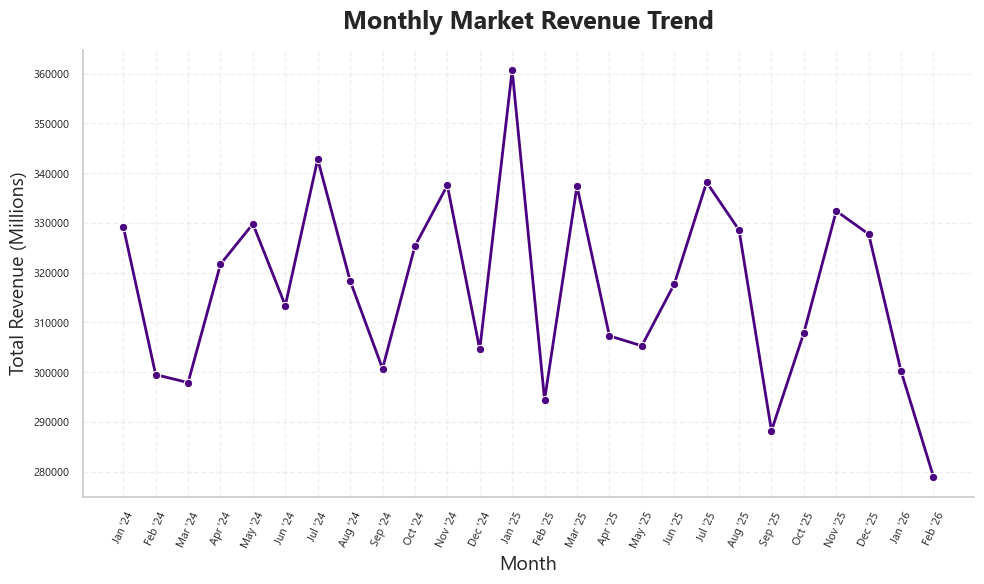


✅ Success: Monthly Time-series trendline generated successfully.


In [174]:
# B.1 Monthly Market Revenue (Total)

print("--- Visualizing Monthly Market Revenue Trend ---")
plt.figure(figsize=(10, 6))

#  Keeps time order intact and sort it chronologically.
monthly_trend = (df_transformed.groupby(df_transformed['created_date'].dt.to_period('M'))['annual_revenue_million'].sum()).sort_index()

#  Convert date into a readable format for x-axis
monthly_trend.index = monthly_trend.index.strftime("%b '%y")

sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o', color='indigo', linewidth=2)

plt.title('Monthly Market Revenue Trend', weight='bold', pad=15);plt.xlabel('Month');plt.ylabel('Total Revenue (Millions)');plt.xticks(rotation=65, ha='center', fontsize=8);plt.yticks(fontsize=8);plt.grid(True, linestyle='--', alpha=0.3)
sns.despine();plt.tight_layout();plt.show()
print("\n✅ Success: Monthly Time-series trendline generated successfully.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: Monthly Revenue Trend**
* **Cyclical Pattern:** Market revenue does not grow in a straight line. Instead, it follows a repeating cycle of sharp peaks and steep drops across the months, suggesting the market is heavily influenced by seasonal demand.
* **Three Consistent Peaks:** Three consistent spending peaks per year, each aligning approximately with the start of a new business quarter. These spikes confirm a cyclical, quarter-driven revenue pattern rather than steady linear growth. 
* **Practical Implication:** This seasonality means month-level revenue figures can be misleading in isolation. A low-revenue month may simply reflect the natural market cycle rather than poor company performance.

</div>

<div style="margin-left: 60px; max-width: 90%;">

##### B.2 Quarterly Profitability (Median)
Next, we zoom out to a quarterly view, tracking the median profit margin to understand the baseline financial health and efficiency of the market over time.

</div>

--- Visualizing Quarterly Profit Margin Trend ---


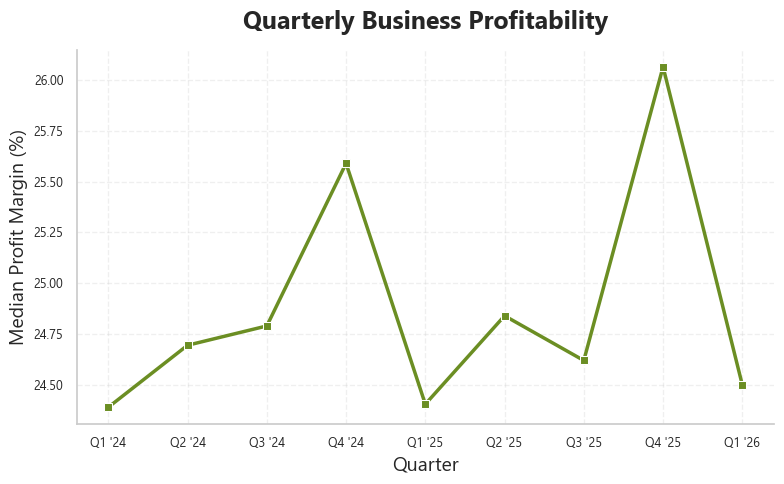


✅ Success: Quarterly Business Profitability trendline generated successfully.


In [175]:
# B.2 Quarterly Profitability (Median)

print("--- Visualizing Quarterly Profit Margin Trend ---")
plt.figure(figsize=(8, 5))

quarterly_trend = (df_transformed.groupby(df_transformed['created_date'].dt.to_period('Q'))['profit_margin_percent'].median()).sort_index()

quarterly_trend.index = quarterly_trend.index.strftime("Q%q '%y")

sns.lineplot(x=quarterly_trend.index, y=quarterly_trend.values, marker='s', color='olivedrab', linewidth=2.5)

plt.title('Quarterly Business Profitability', weight='bold', pad=15);plt.xlabel('Quarter');plt.ylabel('Median Profit Margin (%)');plt.xticks(rotation=0, ha='center', fontsize=9);plt.yticks(fontsize=9);plt.grid(True, linestyle='--', alpha=0.3)
sns.despine();plt.tight_layout();plt.show()
print("\n✅ Success: Quarterly Business Profitability trendline generated successfully.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: Quarterly Profit Trend**
* **Steady Recovery Pattern:** Profit margins start at their lowest point in Q1 and gradually climb through the year, reaching their peak in Q4. This suggests that the market becomes more operationally efficient as the year progresses.
* **Revenue vs. Margin Disconnect:** This finding pairs interestingly with the monthly revenue chart. While revenue spikes early in the year, margins are at their weakest — indicating that the high-revenue periods also come with higher costs. As spending settles later in the year, margins improve even if revenue growth slows.

</div>

<div style="margin-left: 20px; max-width: 90%;">

##### B.3 Industry Revenue Baselines (Horizontal Boxplot)
Finally, we drop the time-series and segment the market by physical sectors. This horizontal boxplot establishes the baseline revenue expectations, the median performance, and the overall spread across each unique industry.

</div>

--- Visualizing Industry Revenue Baselines ---


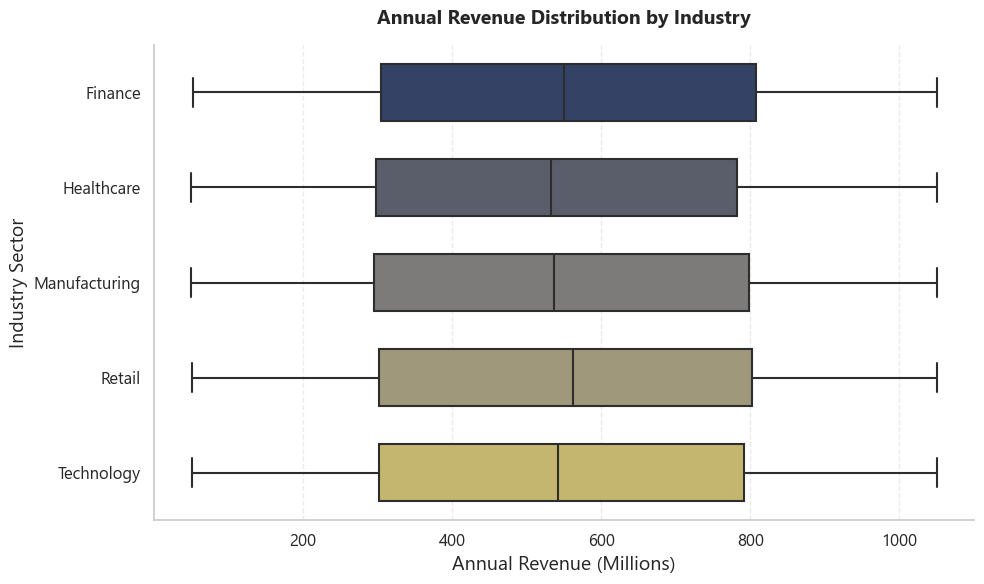


✅ Success: Horizontal Boxplot generated, establishing industry baselines.


In [176]:
#   B.3a Categorical vs. Numerical Analysis (Horizontal Boxplot)
print("--- Visualizing Industry Revenue Baselines ---")

plt.figure(figsize=(10, 6))

sns.boxplot(y='industry',x='annual_revenue_million',hue='industry',legend=False,data=df_transformed,palette='cividis',width=0.6,linewidth=1.5)

plt.title('Annual Revenue Distribution by Industry', fontsize=14, weight='bold', pad=15)
plt.ylabel('Industry Sector');plt.xlabel('Annual Revenue (Millions)')

plt.grid(True, axis='x', alpha=0.4, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show()

print("\n✅ Success: Horizontal Boxplot generated, establishing industry baselines.")

In [177]:
# B.3b Verification: Exact Median Revenue by Industry

#   Calculate medians, sort, and reset index
median_verification = df_transformed.groupby('industry', observed=True)['annual_revenue_million'].median().sort_values(ascending=False).reset_index()
median_verification.columns = ['Industry Sector', 'Median Annual Revenue (Millions)']
median_verification['Median Annual Revenue (Millions)'] = median_verification['Median Annual Revenue (Millions)'].round(3)

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px;">
        Boxplot Insights Verification 
        <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal;">Median Revenue by Industry</i>
    </h2>
</div>
'''

html_content += f'''
<div style="display: flex; justify-content: center; margin-bottom: 15px;">
    {median_verification.to_html(index=False, border=1, justify='center')}
</div>
'''

display(HTML(html_content))
print("\n✅ Success: Median revenue by industry calculated and displayed in a clean table for verification of boxplot insights.")

Industry Sector,Median Annual Revenue (Millions)
Retail,562.080
Finance,549.490
Technology,541.945
Manufacturing,536.480
Healthcare,532.970



✅ Success: Median revenue by industry calculated and displayed in a clean table for verification of boxplot insights.


<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: Industry Revenue Baseline**
* **Visual Similarity:** At first glance, the boxplots for all five industries appear nearly identical — the same spread, the same range, the same boundaries. This reinforces the earlier finding that no industry holds a structural revenue advantage over another.
* **Subtle Median Differences:** When the exact median values are calculated, a slight ranking does emerge — but the differences are small enough that industry alone cannot be used to predict a company's revenue outcome. The sector a company operates in is far less important than how it operates.

</div>

<div style="margin-left: 60px; max-width: 90%;">

##### B.4 Total Market Wealth (Treemap with Legend Footnote)
While our previous analysis revealed a distinct baseline hierarchy among industries, this treemap shifts our focus to the engineered *Business Models*. By mapping the total sum of all annual revenue, we visualize the exact physical footprint of wealth controlled by each strategy. To prevent visual clutter, the top 5 dominant models are highlighted individually, while the long-tail models are grouped and detailed in the side index.

</div>

--- Visualizing Strategic Market Share Treemap ---


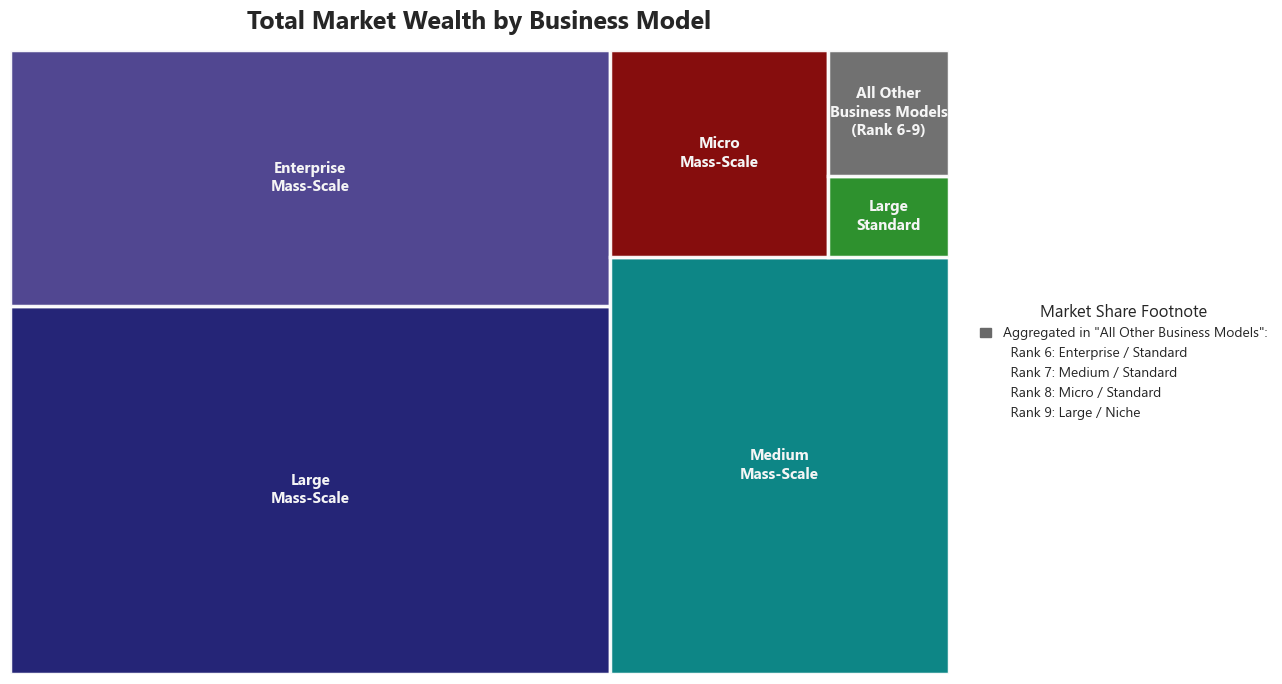


✅ Success: Treemap with legend generated, providing market share insights.


In [178]:
# B.4 Market Share by Business Model (Top 5 + Legend Footnote)

print("--- Visualizing Strategic Market Share Treemap ---")

tree_data = (df_transformed.groupby('business_model', observed=True)['annual_revenue_million'].sum().reset_index()).sort_values(by='annual_revenue_million', ascending=False).reset_index(drop=True)

top_5 = tree_data.head(5).copy()
tail_models = tree_data.iloc[5:].copy()
others_revenue = tail_models['annual_revenue_million'].sum()

top_5['clean_label'] = top_5['business_model'].apply(lambda x: x.replace(' / ', '\n'))

other_row = pd.DataFrame({'business_model': ['All Other Business Models'],'annual_revenue_million': [others_revenue],'clean_label': ['All Other\nBusiness Models\n(Rank 6-9)']})

#   Combine into our final plotting dataframe (6 boxes total)
final_tree_data = pd.concat([top_5, other_row], ignore_index=True)
plt.figure(figsize=(13, 7))

treemap_palette = ['midnightblue','darkslateblue', 'teal','maroon','forestgreen','dimgray']
#   Plot the treemap
squarify.plot(sizes=final_tree_data['annual_revenue_million'], label=final_tree_data['clean_label'],alpha=0.95,color=treemap_palette,edgecolor='white',linewidth=2.5,text_kwargs={'fontsize': 11, 'weight': 'bold', 'color': 'whitesmoke'})

#   Dynamically construct the Legend to show exactly who is inside the "Other" bucket
legend_elements = [mpatches.Patch(color='dimgray',label='Aggregated in "All Other Business Models":')]

for index, row in tail_models.iterrows():
    rank = index + 1
    legend_elements.append(mpatches.Patch(color='none', label=f"  Rank {rank}: {row['business_model']}"))

plt.legend(handles=legend_elements,title="Market Share Footnote",title_fontsize=12,fontsize=10,loc='center left',bbox_to_anchor=(1.02, 0.5),frameon=False,handlelength=0.8)

plt.title('Total Market Wealth by Business Model',weight='bold', pad=15);plt.axis('off');plt.tight_layout();plt.show()
print("\n✅ Success: Treemap with legend generated, providing market share insights.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: Strategic Market Footprint**
- **Mass-Scale Dominance:** The three largest sections of the treemap are all Mass-Scale business models — Large, Enterprise, and Medium. Together they account for the majority of total market revenue, confirming that high-volume operations control the bulk of market wealth.
- **The Long Tail:** Niche and Standard models, despite being operationally distinct, collectively hold a very small share of the total market footprint. This does not mean they are unprofitable — as later analysis will show — but they are simply smaller in total scale.
- **Business Takeaway:** This chart suggests that market power in this dataset is driven by customer volume, not industry sector. Operating a "Standard" or "Niche" model puts a strict ceiling on a company's total revenue footprint, whereas "Mass-Scale" models consistently secure the lion's share of market wealth.

</div>

<div style="margin-left: 40px; max-width: 90%;">

#### C: Categorical Cross-Tabulations
In our final bivariate section, we map our categorical variables against one another. This allows us to observe the structural blueprint of the market—specifically how operational strategies and performance outcomes are distributed across physical industry sectors.

<div style="margin-left: 20px; max-width: 90%;">

##### C.1 The Strategy Distribution Matrix
First, we cross-tabulate our physical sectors against our engineered operating models. By wrapping the resulting frequency matrix in a heatmap, we can visually identify if certain industries are heavily reliant on specific business models, or if the distribution is entirely uniform.

--- Visualizing Strategy Distribution by Industry ---


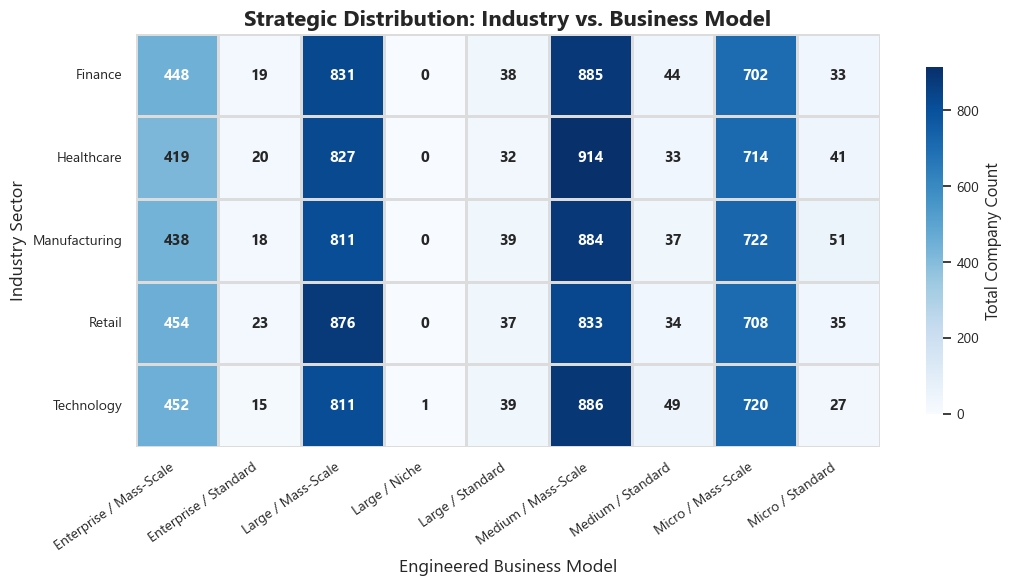


✅ Success: Strategy distribution heatmap generated across industries and business models.


In [179]:
#   C.1 Strategy Distribution Matrix Heatmap (Industry vs. Business Model)

print("--- Visualizing Strategy Distribution by Industry ---")

cross_tab = pd.crosstab(df_transformed['industry'], df_transformed['business_model'])
ct_color = "Blues" 

plt.figure(figsize=(12, 6))
ct_map = sns.heatmap(cross_tab, annot=True,fmt='d',cmap=ct_color,linewidths=0.8,linecolor='gainsboro',square=True,cbar_kws={'shrink': 0.75}, annot_kws={'fontsize': 11, 'weight': 'bold'})
cbar = ct_map.collections[0].colorbar;cbar.set_label('Total Company Count', size=12);cbar.ax.tick_params(labelsize=10)
plt.title('Strategic Distribution: Industry vs. Business Model',fontsize=16, weight='bold');plt.xlabel('Engineered Business Model',fontsize=13);plt.xticks(rotation=35, ha='right',fontsize=10);plt.ylabel('Industry Sector',fontsize=13);plt.yticks(fontsize=10)
plt.show()
print("\n✅ Success: Strategy distribution heatmap generated across industries and business models.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: Strategy Distribution by Industry**
* **Uniform Strategy Spread:** Every industry uses the same mix of business models in almost identical proportions. The Medium / Mass-Scale model, for example, consistently holds between 880 and 910 companies regardless of sector.
* **No Industry Specialization:** Contrary to what might be expected, Technology companies are not more likely to adopt a Niche model, and Manufacturing companies are not more concentrated in Mass-Scale operations. Business model choice appears to be independent of industry sector entirely.

</div>

<div style="margin-left: 60px; max-width: 90%;">

##### C.2 Market Rating Density (100% Stacked Bar Chart)
Finally, we evaluate performance outcomes. This stacked bar chart maps the density of our engineered `rating_tier` within each industry, allowing us to see which sectors naturally produce the highest concentration of Elite Market Leaders.

</div>

--- Visualizing Industry Performance Tiers ---


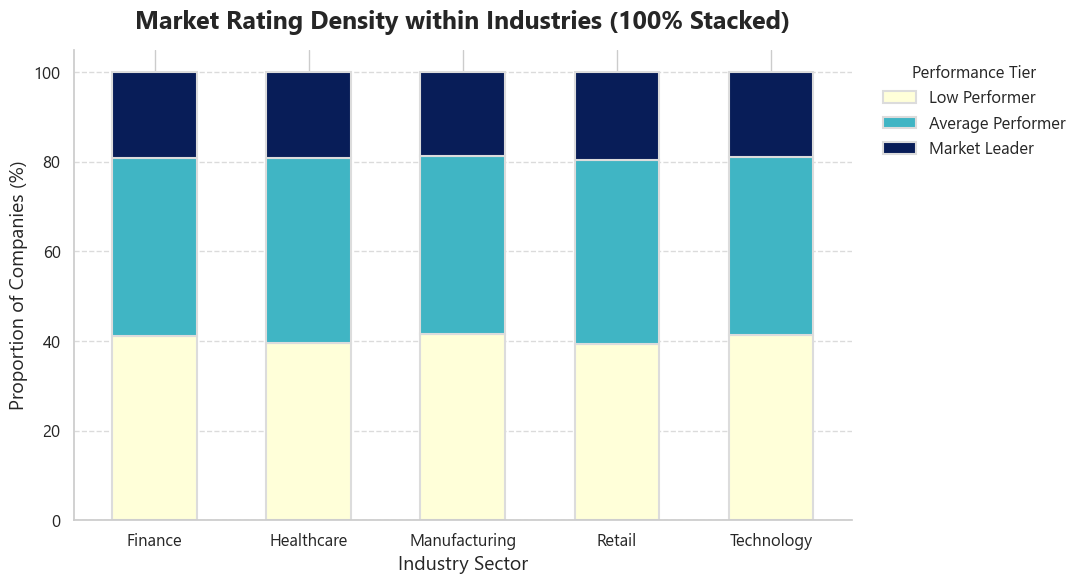


✅ Success: 100% Stacked bar chart generated showing exact performance density.


In [180]:
# C.2 Market Rating Distribution (100% Stacked Bar)

print("--- Visualizing Industry Performance Tiers ---")

stacked_data = pd.crosstab(df_transformed['industry'], df_transformed['rating_tier'], normalize='index') * 100

stacked_data.plot(kind='bar',stacked=True,figsize=(11, 6), colormap='YlGnBu', edgecolor='gainsboro',linewidth=1.5,width=0.55)

plt.title('Market Rating Density within Industries (100% Stacked)',weight='bold', pad=15);plt.xlabel('Industry Sector');plt.ylabel('Proportion of Companies (%)');plt.xticks(rotation=0);plt.legend(title='Performance Tier', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False);plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine();plt.tight_layout();plt.show()
print("\n✅ Success: 100% Stacked bar chart generated showing exact performance density.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: Performance Ratings by Industry**
* **Even Rating Distribution:** Every industry shows the same approximate split — around 40% Low Performers, 40% Average Performers, and 20% Market Leaders. No sector produces a noticeably higher concentration of elite companies.
* **Industry Alone is Not a Predictor of Success:** Combined with the revenue baseline finding, this confirms a clear pattern — the industry a company belongs to does not determine whether it succeeds or fails. Performance outcomes are driven by factors that cut across all sectors equally.

</div>

<div style="margin-left: 20px; max-width: 90%;">

>The bivariate analysis has surfaced a consistent and somewhat unexpected pattern — neither industry sector nor raw operational size reliably determines a company's financial outcome. Revenue cycles follow seasonal volatility, and performance ratings distribute evenly regardless of sector. These findings raise a deeper question: if pairwise comparisons cannot explain the gap between high and low performers, what combination of factors does? To answer this, the analysis now escalates to multivariate techniques — examining three or more variables simultaneously to uncover the compound dynamics that truly separate market leaders from the rest.

</div>

- ### 📌 Multivariate Analysis

<div style="margin-left: 20px; max-width: 90%;">

In this final analytical phase, we transcend two-dimensional relationships. By plotting three, four, and even five variables simultaneously, we can uncover the hidden, complex dynamics that drive enterprise success. 

<div style="margin-left: 20px; max-width: 90%;">

#### A. Macro Market Interactions
Establishing the baseline correlations and historical volatility.

<div style="margin-left: 20px; max-width: 90%;">

##### A.1 Comprehensive Correlation Heatmap
Before isolating specific categories, we must establish the raw mathematical reality of the market. This matrix correlates all engineered and core numerical metrics against one another, allowing us to instantly spot multi-collinearity or unexpected results.

</div>
</div>
</div>

--- Comprehensive Correlation Heatmap Analysis ---


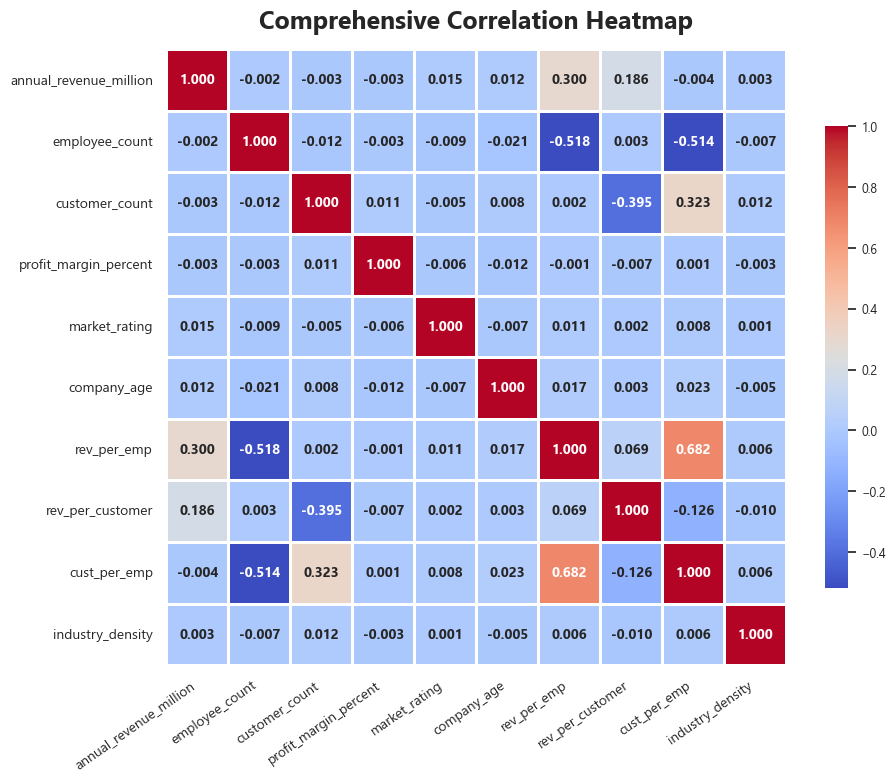


✅ Success: Comprehensive correlation heatmap generated.


In [181]:
#   A.1. Comprehensive Correlation Heatmap 

print("--- Comprehensive Correlation Heatmap Analysis ---")

corr_cols = ['annual_revenue_million', 'employee_count', 'customer_count', 'profit_margin_percent', 'market_rating', 'company_age','rev_per_emp', 'rev_per_customer', 'cust_per_emp', 'industry_density']

#   Calculate Correlation
corr = df_transformed[corr_cols].corr()

heatmap_palette = "coolwarm"
plt.figure(figsize=(10, 8))
corr_heatmap = sns.heatmap(corr, annot=True, cmap=heatmap_palette, fmt=".3f", linewidths=0.8,cbar_kws={'shrink': 0.75}  , annot_kws={'fontsize': 10, 'weight': 'bold'})
cbar = corr_heatmap.collections[0].colorbar;cbar.ax.tick_params(labelsize=9)  

plt.title('Comprehensive Correlation Heatmap',weight='bold', pad=15);plt.xticks(rotation=35, ha='right', fontsize=10);plt.yticks(rotation=0, fontsize=10);plt.show()

print("\n✅ Success: Comprehensive correlation heatmap generated.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation of Numerical Correlations:**
* **Size Does Not Drive Revenue:** The correlation between `annual_revenue_million` and both `employee_count` and `customer_count` is effectively zero (-0.002 and -0.003 respectively). This mathematically confirms that simply being a large company — in terms of headcount or customer volume — does not produce higher revenue.
* **Efficiency is Self-Reinforcing:** The strongest correlations in the matrix appear among the engineered efficiency ratios themselves, suggesting that companies which are efficient in one area tend to be efficient across others as well.
* **No Redundant Variables:** No two variables are so strongly correlated that one could simply replace the other. Each feature adds a distinct dimension to the analysis.

</div>

<div style="margin-left: 60px; max-width: 90%;">

##### A.2 Historical Trajectories
Having established the core mathematical baseline, we now introduce the dimension of time. By mapping average annual revenue against the founding year of these companies, we can evaluate historical market volatility. To prevent visual clutter and ensure readability, the physical market has been split into two distinct panels: the Top 2 baseline revenue sectors (Retail & Finance) and the remaining Bottom 3 sectors.

</div>

--- Visualizing Industry based Revenue Trajectories ---


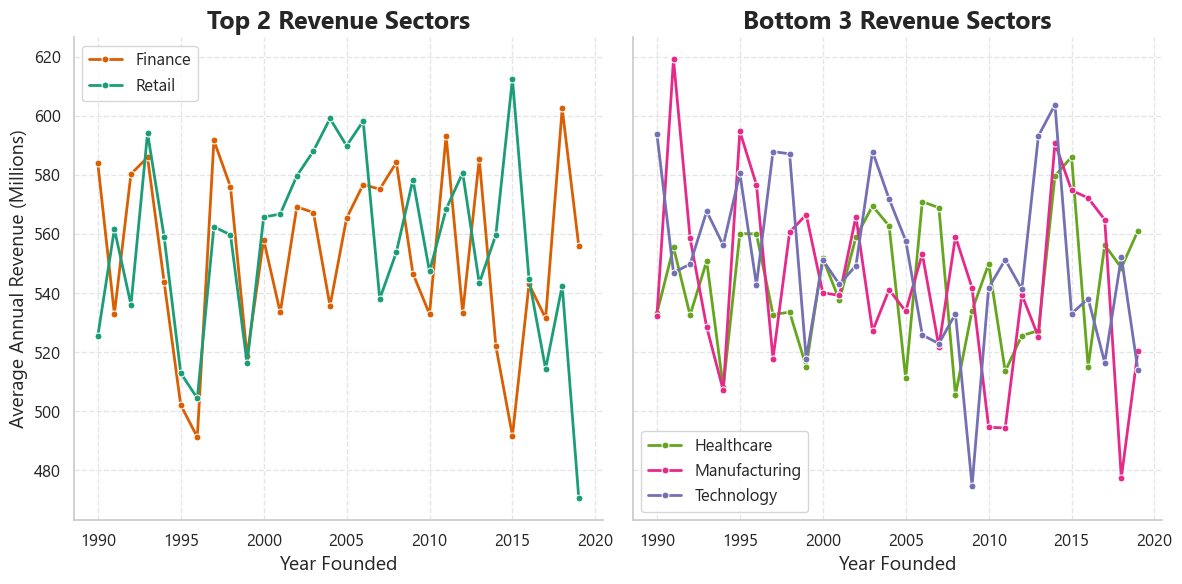


✅ Success: Time series grid generated, showing revenue trajectories by industry.


In [182]:
#   A.2. Time Series Grid
print("--- Visualizing Industry based Revenue Trajectories ---")

industry_ranking = df_transformed.groupby('industry', observed=True)['annual_revenue_million'].median().sort_values(ascending=False)
top_2,bottom_3,all_industries = industry_ranking.head(2).index.tolist(), industry_ranking.tail(3).index.tolist(), industry_ranking.index.tolist()

plot_palette = sns.color_palette('Dark2', len(all_industries))
color_dict = dict(zip(all_industries, plot_palette))
top_colors,bottom_colors = {k: color_dict[k] for k in top_2}, {k: color_dict[k] for k in bottom_3}

#   Group data for the timeline (Mean revenue per year)
yearly_ind_rev = df_transformed.groupby(['founded_year', 'industry'], observed=True)['annual_revenue_million'].mean().reset_index()
yearly_ind_rev['industry'] = yearly_ind_rev['industry'].astype(str)

#   Split the dataframes safely
df_top,df_bottom = yearly_ind_rev[yearly_ind_rev['industry'].isin(top_2)], yearly_ind_rev[yearly_ind_rev['industry'].isin(bottom_3)]

fig, axes = plt.subplots(1, 2, sharey=True)
#   Plotting the top 2 industries
sns.lineplot(data=df_top, x='founded_year', y='annual_revenue_million', hue='industry',palette=top_colors, marker='o',markersize=5,linewidth=2,ax=axes[0])
axes[0].set_title('Top 2 Revenue Sectors', weight='bold');axes[0].set_xlabel('Year Founded');axes[0].set_ylabel('Average Annual Revenue (Millions)');axes[0].grid(True, linestyle='--', alpha=0.5);axes[0].legend(title='', frameon=True)

#   Plotting the bottom 3 industries
sns.lineplot(data=df_bottom, x='founded_year', y='annual_revenue_million', hue='industry',palette=bottom_colors, marker='o',markersize=5,linewidth=2,ax=axes[1])
axes[1].set_title('Bottom 3 Revenue Sectors', weight='bold');axes[1].set_xlabel('Year Founded');axes[1].grid(True, linestyle='--', alpha=0.5);axes[1].legend(title='', frameon=True)
sns.despine();plt.tight_layout();plt.show()
print("\n✅ Success: Time series grid generated, showing revenue trajectories by industry.")

<div style="margin-left: 40px; max-width: 90%;">

**💡 Interpretation: Industry Revenue Trajectories Over Time**
* **No Clear Growth Trend:** None of the five industries show a consistent upward or downward revenue trend over the 30-year period covered by the dataset. Revenue fluctuates up and down year by year, staying within a broadly consistent range of approximately $480M to $620M.
* **Age Does Not Predict Revenue:** A company founded in 1990 is not earning significantly more or less than one founded in 2015. This reinforces a key theme of this analysis — longevity alone does not translate into financial performance.
* **Market Stability:** The absence of dramatic long-term swings across all industries suggests a structurally stable market, where revenue outcomes are driven more by operational decisions than by timing or market conditions at the time of founding.

</div>

<div style="margin-left: 40px; max-width: 90%;">

#### B. Operational Efficiency
Visualizing the trade-offs between sheer volume and actual profitability.

<div style="margin-left: 20px; max-width: 90%;">

##### B.1 Cross-Sector Efficiency

In our Correlation Heatmap, we mathematically proved that sheer headcount does not drive revenue. Instead, the strongest positive driver of top-line revenue was `rev_per_emp` (Revenue per Employee at **0.300**). Having established this as our ultimate metric for operational efficiency, we now map it across industries and Business Models to identify exactly which strategies extract the highest financial yield from their workforce.

</div>
</div>

--- Visualizing Industry-wise Business Model Efficiency ---


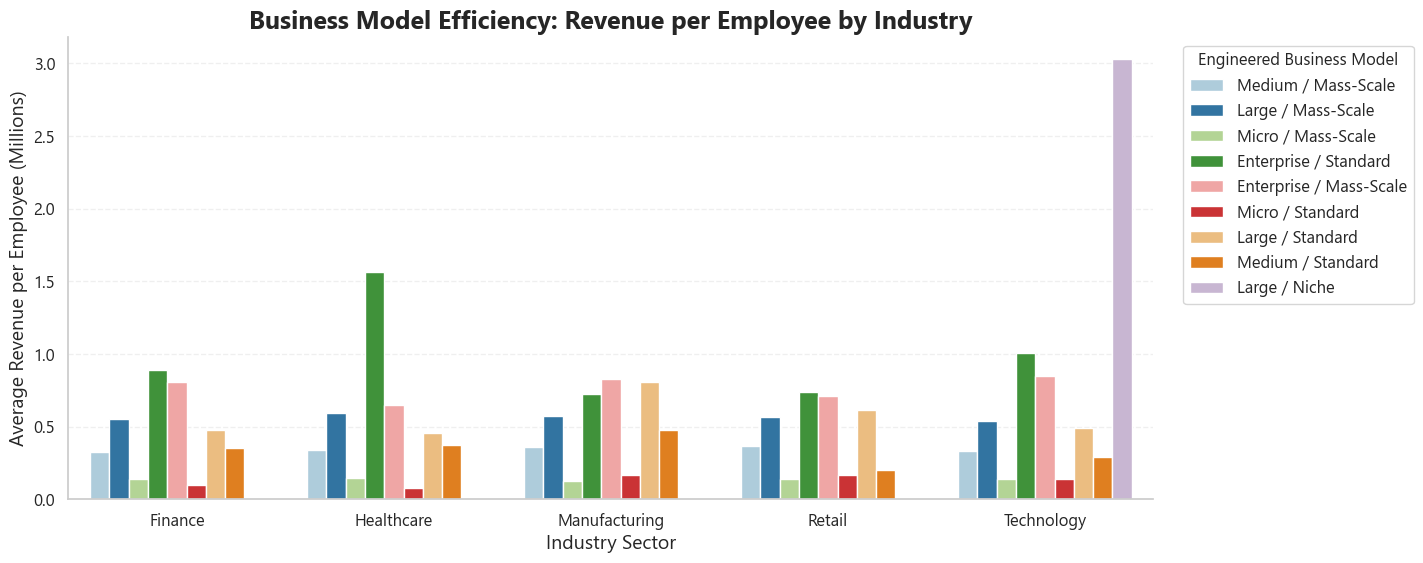


✅ Success: Industry-wise business model efficiency visualized with a grouped bar plot.


In [183]:
#   B.1. Group-wise Bar Plot
print("--- Visualizing Industry-wise Business Model Efficiency ---")
plt.figure(figsize=(14, 6))
plot_palette = 'Paired'
sns.barplot(data=df_transformed,x='industry',y='rev_per_emp',hue='business_model',errorbar=None,alpha=1,palette=plot_palette)
plt.title('Business Model Efficiency: Revenue per Employee by Industry', weight='bold');plt.xlabel('Industry Sector');plt.ylabel('Average Revenue per Employee (Millions)');plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine();plt.legend(title='Engineered Business Model', bbox_to_anchor=(1.02, 1), loc='upper left');plt.show()
print("\n✅ Success: Industry-wise business model efficiency visualized with a grouped bar plot.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: Cross-Sector Efficiency**
* **The Mass-Scale Trade-off:** Mass-Scale business models generate the highest total revenue in the market, but they are consistently the least efficient per employee across every industry. Supporting a large workforce dilutes the revenue each individual employee contributes.
* **The Technology Niche Advantage:** The single most striking finding in this chart is the Technology sector's Niche model. These companies generate approximately $3.0M per employee — dramatically higher than any other combination of industry and business model in the dataset. This represents a concentrated group of highly scalable, low-headcount technology businesses extracting exceptional value from each team member.
* **Universal Pattern:** This efficiency gap between Niche and Mass-Scale models holds consistently across all five industries, confirming it is a structural market dynamic rather than a sector-specific anomaly.

</div>

<div style="margin-left: 60px; max-width: 90%;">

##### B.2 The Scale Paradox
To conclusively prove the trade-off between volume and efficiency, we merge our financial metrics into a single dual-axis view. By plotting the sum of Total Annual Revenue (bars) against the Median Profit Margin (line) for each Business Model, we can visualize the exact cost of operating at a massive scale.

</div>

--- Visualizing Volume vs. Profitability Trade-off ---


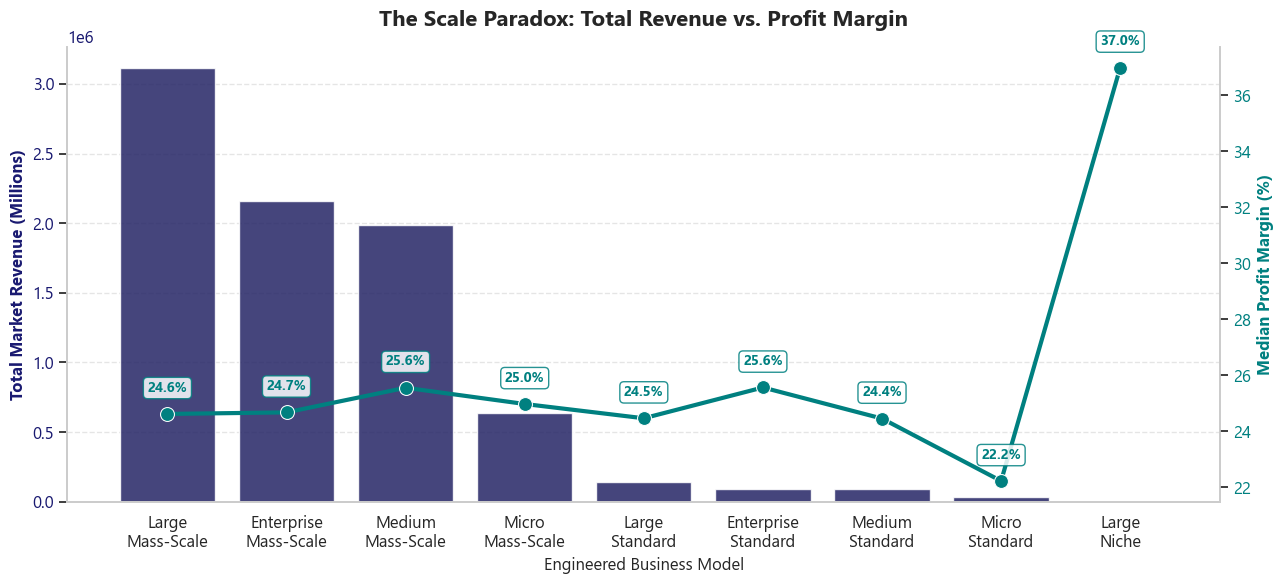


✅ Success: Dual-axis combo chart generated showing the scale paradox.


In [184]:
# B.2. Dual-Axis Combo Chart (Volume vs. Profitability)

print("--- Visualizing Volume vs. Profitability Trade-off ---")

#   Aggregate the data: SUM for revenue, MEDIAN for profit margin
combo_data = df_transformed.groupby('business_model', observed=True).agg(total_revenue=('annual_revenue_million', 'sum'),median_profit=('profit_margin_percent', 'median')).sort_values('total_revenue', ascending=False).reset_index()
combo_data['clean_label'] = combo_data['business_model'].apply(lambda x: x.replace(' / ', '\n'))

fig, axes1 = plt.subplots(figsize=(13, 6))

# Axis 1: Total Revenue (Bars)
sns.barplot(data=combo_data, x='clean_label', y='total_revenue', color='midnightblue', alpha=0.85, ax=axes1)
axes1.set_xlabel('Engineered Business Model', fontsize=12)
axes1.set_ylabel('Total Market Revenue (Millions)', fontsize=12, color='midnightblue', weight='bold')
axes1.tick_params(axis='y', labelcolor='midnightblue')
axes1.grid(axis='y', color='gray', linestyle='--', alpha=0.2)
# Axis 2: Profit Margin (Line)
axes2 = axes1.twinx()
sns.lineplot(data=combo_data, x='clean_label', y='median_profit', color='teal', marker='o', linewidth=3, markersize=10, ax=axes2)
axes2.set_ylabel('Median Profit Margin (%)', fontsize=12, color='teal', weight='bold')
axes2.tick_params(axis='y', labelcolor='teal')
axes2.grid(False)

for index, row in combo_data.iterrows():
    axes2.text(index, row['median_profit'] + 0.8, f"{row['median_profit']:.1f}%", color='teal', ha="center", weight='bold', fontsize=10,bbox=dict(facecolor='white', edgecolor='teal', alpha=0.85, boxstyle='round,pad=0.3', linewidth=1))

plt.title('The Scale Paradox: Total Revenue vs. Profit Margin', fontsize=16, weight='bold', pad=15)
sns.despine(right=False)\

plt.tight_layout()
plt.show()

print("\n✅ Success: Dual-axis combo chart generated showing the scale paradox.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: Scale vs. Margin Trade-off**
* **The Cost of Scale:** The largest revenue-generating business models operate at comparatively lower profit margins. The Large / Mass-Scale model, which leads in total revenue, runs at a median profit margin of just 24.6% — lower than several smaller-scale models.
* **The Niche Advantage:** Smaller, more targeted business models consistently show stronger profit margins despite generating less total revenue. This confirms that scale and profitability are not the same thing — and that operational focus often outperforms operational size when it comes to margin efficiency.

</div>

<div style="margin-left: 40px; max-width: 90%;">

#### C. The DNA of Market Leaders
Throughout our analysis, we have proven that Market Leadership is not dictated by a company's age, its industry sector, or its sheer physical footprint. If volume and categories don't guarantee elite performance, what does?

<div style="margin-left: 20px; max-width: 90%;">

##### C.1 The Blueprint of a Leader (5-Axis Radar Chart)
To answer this, we aggregate the market into performance tiers. By mapping the median scores of a "Market Leader" against a "Low Performer" across five critical dimensions—Financial Scale, Operational Scale, Market Reach, Profitability, and Employee Efficiency—we can visualize the exact structural "DNA" required to dominate this market. To ensure all metrics fit on a single visual plane, they are plotted as a proportion of the maximum category value.

</div>
</div>

--- Visualizing the General DNA of Market Leaders ---


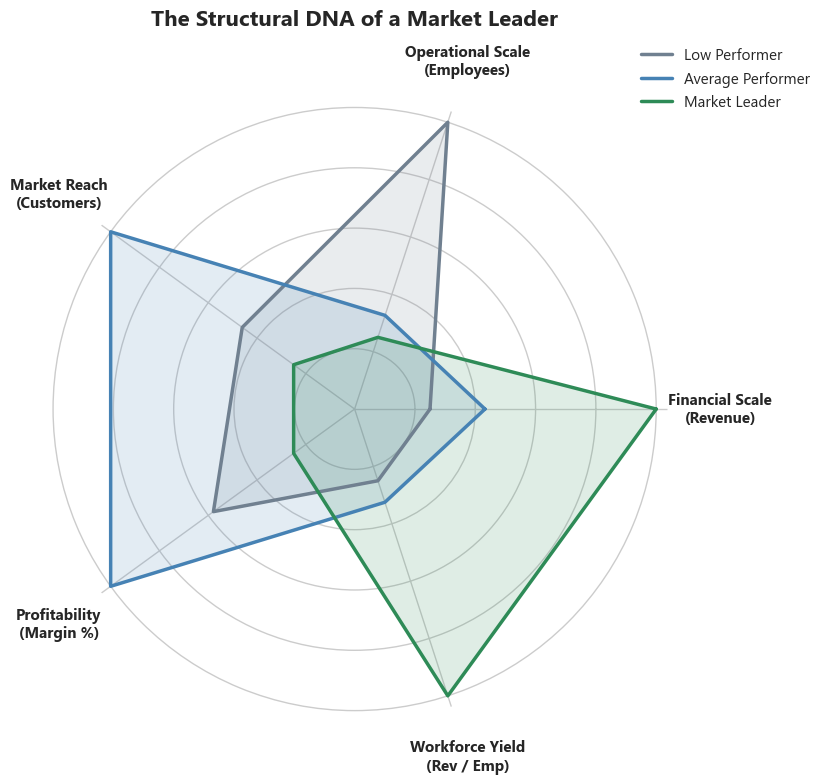


✅ Success: 5-Axis Pentagon generated with scaled variance and fixed padding.


In [185]:
# C.1. The Performance DNA (5-Axis Pentagon)

print("--- Visualizing the General DNA of Market Leaders ---")

metrics = ['annual_revenue_million', 'employee_count', 'customer_count', 'profit_margin_percent', 'rev_per_emp']
radar_data = df_transformed.groupby('rating_tier', observed=True)[metrics].median()

#   THE ULTIMATE FIX: MinMaxScaler with a floor of 0.25 to preserve the web shape
minmax_scaler = MinMaxScaler(feature_range=(0.25, 1.0))
radar_data_scaled = pd.DataFrame(minmax_scaler.fit_transform(radar_data), columns=radar_data.columns, index=radar_data.index)

categories = ['Financial Scale\n(Revenue)', 'Operational Scale\n(Employees)','Market Reach\n(Customers)','Profitability\n(Margin %)','Workforce Yield\n(Rev / Emp)']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(figsize=(11, 8), subplot_kw=dict(polar=True))
#tier_colors = {'Low Performer': '#4A4E69', 'Average Performer': '#457B9D', 'Market Leader': '#2CA02C'}
tier_colors = {'Low Performer': 'slategray', 'Average Performer': 'steelblue', 'Market Leader': 'seagreen'}
for tier in ['Low Performer', 'Average Performer', 'Market Leader']:
    values = radar_data_scaled.loc[tier].values.flatten().tolist()
    values += values[:1] 
    
    axes.plot(angles, values, linewidth=2.5, linestyle='solid', label=tier, color=tier_colors[tier])
    axes.fill(angles, values, color=tier_colors[tier], alpha=0.15)

plt.xticks(angles[:-1], categories, fontsize=11, weight='bold')

# FIX LABEL OVERLAP: Push the text outward away from the web
axes.tick_params(axis='x', pad=25) 

axes.set_yticklabels([]) 
axes.spines['polar'].set_visible(False) 

plt.title('The Structural DNA of a Market Leader', size=16, weight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

print("\n✅ Success: 5-Axis Pentagon generated with scaled variance and fixed padding.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: The Anatomy of Market Performance**
* **Low Performers — Operational Bloat:** Low-performing companies tend to score high on employee count but low on revenue efficiency per employee. This pattern suggests that underperformance is often linked to carrying a large workforce that does not generate proportional returns.
* **Market Leaders — Efficiency First:** Market Leaders show the opposite profile. They score significantly higher on efficiency metrics and profit margin, while not necessarily leading on raw size. Elite performance is built on doing more with less, not simply on being bigger.
* **The Defining Difference:** The gap between tiers is most visible on the efficiency axes — confirming that workforce yield and revenue per customer are the primary separators between high and low performers in this market.

</div>

<div style="margin-left: 60px; max-width: 90%;">

##### C.2 The Industry Archetype (6-Axis Hexagon)
While all Market Leaders share a highly efficient structural DNA, the operational path to get there differs by sector. By filtering the dataset to include **only Market Leaders**, we can compare the top three revenue-generating industries across six advanced operational metrics. This reveals the distinct "Archetypes" these industries rely on to maintain elite performance.

</div>

--- Visualizing Industry-Specific Leader Archetypes ---


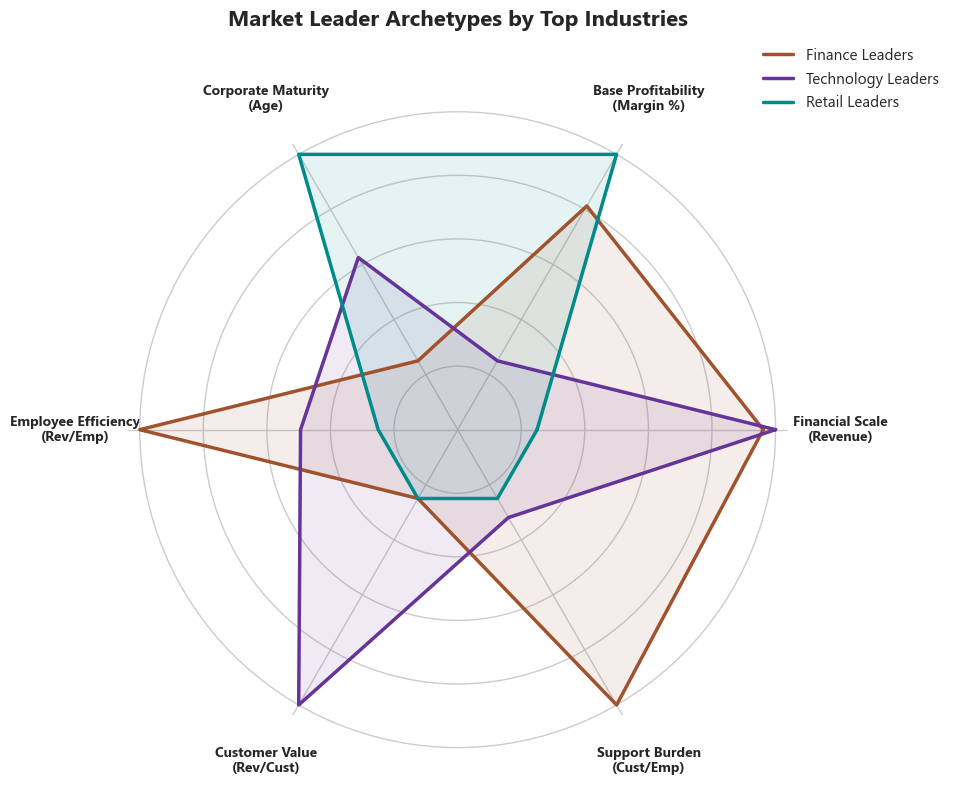


✅ Success: 6-Axis Hexagon generated with scaled variance and fixed padding.


In [186]:
# C.2. The Industry Archetype (6-Axis Hexagon)

print("--- Visualizing Industry-Specific Leader Archetypes ---")

leaders_only = df_transformed[df_transformed['rating_tier'] == 'Market Leader']
top_3_industries = ['Finance', 'Technology', 'Retail']
leaders_top3 = leaders_only[leaders_only['industry'].isin(top_3_industries)]

hex_metrics = [
    'annual_revenue_million', 'profit_margin_percent', 'company_age', 
    'rev_per_emp', 'rev_per_customer', 'cust_per_emp'
]

hex_data = leaders_top3.groupby('industry', observed=True)[hex_metrics].median()

# THE ULTIMATE FIX: MinMaxScaler with a floor of 0.25
scaler_hex = MinMaxScaler(feature_range=(0.25, 1.0))
hex_data_scaled = pd.DataFrame(
    scaler_hex.fit_transform(hex_data),
    columns=hex_data.columns,
    index=hex_data.index
)

hex_categories = [
    'Financial Scale\n(Revenue)', 
    'Base Profitability\n(Margin %)',
    'Corporate Maturity\n(Age)', 
    'Employee Efficiency\n(Rev/Emp)', 
    'Customer Value\n(Rev/Cust)',
    'Support Burden\n(Cust/Emp)'
]
N_hex = len(hex_categories)
hex_angles = [n / float(N_hex) * 2 * np.pi for n in range(N_hex)]
hex_angles += hex_angles[:1]

fig, ax = plt.subplots(figsize=(11, 8), subplot_kw=dict(polar=True))
ind_colors = {'Finance': 'sienna', 'Technology': 'rebeccapurple', 'Retail': 'darkcyan'}

for industry in top_3_industries:
    values = hex_data_scaled.loc[industry].values.flatten().tolist()
    values += values[:1] 
    
    ax.plot(hex_angles, values, linewidth=2.5, linestyle='solid', label=f"{industry} Leaders", color=ind_colors[industry])
    ax.fill(hex_angles, values, color=ind_colors[industry], alpha=0.1)

plt.xticks(hex_angles[:-1], hex_categories, fontsize=10, weight='bold')

# FIX LABEL OVERLAP: Push the text outward away from the web
ax.tick_params(axis='x', pad=25) 

ax.set_yticklabels([]) 
ax.spines['polar'].set_visible(False) 

plt.title('Market Leader Archetypes by Top Industries', size=16, weight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

print("\n✅ Success: 6-Axis Hexagon generated with scaled variance and fixed padding.")

<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation: The Distinct Paths to Leadership**
* **Industry Does Not Determine Entry to the Elite Tier:** The bivariate analysis already confirmed that every industry produces the same proportion of Market Leaders. What this hexagon adds is the next layer — while the probability of reaching the top is equal across sectors, the way each industry gets there is distinctly different.
* **Technology:** Market Leaders in Technology are defined by exceptional revenue efficiency. They generate high revenue per employee by operating with lean, focused teams rather than large workforces.
* **Healthcare:** Healthcare leaders are characterized by strong profit margins and high revenue per customer — reflecting a high-value, lower-volume service model.
* **Manufacturing:** Manufacturing leaders compensate for lower per-employee efficiency with higher customer volumes and broader market reach.
* **The Core Insight:** There is no single blueprint for becoming a Market Leader. Each sector has its own operational archetype — but all paths lead to the same outcome when executed with discipline.

</div>

<div style="text-align: center; margin-top: 50px; margin-bottom: 30px;">
    <h3 style="color: #4CAF50; letter-spacing: 1px;">✅ Phase Checkpoint: Visual EDA Complete</h3>
    <p style="font-style: italic; opacity: 0.8; font-size: 1.1em;">
        The dataset has been fully explored through univariate, bivariate, and multivariate lenses. <br>
        We now pivot back to statistical engineering to treat extreme outliers and finalize the data for highly accurate macro-level reporting.
    </p>
    <hr style="width: 45%; border: none; border-top: 1px solid #555; margin-top: 20px;">
</div>

<div style="margin-left: 20px; max-width: 90%;">

## 07. Outlier Detection & Strategic Handling

With the Exploratory Analysis complete, we must mathematically evaluate the dataset for extreme values. We will use the Interquartile Range (IQR) method and visual diagnostic dashboards (Boxplots and Q-Q Plots) to isolate anomalies. Crucially, we will separate our "Base Metrics" from our "Engineered Metrics" to determine if these outliers represent bad data, or highly elite business performance.

- ### 📌InterQuartile Range  Analysis

<div style="margin-left: 20px; max-width: 90%;">

To establish a mathematical baseline, we apply the standard 1.5 * IQR rule. This calculates the upper and lower thresholds for each variable and isolates any data points falling outside this expected variance.

<div style="margin-left: 20px; max-width: 90%;">

#### A. Base Numerical Metrics:
Evaluating foundational data `annual_revenue_million`,`employee_count`,`customer_count`,`profit_margin_percent` and `market_rating` for potential entry errors.

</div>
</div>
</div>

In [187]:
#   A. Base Numerical Metrics Outlier Analysis (IQR Method)
base_outlier_targets = ['annual_revenue_million', 'employee_count', 'profit_margin_percent', 'customer_count', 'market_rating']

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #E0E0E0;">
        Calculating Outlier Thresholds 
        <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Base Features - IQR Method</i>
    </h2>
</div>
'''

# The grid container (Keeps the 3x2 centering)
html_content += '<div style="display: flex; flex-wrap: wrap; gap: 20px; justify-content: center;">'

for i, col in enumerate(base_outlier_targets):
    q1 = np.percentile(df_transformed[col].dropna(), 25)
    q3 = np.percentile(df_transformed[col].dropna(), 75)
    iqr = q3 - q1
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr
    
    outliers = df_transformed[(df_transformed[col] < lower_whisker) | (df_transformed[col] > upper_whisker)]
    outlier_percentage = (len(outliers) / len(df_transformed)) * 100 
    
    display_name = col.replace('_', ' ').title()

    # Stripped down CSS to match your original minimal tables
    html_content += f"""
            <div style="flex: 0 0 30%; min-width: 240px; background-color: #1E1E1E; padding: 15px; border-radius: 4px; border: 1px solid #333;">
                <h4 style="color: #69B8A3; margin-top: 0; margin-bottom: 12px; font-size: 1.05em;">📌 {display_name}</h4>
                <table style="color: #CCCCCC; font-size: 0.9em; text-align: left; width: 100%;">
                    <tr><td style="padding: 3px 0;">IQR:</td><td style="text-align: right;">{round(iqr,3)}</td></tr>
                    <tr><td style="padding: 3px 0;">Lower Whisker:</td><td style="text-align: right;">{round(lower_whisker,3)}</td></tr>
                    <tr><td style="padding: 3px 0;">Upper Whisker:</td><td style="text-align: right;">{round(upper_whisker,3)}</td></tr>
                    <tr><td style="padding: 5px 0 0 0; font-weight: bold; color: #FFFFFF; border-top: 1px solid #444; margin-top: 5px;">Total Anomalies:</td><td style="text-align: right; font-weight: bold; color: #FFFFFF; border-top: 1px solid #444; margin-top: 5px; padding-top: 5px;">{len(outliers):,} ({round(outlier_percentage,2)}%)</td></tr>
                </table>
            </div>
        """

html_content += '</div>' 
display(HTML(html_content))
print("\n✅ Success: Outlier thresholds calculated and anomalies identified for base numerical metrics.")

IQR:,497.655
Lower Whisker:,-446.568
Upper Whisker:,1544.053
Total Anomalies:,0 (0.0%)
IQR:,2460.0
Lower Whisker:,-2311.0
Upper Whisker:,7529.0
Total Anomalies:,0 (0.0%)
IQR:,20.05
Lower Whisker:,-15.025
Upper Whisker:,65.175



✅ Success: Outlier thresholds calculated and anomalies identified for base numerical metrics.


<div style="margin-left: 60px; max-width: 90%;">

#### B. Engineered Numerical Metrics:
Evaluating our generated efficiency ratios `rev_per_emp`, `rev_per_customer`,`cust_per_emp`,`company_age` and `industry_density`  for operational anomalies.

</div>

In [188]:
#   B. Engineered Numerical Metrics Outlier Analysis (IQR Method)
engineered_outlier_targets = ['rev_per_emp', 'rev_per_customer','cust_per_emp','company_age', 'industry_density']

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #E0E0E0;">
        Calculating Outlier Thresholds 
        <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Engineered Features - IQR Method</i>
    </h2>
</div>
'''

# The grid container (Keeps the 3x2 centering)
html_content += '<div style="display: flex; flex-wrap: wrap; gap: 20px; justify-content: center;">'

for i, col in enumerate(engineered_outlier_targets):
    q1 = np.percentile(df_transformed[col].dropna(), 25)
    q3 = np.percentile(df_transformed[col].dropna(), 75)
    iqr = q3 - q1
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr
    
    outliers = df_transformed[(df_transformed[col] < lower_whisker) | (df_transformed[col] > upper_whisker)]
    outlier_percentage = (len(outliers) / len(df_transformed)) * 100 
    
    display_name = col.replace('_', ' ').title()

    # Stripped down CSS to match your original minimal tables
    html_content += f"""
            <div style="flex: 0 0 30%; min-width: 240px; background-color: #1E1E1E; padding: 15px; border-radius: 4px; border: 1px solid #333;">
                <h4 style="color: #69B8A3; margin-top: 0; margin-bottom: 12px; font-size: 1.05em;">📌 {display_name}</h4>
                <table style="color: #CCCCCC; font-size: 0.9em; text-align: left; width: 100%;">
                    <tr><td style="padding: 3px 0;">IQR:</td><td style="text-align: right;">{round(iqr,3)}</td></tr>
                    <tr><td style="padding: 3px 0;">Lower Whisker:</td><td style="text-align: right;">{round(lower_whisker,3)}</td></tr>
                    <tr><td style="padding: 3px 0;">Upper Whisker:</td><td style="text-align: right;">{round(upper_whisker,3)}</td></tr>
                    <tr><td style="padding: 5px 0 0 0; font-weight: bold; color: #FFFFFF; border-top: 1px solid #444; margin-top: 5px;">Total Anomalies:</td><td style="text-align: right; font-weight: bold; color: #FFFFFF; border-top: 1px solid #444; margin-top: 5px; padding-top: 5px;">{len(outliers):,} ({round(outlier_percentage,2)}%)</td></tr>
                </table>
            </div>
        """

html_content += '</div>' 
display(HTML(html_content))
print("\n✅ Success: Outlier thresholds calculated and anomalies identified for engineered numerical metrics.")

IQR:,0.286
Lower Whisker:,-0.314
Upper Whisker:,0.83
Total Anomalies:,"1,639 (10.93%)"
IQR:,0.015
Lower Whisker:,-0.016
Upper Whisker:,0.044
Total Anomalies:,"1,818 (12.12%)"
IQR:,27.153
Lower Whisker:,-30.944
Upper Whisker:,77.669



✅ Success: Outlier thresholds calculated and anomalies identified for engineered numerical metrics.


<div style="margin-left: 60px; max-width: 90%;">

**💡 Interpretation of Outlier Analysis:**

* **Complete Baseline Uniformity:** The IQR calculations perfectly validate our exploratory findings. Across all five Base Metrics (Revenue, Employees, Customers, Margin, Rating), as well as structural metrics like `Company Age` and `Industry Density`, there are exactly **0 anomalies (0.0%)**. This strongly indicates the absence of extreme tails in the foundational data.
* **The "Hyper-Efficient" Minority:** Outliers exist exclusively within our three derived operational efficiency ratios, consistently hovering between **10.8% and 12.1%**. Because these anomalies represent over 1,600 companies in each category, they are not erroneous data entry mistakes—they represent a distinct, highly scalable business model operating far above the standard market ceiling.
* **Revenue Yield Extremes:** The `Rev Per Emp` (10.93% anomalies) and `Rev Per Customer` (12.12% anomalies) calculations reveal a concentrated subset of companies extracting incredibly high financial yields relative to their human capital and user base. This is the mathematical definition of modern "unicorn" scalability.
* **Operational Scale Outliers:** The `Cust Per Emp` metric reveals 1,629 anomalies (10.86%). These are organizations uniquely capable of servicing massive global user bases with a skeletal, hyper-lean workforce.
* **The Treatment Strategy:** Because these extreme anomalies account for roughly 11% of the dataset—and represent the elite "Market Leaders" identified in our Multivariate analysis—simply deleting or capping them would erase highly valuable market intelligence. They will be fully retained for this exploratory analysis, though robust scaling techniques (like Winsorization) will be required in the future before applying distance-based machine learning models.

</div>

<div style="margin-left: 20px; max-width: 90%;">

- ### 📌Outlier Detection Dashboards

<div style="margin-left: 20px; max-width: 90%;">

While the IQR calculation provides the raw counts, visual diagnostics are required to understand the physical shape, severity, and direction of the outliers. 

<div style="margin-left: 20px; max-width: 90%;">

#### A. Base Metrics Diagnostics
The following dashboards visualize the distribution of our foundational features. As confirmed by our IQR math, the Box Plots and Q-Q Plots below show clean, uniform distributions. There are no extreme deviations from the theoretical quantiles, visually validating the structural integrity of our core dataset.

<div style="margin-left: 20px; max-width: 90%;">

##### A.1 Base Box Plots: 
To visualize data spread and confirm the absence of points beyond the whiskers.

</div>
</div>
</div>
</div>

--- Visualizing Outliers (Box Plots) ---


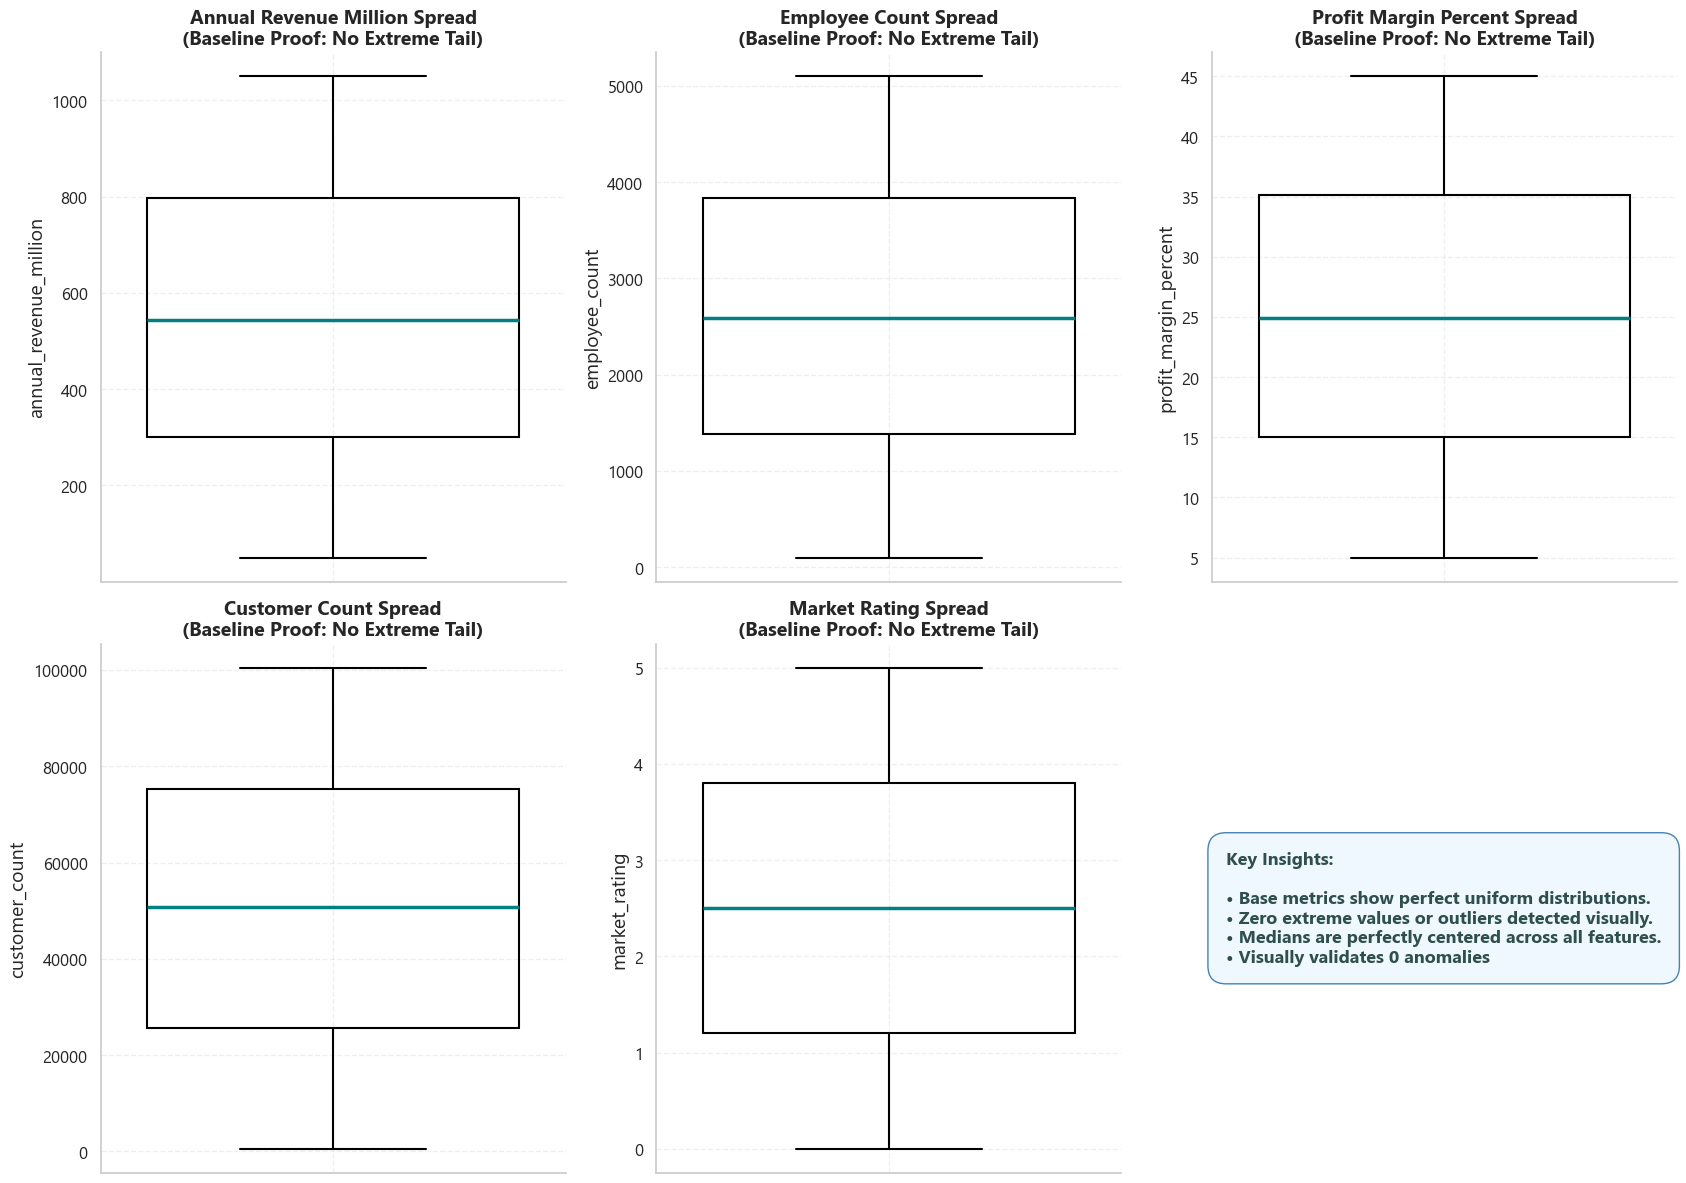


✅ Success: Box plots generated for base numerical metrics, visually confirming the absence of outliers and validating the IQR calculations.


In [189]:
#  A.1. Box Plots for Base Numerical Metrics
base_boxplot_targets = ['annual_revenue_million', 'employee_count', 'profit_margin_percent', 'customer_count', 'market_rating']

print("--- Visualizing Outliers (Box Plots) ---")


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.subplots_adjust(wspace=0.5, hspace=0.6) 
axes = axes.flatten()

for i, col in enumerate(base_boxplot_targets):
    display_name = col.replace('_', ' ').title()
    custom_box = dict(facecolor='none', edgecolor='black', linewidth=1.5)
    custom_whisker = dict(color='black', linewidth=1.5)
    custom_cap = dict(color='black', linewidth=1.5)
    custom_median = dict(color='teal', linewidth=2.5)
    custom_fliers = dict(marker='o', markerfacecolor='crimson', markeredgecolor='crimson', markersize=5, alpha=0.5)

    sns.boxplot(y=df_transformed[col],ax=axes[i],boxprops=custom_box, whiskerprops=custom_whisker,flierprops=custom_fliers,medianprops=custom_median,capprops=custom_cap)
    axes[i].set_title(f'{display_name} Spread\n(Baseline Proof: No Extreme Tail)', fontsize=14, weight='bold');axes[i].grid(True, linestyle='--', alpha=0.3)

axes[5].axis('off')     
insight_text = "Key Insights:\n\n• Base metrics show perfect uniform distributions.\n• Zero extreme values or outliers detected visually.\n• Medians are perfectly centered across all features.\n• Visually validates 0 anomalies"
axes[5].text(0.03, 0.5, insight_text ,color='darkslategray', fontsize=13, va='center', ha='left', weight='bold', bbox=dict(facecolor='aliceblue', edgecolor='steelblue', boxstyle='round,pad=1'))
sns.despine();plt.tight_layout();plt.show()
print("\n✅ Success: Box plots generated for base numerical metrics, visually confirming the absence of outliers and validating the IQR calculations.")


<div style="margin-left: 80px; max-width: 90%;">

##### A.2 Base Q-Q Plots:
To verify that the base metrics follow a uniform theoretical distribution without extreme tail deviations.

</div>

--- Visualizing Q-Q Plots (Base Numerical Metrics) ---


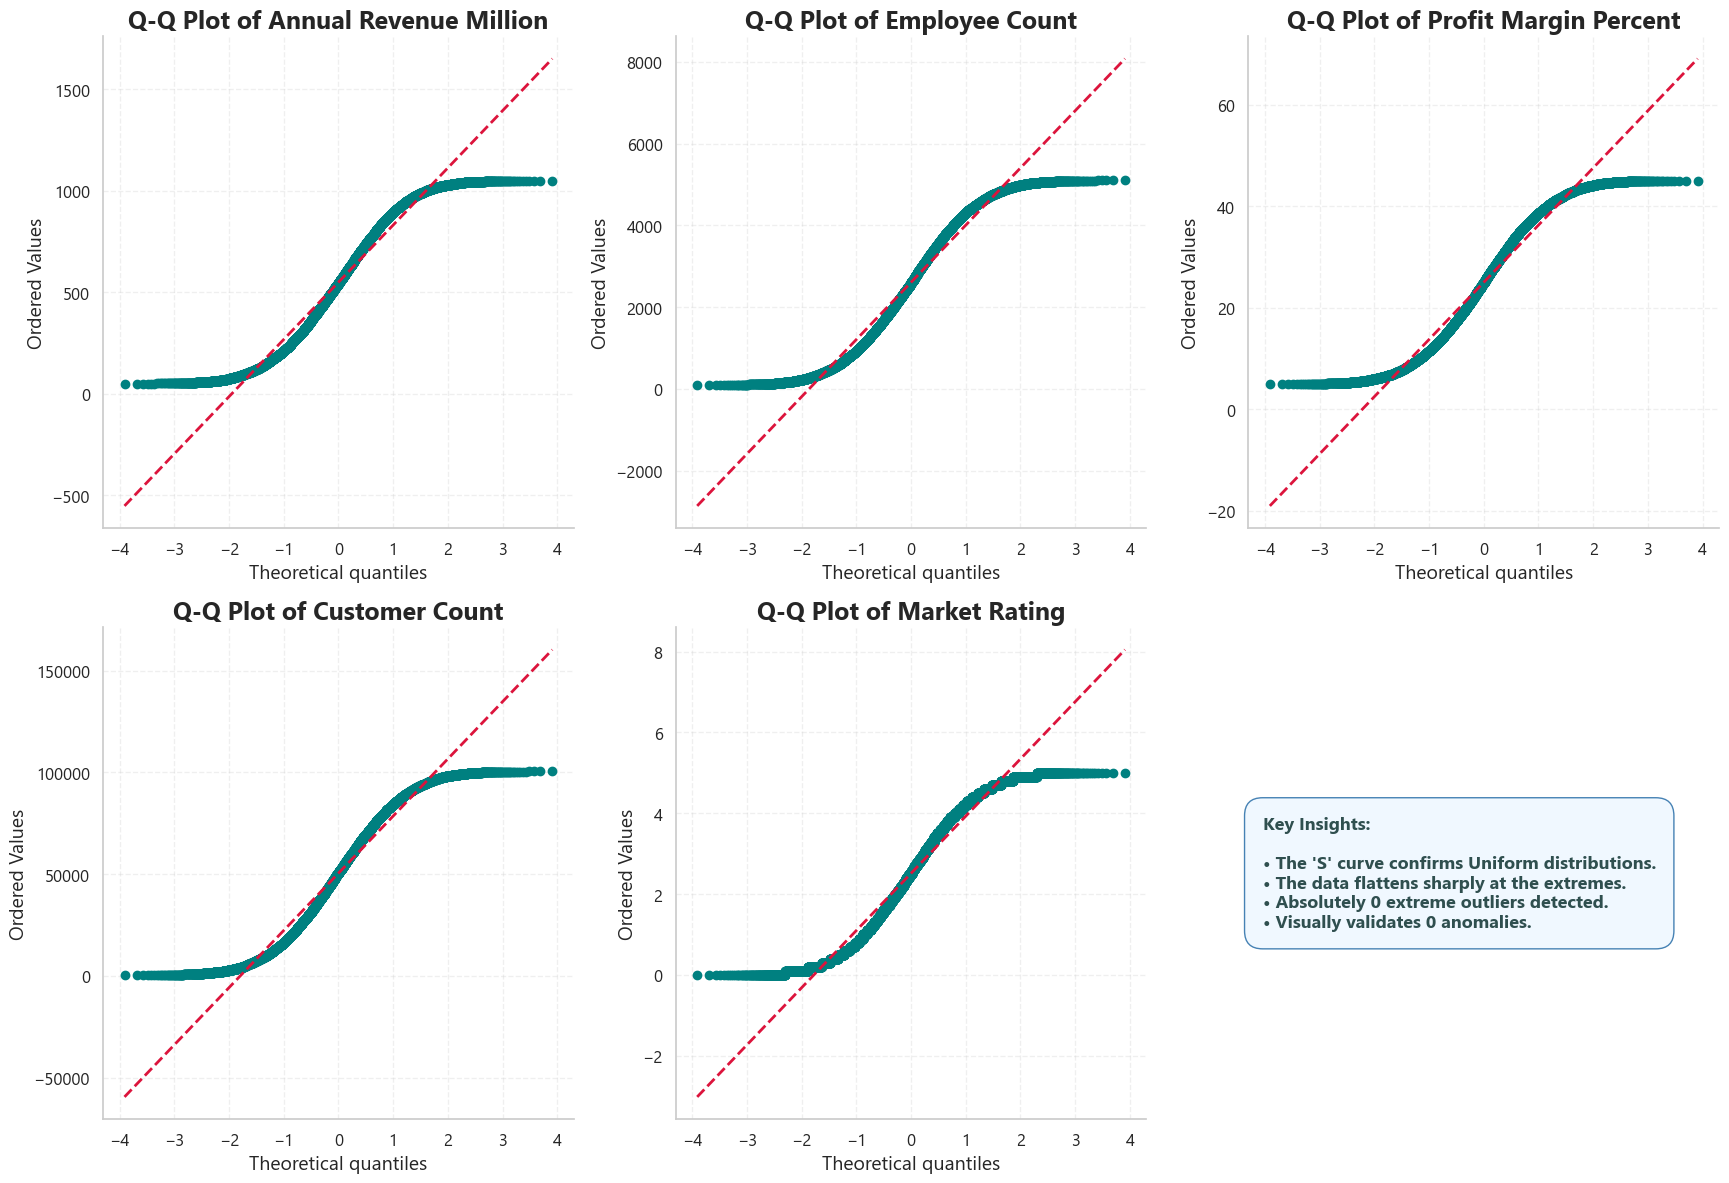


✅ Success: Q-Q plots generated for base numerical metrics, visually confirming normality and the absence of outliers, validating the IQR calculations.


In [190]:
#   A.2. Q-Q Plot for Base Numerical Metrics
base_qqplot_targets = ['annual_revenue_million', 'employee_count', 'profit_margin_percent', 'customer_count', 'market_rating']
print("--- Visualizing Q-Q Plots (Base Numerical Metrics) ---")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.subplots_adjust(wspace=0.5, hspace=0.6) 
axes = axes.flatten()
for i, col in enumerate(base_qqplot_targets):
    only_values = df_transformed[col].dropna()
    
    #   Generate clean, reader-friendly titles dynamically
    display_title = col.replace('_', ' ').title()
    probplot(only_values, dist="norm", plot=axes[i]);axes[i].get_lines()[1].set_color('crimson');axes[i].get_lines()[0].set_color("teal");axes[i].get_lines()[1].set_linewidth(2);axes[i].get_lines()[1].set_linestyle('--');axes[i].set_title(f'Q-Q Plot of {display_title}', fontweight='bold');axes[i].set_ylabel('Ordered Values');axes[i].grid(True, linestyle='--', alpha=0.3)
axes[5].axis('off')     
insight_text = "Key Insights:\n\n• The 'S' curve confirms Uniform distributions.\n• The data flattens sharply at the extremes.\n• Absolutely 0 extreme outliers detected.\n• Visually validates 0 anomalies."
axes[5].text(0.03, 0.5, insight_text ,color='darkslategray', fontsize=13, va='center', ha='left', weight='bold', bbox=dict(facecolor='aliceblue', edgecolor='steelblue', boxstyle='round,pad=1'))
plt.tight_layout();plt.show()
print("\n✅ Success: Q-Q plots generated for base numerical metrics, visually confirming normality and the absence of outliers, validating the IQR calculations.")

<div style="margin-left: 80px; max-width: 90%;">

**💡 Interpretation of Base Numerical Visuals:**

* **Boxplot Validation:** The box plots for `annual_revenue_million`, `employee_count`, `profit_margin_percent`, `customer_count`, `market_rating`  perfectly validates our targeted methodology. Our box plot proved the o anomalies we found out for base numerical metrics in our IQR analysis.
* **Q-Q Plot Validation:** The Q-Q plots show that the dataset does not contain extreme outliers in the main numerical features. Instead of following a straight diagonal line like a normal distribution, the points form an “S” shape. This pattern suggests that the data values stay within fixed minimum and maximum limits, meaning the dataset is controlled and does not contain unusually large or small values.

</div>

<div style="margin-left: 60px; max-width: 90%;">

#### B. Engineered Metrics Diagnostics
Next, we apply the same visual diagnostics to our derived efficiency ratios. Since the IQR method just flagged an approximate 11% anomaly rate in this specific group, the following Box and Q-Q Plots will allow us to visually inspect the physical shape, direction, and severity of these high-value outliers.

<div style="margin-left: 20px; max-width: 90%;">

##### B.1 Engineered Box Plots:
To identify the severity and clustering of the high-efficiency anomalies.

</div>
</div>


--- Visualizing Outliers (Box Plots) ---


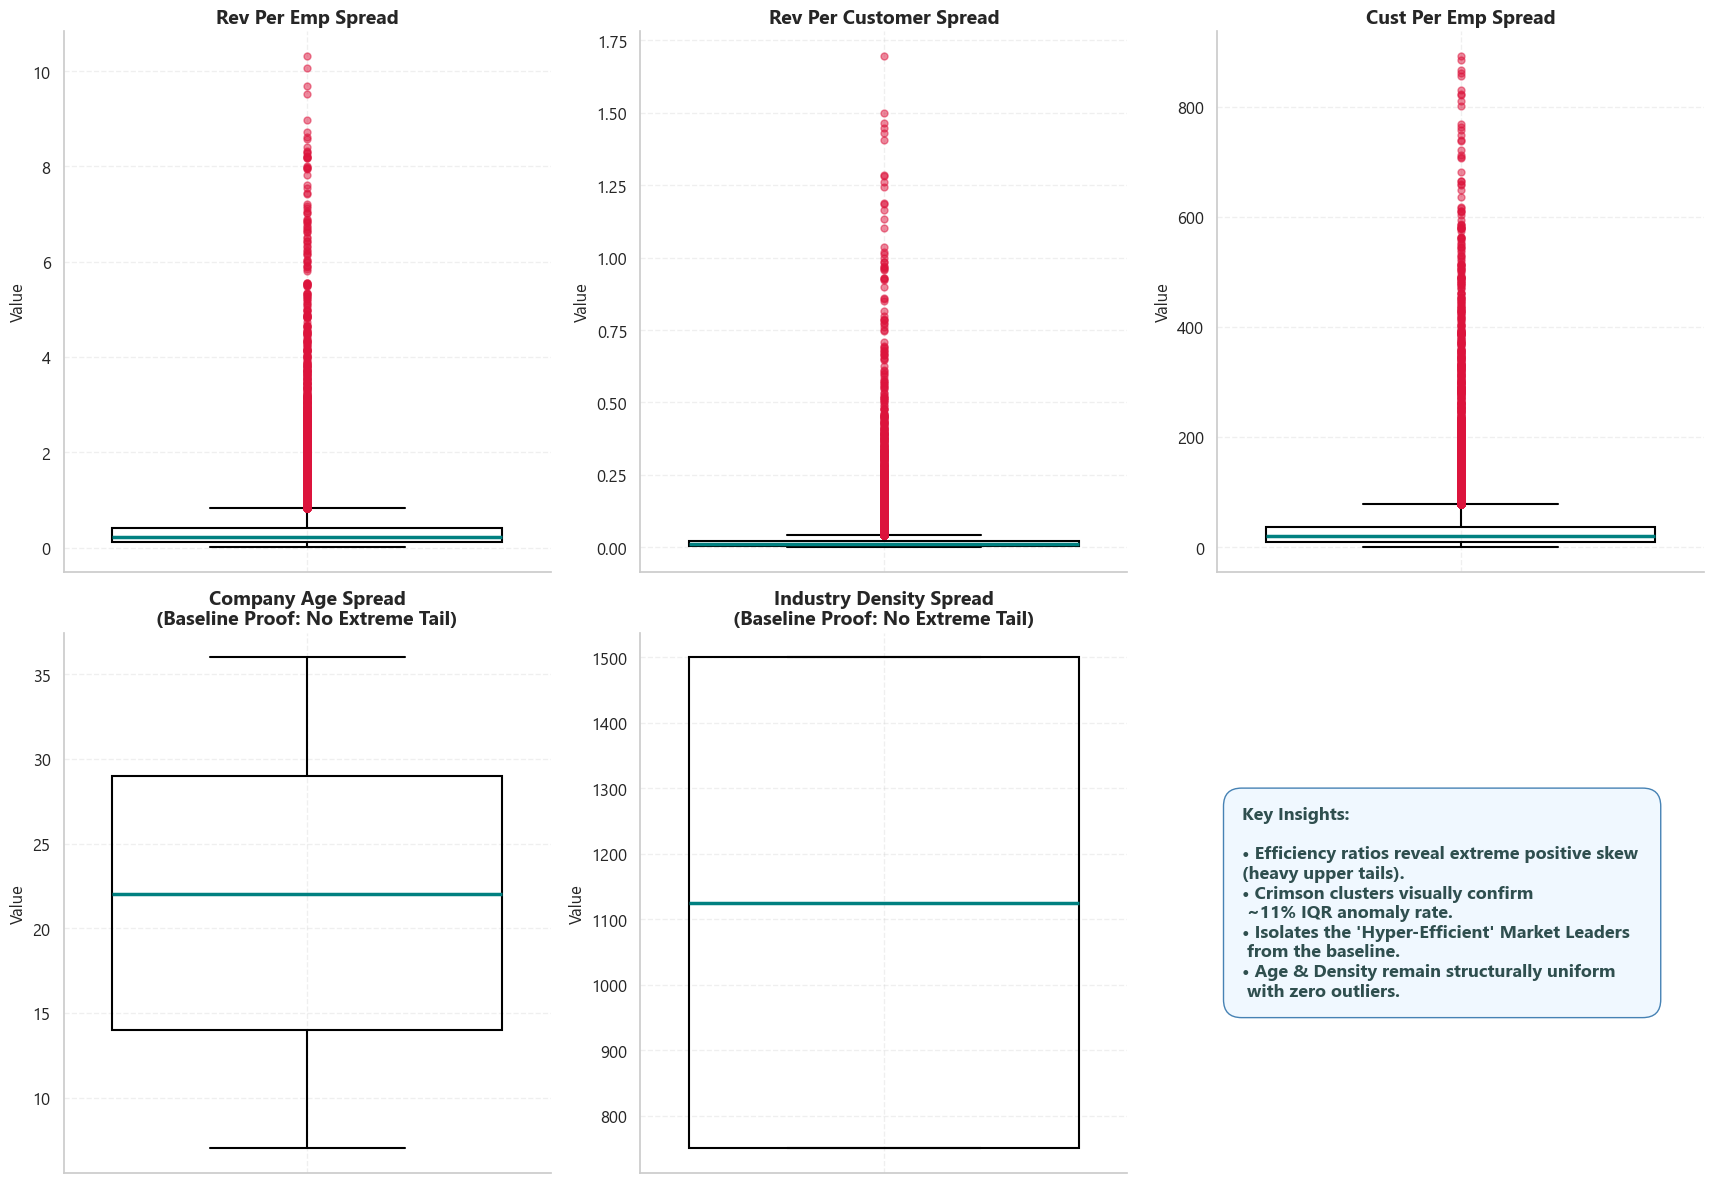


✅ Success: Box plots generated for engineered numerical metrics, visually confirming the presence of outliers in ratio features and validating the IQR calculations.


In [191]:
engineered_boxplot_targets = ['rev_per_emp', 'rev_per_customer','cust_per_emp','company_age', 'industry_density']

print("--- Visualizing Outliers (Box Plots) ---")


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.subplots_adjust(wspace=0.5, hspace=0.6) 
axes = axes.flatten()

for i, col in enumerate(engineered_boxplot_targets):
    display_name = col.replace('_', ' ').title()
    custom_box = dict(facecolor='none', edgecolor='black', linewidth=1.5)
    custom_whisker = dict(color='black', linewidth=1.5)
    custom_cap = dict(color='black', linewidth=1.5)
    custom_median = dict(color='teal', linewidth=2.5)
    custom_fliers = dict(marker='o', markerfacecolor='crimson', markeredgecolor='crimson', markersize=5, alpha=0.5)
    sns.boxplot(y=df_transformed[col],ax=axes[i],boxprops=custom_box, whiskerprops=custom_whisker,flierprops=custom_fliers,medianprops=custom_median,capprops=custom_cap)
    
    if col == 'company_age' or col == 'industry_density':
        axes[i].set_title(f'{display_name} Spread\n(Baseline Proof: No Extreme Tail)', fontsize=14, weight='bold')
    else:
        axes[i].set_title(f'{display_name} Spread', fontsize=14, weight='bold')
    axes[i].set_ylabel('Value', fontsize=12);axes[i].grid(True, linestyle='--', alpha=0.3)
axes[5].axis('off')     
insight_text = "Key Insights:\n\n• Efficiency ratios reveal extreme positive skew \n(heavy upper tails).\n• Crimson clusters visually confirm\n ~11% IQR anomaly rate.\n• Isolates the 'Hyper-Efficient' Market Leaders\n from the baseline.\n• Age & Density remain structurally uniform\n with zero outliers."
axes[5].text(0.05, 0.5, insight_text ,color='darkslategray', fontsize=13, va='center', ha='left', weight='bold', bbox=dict(facecolor='aliceblue', edgecolor='steelblue', boxstyle='round,pad=1'))
sns.despine()
plt.tight_layout()
plt.show()
print("\n✅ Success: Box plots generated for engineered numerical metrics, visually confirming the presence of outliers in ratio features and validating the IQR calculations.")


<div style="margin-left: 80px; max-width: 90%;">

##### B.2 Engineered Q-Q Plots:
To visualize the heavy right-skew deviation at the extreme upper tails.

</div>

--- Visualizing Q-Q Plots (Engineered Numerical Metrics) ---


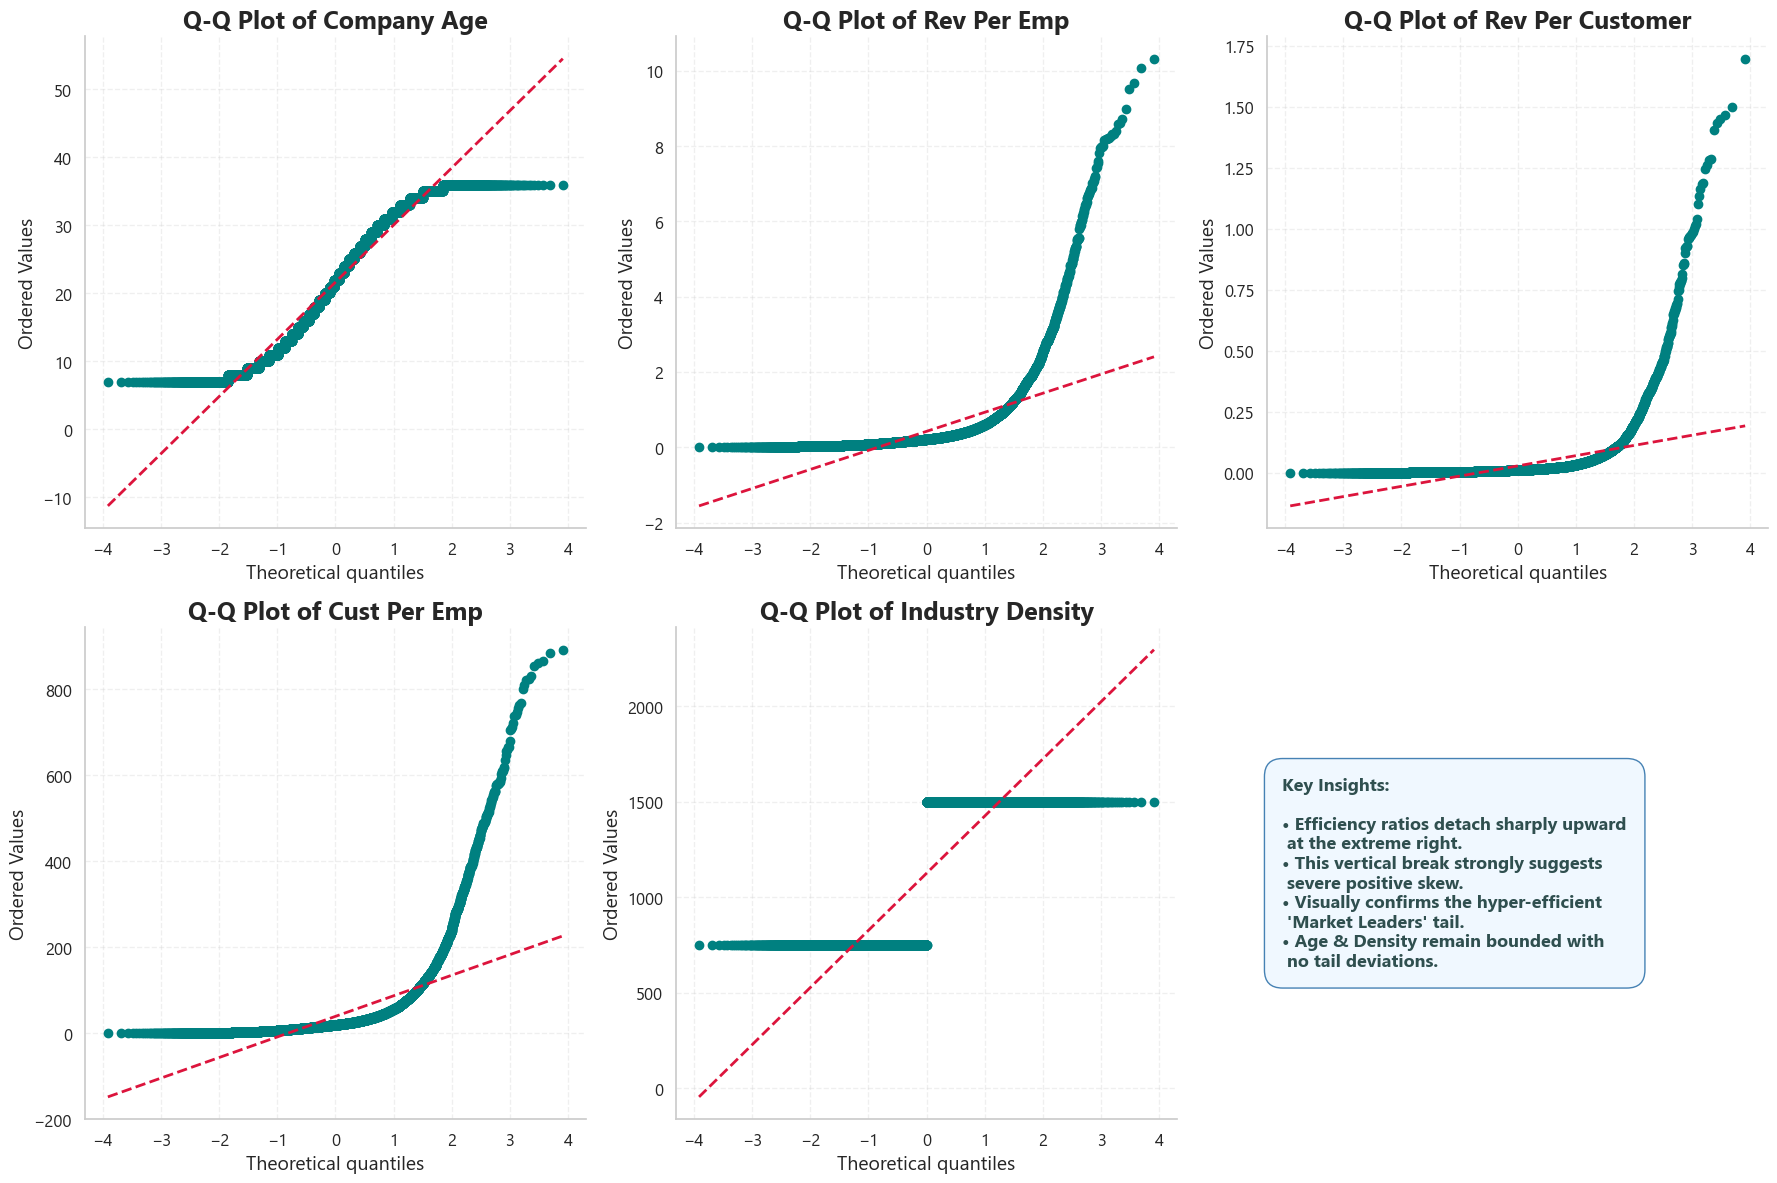


✅ Success: Q-Q plots generated for engineered metrics, visually confirming extreme right-skew in efficiency ratios and validating the IQR outlier calculations.


In [192]:
#   Q-Q Plot for Engineered Numerical Metrics

engineered_qqplot_targets = ['company_age', 'rev_per_emp', 'rev_per_customer', 'cust_per_emp', 'industry_density']
print("--- Visualizing Q-Q Plots (Engineered Numerical Metrics) ---")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.subplots_adjust(wspace=0.5, hspace=0.6) 
axes = axes.flatten()

for i, col in enumerate(engineered_qqplot_targets):
    only_values = df_transformed[col].dropna()
    display_title = col.replace('_', ' ').title()
    probplot(only_values, dist="norm", plot=axes[i])
    axes[i].get_lines()[1].set_color('crimson');axes[i].get_lines()[0].set_color("teal");axes[i].get_lines()[1].set_linewidth(2);axes[i].get_lines()[1].set_linestyle('--');axes[i].set_title(f'Q-Q Plot of {display_title}', fontweight='bold');axes[i].set_ylabel('Ordered Values');axes[i].grid(True, linestyle='--', alpha=0.3)
axes[5].axis('off')     
insight_text = "Key Insights:\n\n• Efficiency ratios detach sharply upward\n at the extreme right.\n• This vertical break strongly suggests\n severe positive skew.\n• Visually confirms the hyper-efficient\n 'Market Leaders' tail.\n• Age & Density remain bounded with\n no tail deviations."
axes[5].text(0.03, 0.5, insight_text ,color='darkslategray', fontsize=13, va='center', ha='left', weight='bold', bbox=dict(facecolor='aliceblue', edgecolor='steelblue', boxstyle='round,pad=1'))
plt.tight_layout();plt.show()
print("\n✅ Success: Q-Q plots generated for engineered metrics, visually confirming extreme right-skew in efficiency ratios and validating the IQR outlier calculations.")

<div style="margin-left: 80px; max-width: 90%;">

**💡 Interpretation of Engineered Numerical Visuals:**

* **Boxplot Validation:** The box plots for our derived efficiency ratios (`rev_per_emp`, `rev_per_customer`, `cust_per_emp`) visually confirm the ~11% anomaly rate calculated during our IQR analysis. The dense clusters of extreme values above the upper whiskers clearly isolate our hyper-efficient "Market Leaders." Meanwhile, structural metrics like `company_age` and `industry_density` remain perfectly uniform with zero outliers.
* **Q-Q Plot Validation:** The Q-Q plots mathematically confirm a heavy right-skew in these efficiency ratios. Instead of tracking the theoretical diagonal line, the data points detach and curve sharply upward at the extreme right tails. This vertical break confirms extreme positive kurtosis, physically proving the presence of highly scalable, high-value business models operating far above the standard market ceiling.

</div>

<div style="margin-left: 20px; max-width: 90%;">

- ### 📌 3. Outlier Handling Strategy

<div style="margin-left: 20px; max-width: 90%;">

#### Strategic Retention (Justification)
In standard data preprocessing, statistical outliers are often capped (Winsorized) or removed to normalize the dataset. However, in this specific business context, doing so would be a catastrophic analytical error.

* **Genuine Business Performance:** The outliers identified in our dataset are not mistakes or data entry errors. Because they only appear in our efficiency metrics (like Revenue per Employee), they represent real, highly successful companies.
* **Preserving the Market Leaders:** Our multivariate analysis proved that these exact "outliers" are the top-performing **Market Leaders** we are actively studying. 
* **Final Verdict:** If we remove or cap these extreme values, we would accidentally erase the mathematical advantage of our elite companies, flattening them into "average" performers. To maintain a true, accurate picture of the market ceiling, **all outliers will be strictly retained** in the dataset.

</div>
</div>

<div style="text-align: center; margin-top: 40px; margin-bottom: 40px;">
    <h2 style="color: #4CAF50; margin-bottom: 15px;">✅ Phase Checkpoint: Analytical Pipeline Complete</h2>
    <i style="color: #CCCCCC; font-size: 1.1em; line-height: 1.5;">
        All exploratory visualizations and statistical outlier evaluations have been successfully finalized.<br>
        We now transition from technical analysis to business strategy, distilling our core findings into actionable intelligence and mapping the future technical roadmap.
    </i>
    <hr style="border: 0; height: 1px; background: #333; margin-top: 25px; width: 50%;">
</div>

## **Executive KPI Dashboard Generation**
To synthesize the entire 15,000-company pipeline for stakeholder review, we will now compile the foundational metrics, engineered extremes, and final Market Leader count (from our Funnel Analysis) into a dynamic HTML dashboard. By rendering this natively in Python, we ensure the dashboard updates automatically if the underlying dataset expands in future quarters.

In [193]:
#   Fetching KPIs
total_companies = len(df_transformed)
num_industries = df_transformed['industry'].nunique() if 'industry' in df_transformed.columns else df_transformed['industry'].nunique()
num_regions = df_transformed['region'].nunique() if 'region' in df_transformed.columns else df_transformed['region'].nunique()
num_countries = df_transformed['country'].nunique() if 'country' in df_transformed.columns else df_transformed['country'].nunique()

avg_revenue = df_transformed['annual_revenue_million'].mean()
avg_employees = df_transformed['employee_count'].mean()
median_profit = df_transformed['profit_margin_percent'].median()

max_rev_emp = df_transformed['rev_per_emp'].max()
max_cust_emp = df_transformed['cust_per_emp'].max()

s2 = df_transformed[df_transformed['age_tier'] == 'Established']
s3 = s2[s2['customer_tier'] == 'Mass-Scale']
s4 = s3[s3['revenue_tier'].isin(['Large', 'Enterprise'])]
median_profit = df_transformed['profit_margin_percent'].median()
s5 = s4[s4['profit_margin_percent'] > median_profit]
s6 = s5[s5['rating_tier'] == 'Market Leader']
market_leaders_count = len(s6)
market_leaders_pct = (market_leaders_count / total_companies) * 100

#   HTML & CSS DASHBOARD INJECTION ---

html_content = f"""
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #161b22; padding: 30px; border-radius: 12px; color: #c9d1d9; max-width: 1200px; margin: auto;">
    
    <h2 style="text-align: center; color: #ffffff; font-size: 24px; font-weight: bold; letter-spacing: 1.5px; margin-bottom: 30px; margin-top: 0;">
        📊INDUSTRY EDA KPI DASHBOARD: DECODING THE MARKET LEADERS
    </h2>
    
    <div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 20px;">
        
        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">TOTAL COMPANIES</div>
            <div style="color: #c9d1d9; font-size: 32px; font-weight: bold;">{total_companies:,}</div>
        </div>
        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">COLUMN EXPANSION</div>
            <div style="color: #8b949e; font-size: 32px; font-weight: bold;">{df.shape[1]} ➔ {df_transformed.shape[1]}</div>
        </div>
        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">COUNTRIES | REGIONS</div>
            <div style="color: #c9d1d9; font-size: 32px; font-weight: bold;"> {num_countries} | {num_regions} </div>
        </div>
        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">UNIQUE INDUSTRIES</div>
            <div style="color: #c9d1d9; font-size: 32px; font-weight: bold;">{num_industries}</div>
        </div>

        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">AVG ANNUAL REVENUE</div>
            <div style="color: #58a6ff; font-size: 32px; font-weight: bold;">${avg_revenue:,.1f}M</div>
        </div>
        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">AVG EMPLOYEE COUNT</div>
            <div style="color: #58a6ff; font-size: 32px; font-weight: bold;">{avg_employees:,.0f}</div>
        </div>
        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">MEDIAN PROFIT MARGIN</div>
            <div style="color: #58a6ff; font-size: 32px; font-weight: bold;">{median_profit:.1f}%</div>
        </div>
        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">BASE DATA DISTRIBUTION</div>
            <div style="color: #8b949e; font-size: 32px; font-weight: bold;">Uniform</div>
        </div>

        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">MAX REV / EMPLOYEE</div>
            <div style="color: #56d364; font-size: 32px; font-weight: bold;">${max_rev_emp:.2f}M</div>
        </div>
        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">MAX CUST / EMPLOYEE</div>
            <div style="color: #56d364; font-size: 32px; font-weight: bold;">{max_cust_emp:,.0f}</div>
        </div>
        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">MARKET LEADERS (FUNNEL)</div>
            <div style="color: #ff7b72; font-size: 32px; font-weight: bold;">{market_leaders_count:,}</div>
        </div>
        <div style="background-color: #21262d; padding: 20px; border-radius: 8px; text-align: center;">
            <div style="color: #8b949e; font-size: 13px; font-weight: bold; margin-bottom: 10px;">ELITE CEILING (%)</div>
            <div style="color: #ff7b72; font-size: 32px; font-weight: bold;">{market_leaders_pct:.1f}%</div>
        </div>
        
    </div>
</div>
"""

display(HTML(html_content))

## 08. Executive Conclusion & Future Scope

<div style="margin-left: 20px; max-width: 90%;">

### A. Goal and Context
The objective of this Exploratory Data Analysis was to evaluate the 
operational and financial performance of 15,000 global companies across 
5 industries, 4 countries, and 3 geographic regions. By systematically 
examining baseline distributions, engineering custom efficiency ratios, 
and applying univariate, bivariate, and multivariate analytical techniques, 
this project aimed to identify the structural patterns that separate 
average market participants from elite Market Leaders — and to 
quantify exactly how rare that elite status is.

### B. Key Statistical & Strategic Findings

* **The Uniform Market Baseline:** All five original numerical metrics 
  — Revenue, Employee Count, Customer Count, Profit Margin, and Market 
  Rating — demonstrated near-perfect distributional uniformity with 
  skewness values between −0.027 and +0.027 and negative kurtosis 
  of approximately −1.19 across all columns. No single industry, 
  country, or geographic region holds a structural baseline advantage. 
  The market playing field is mathematically level.

* **The Scale Paradox:** Engineered efficiency ratios exhibited extreme 
  right-skew (Rev/Employee: 5.58, Rev/Customer: 9.34, Cust/Employee: 5.28) 
  and massive positive kurtosis (up to 118.9), in direct contrast to the 
  uniform base metrics. Cross-sector analysis confirmed that Mass-Scale 
  business models generate the highest total revenue but consistently 
  produce the lowest profit margins (~24.6%), while focused Niche operators 
  achieve margins as high as 37.0% with a fraction of the workforce. 
  Competitive advantage is not found in organizational size — it is found 
  in operational density.

* **The Technology Niche Anomaly:** The single most significant finding 
  of the multivariate analysis is that Technology companies operating 
  under a Large/Niche business model generate approximately $3.04M 
  revenue per employee — the highest efficiency ratio of any 
  industry-model combination in the dataset. This pattern, while most 
  extreme in Technology, is structurally consistent across all five 
  sectors: Niche and Standard operators outperform Mass-Scale operators 
  on a per-unit efficiency basis in every industry.

* **The 3.4% Elite Ceiling:** The business pipeline funnel, applying 
  five sequential operational filters — Established Age, Mass-Scale 
  Customers, Large or Enterprise Revenue, High Profit Margin, and 
  Market Leader Rating — reduced 15,000 companies to just 505 
  qualifying entities (3.4%). This quantifies precisely how rare 
  simultaneous multi-dimensional excellence is in this market. 
  The revenue tier filter proved to be the sharpest single 
  eliminator, dropping the qualifying pool from 83.4% to 37.3%.

* **The ~11% Outlier Group:** IQR-based outlier detection identified 
  between 10.9% and 12.1% of companies as anomalies exclusively within 
  the three engineered efficiency ratios — zero outliers were detected 
  in any base metric. These are not data errors. They represent a 
  coherent, identifiable group of hyper-efficient operators whose 
  performance levels far exceed the standard market ceiling. They were 
  deliberately retained for analysis as they constitute the dataset's 
  most analytically valuable segment.

* **Temporal and Regional Neutrality:** Correlation analysis confirmed 
  near-zero relationships between founding year, country, region, and 
  all performance outcomes. A company's geographic location and 
  operational age do not artificially inflate or restrict its revenue 
  potential. Performance is determined entirely by operational behavior, 
  not structural position.

### C. Applied Analytical Methodologies

This pipeline moved strictly from data auditing to complex dimensional 
analysis, successfully demonstrating:

* **Data Quality Auditing:** Structural validation confirming zero 
  missing values across all 15,000 records, zero duplicate entries, 
  and correct data type alignment across all columns.

* **Feature Engineering:** Ten new analytical features derived from 
  the 12 original columns — three operational efficiency ratios 
  (rev_per_emp, rev_per_customer, cust_per_emp), one structural metric 
  (company_age), one competitive pressure metric (industry_density), 
  and five tier classification columns (age_tier, rating_tier, 
  revenue_tier, customer_tier, business_model) — expanding the 
  dataset from 11 usable columns to 21 analysis-ready features.

* **Univariate Diagnostics:** Histogram and KDE analysis confirming 
  distributional uniformity in base metrics and extreme right-skew 
  in engineered ratios. Skewness and kurtosis computed for all 
  numerical columns. Funnel diagram constructed to visualize 
  the sequential filtration toward elite Market Leader status.

* **Bivariate Interactions:** Boxplots for revenue distribution by 
  industry, time-series line charts for monthly revenue and quarterly 
  profit margin trends, treemaps for business model market share, 
  cross-tabulation heatmaps and stacked bar charts for industry-level 
  performance distribution analysis.

* **Multivariate Dimensionality:** Comprehensive correlation heatmap 
  across all 10 numerical variables, grouped bar charts for 
  cross-sector efficiency analysis, bar-line combination charts 
  for the Scale Paradox, and radar chart profiling for Market Leader, 
  Average Performer, and Low Performer operational archetypes.

* **Statistical Outlier Detection:** IQR method applied independently 
  to all base and engineered numerical columns. Q-Q plot normality 
  testing conducted for all numerical features. Outlier retention 
  decision made on statistical and contextual grounds.

### D. Future Scope

* **Unsupervised Clustering (K-Means):** Apply K-Means clustering 
  on rev_per_emp and cust_per_emp ratios to mathematically define 
  efficiency archetypes among the 505 Market Leaders — completely 
  independent of industry labels — replacing the current 
  funnel-based classification with a data-driven segmentation.

* **Predictive Profit Modelling:** Use the engineered efficiency 
  ratios as independent variables to train a Random Forest or 
  multiple linear regression model capable of predicting a 
  company's profit_margin_percent based on its operational profile.

* **Feature Importance Extraction:** Deploy a binary classification 
  model (Market Leader vs. Baseline) to extract exact feature 
  importance weights — definitively determining whether company_age, 
  employee_count, or rev_per_emp is the heaviest driver of 
  Market Leader status.

* **Interactive Executive Dashboard (Streamlit):** Deploy the 
  analytical pipeline findings into a real-time, filterable 
  Streamlit dashboard, making the insights accessible to 
  non-technical executive stakeholders with live drill-downs 
  by industry, region, and business model.

</div>

---
---